# 00. Fundamentos Pytorch

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.12.1+cu130


## Introdução a tensores



### Criando tensores

In [ ]:
#escalar
escalar = torch.tensor(7)
escalar


In [ ]:
escalar.ndim

In [ ]:
escalar.item()

In [ ]:
vetor = torch.tensor([7,7])
vetor

In [ ]:
vetor.ndim

In [ ]:
vetor.shape

In [ ]:
matriz = torch.tensor([[7,8],
                       [9,10]])
matriz

In [ ]:
matriz.ndim

In [ ]:
matriz[1][1]

In [ ]:
matriz.shape

In [ ]:
tensor = torch.tensor([[[1,2,3],
                        [3,69,100],
                        [4,1209,91]]])
tensor

In [ ]:
tensor.ndim

In [ ]:
tensor.shape

In [ ]:
tensor[0]


### Tensores aleatorios

`fluxo = começar com numeros aleatorios -> olhar os dados -> atualizar os numeros aleatorios-> olhar os dados->atualizar os numeros aleatorios`

In [ ]:
aleatorio = torch.rand(3,4)
aleatorio

In [ ]:
aleatorio.ndim

In [ ]:
random_image_size_tensor = torch.rand(size = (224,224,3))#altura,largura,numero de canais
random_image_size_tensor.shape, random_image_size_tensor.ndim

In [ ]:
zero = torch.zeros(size = (3,4))
zero

In [ ]:
zero * aleatorio

In [ ]:
one = torch.ones(size = (3,4))

In [ ]:
one.dtype

In [ ]:
aleatorio.dtype

### Criando tensores com range e tensors-like


In [ ]:
um_a_dez = torch.arange(start = 1,end = 11, step = 2)
um_a_dez

In [ ]:
dez_zeros = torch.zeros_like(input = um_a_dez)
dez_zeros

### Tensors datatypes

**Nota:** tipos de dados de tensores é um dos 3 grandes erros que vou encontrar dentro do pytorch e deep learning:
1. Tensores com tipo de dados errado
2. Tensores com o formato(shape) errado
3. Tensores no "device" errado

In [ ]:
float_32_tensor = torch.tensor([3.0,6.0,9.0], 
                               dtype = None, #tipo de dados ex:torch.float32
                               device = None, #qual device esta o seu tensor (cpu, cuda)
                               requires_grad = False)#rastrear ou não os gradientes com essas operações de tensores


float_32_tensor

In [ ]:
float_32_tensor.dtype

In [ ]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

In [ ]:
float_32_tensor * float_16_tensor

In [ ]:
int_32_tensor = torch.tensor([3,6,8], dtype = torch.int32)
int_32_tensor

In [ ]:
int_32_tensor * float_16_tensor

### Obtendo informações dos tensores(atributos dos tensores)

1. Tensores com tipo de dados errado - para obter o dtype de um tensor, podemos usar `tensor.dtype`
2. Tensores com o formato(shape) errado - para obter a forma de um tensor, podemos usar `tensor.shape` 
3. Tensores no "device" errado - para obter o dispositivo de um tensor, podemos usar  `tensor.device`

In [ ]:
some_tensor = torch.rand(3,4, dtype = torch.float16)
some_tensor

In [ ]:
print(some_tensor)
print(f"Tipo de dados do tensor: {some_tensor.dtype}")
print(f"Formato do tensor: {some_tensor.shape}")
print(f"Dispositivo do tensor está em: {some_tensor.device}")

### Manipulando tensores(tensor operations)

Operações de tensores incluem:
* Adição
* Subtração
* Multiplicação(element-wise)
* Divisão
* Multiplicações de matrizes

In [ ]:
tensor = torch.tensor([1,2,3])
tensor + 10

In [ ]:
tensor * 10

In [ ]:
tensor

In [ ]:
tensor - 10

In [ ]:
torch.mul(tensor, 10)

In [ ]:
torch.add(tensor, 10)

### Multiplicação de matrizes

Duas formas principais de realizar a multiplicação em redes neurais e deep learning :
x
1. Element-wise multiplication
2. Multiplicação de matrizes(dot product)

Aqui estao duas regras que tem que ser satisfeitas para a multiplicação de matrizes:
1. As **dimensões internas** tem que combinar:
* `(3,2) @ (3,2)` não funciona
* `(2,3) @ (3,2)` funciona
* `(3,2) @ (2,3)` funciona

2. O resultado das matriz tem o formato das **dimensões externas**:
* `(2,3) @ (3,2)` -> `(2,2)`
* `(3,2) @ (2,3)` -> `(3,3)`


In [ ]:
torch.matmul(torch.rand(2,3), torch.rand(3,2))

In [ ]:
tensor = torch.tensor([1,2,3])

In [ ]:
tensor * tensor

In [ ]:
torch.matmul(tensor, tensor)

In [ ]:
%%time
value = 0
for i in range(len(tensor)):
    value += tensor[i] * tensor[i]

value

In [ ]:
%%time
torch.matmul(tensor,tensor)

### Um dos erros mais comuns em deep learning: erro de formato

In [ ]:
tensor_A = torch.tensor([[1,2],
                         [3,4],
                         [5,6]])

tensor_B = torch.tensor([[7,10],
                         [8,11],
                         [9,12]])

torch.matmul(tensor_A, tensor_B)

In [ ]:
tensor_A.shape, tensor_B.shape

In [ ]:
tensor_B.T # transpondo o tensor_B

In [ ]:
torch.matmul(tensor_A, tensor_B.T)

In [ ]:
output = torch.matmul(tensor_A, tensor_B.T)
print(f"Formato da saida: {output.shape}")

### Agregações(min,max,sum,mean) em tensor

In [ ]:
x = torch.arange(0,100,10)
x, x.dtype

In [ ]:
torch.min(x), x.min()

In [ ]:
torch.max(x), x.max()

In [ ]:
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()

In [ ]:
torch.sum(x), x.sum()

### Achando a posição do min e max em um tensor


In [ ]:
x

In [ ]:
x.argmin()

In [ ]:
x[0]

In [ ]:
x.argmax()

In [ ]:
x[9]

### Reshaping, stacking(empilhamento), squeezing e unsqueezing

* Reshape - reformata um tensor de entrada para um formato definido
* View - retorna uma visualização de um tensor de entrada de uma deerminado formato, mas que mantém a memoria original do tensor
* Stacking - combina multiplos tensores um em cima do outro(vstack) ou lado a lado (hstack)
* Squeeze - remove todas as dimensões únicas de um tensor
* unsqueeze - adiciona uma dimensão unica a um tensor de destino
* Permute - retorna uma visualização da entrada com dimensões permutadas(trocadas) de uma determinada maneira

In [ ]:
import torch
x = torch.arange(1.,10.)
x.dtype, x.shape

In [ ]:
# Adiciona dimensão extra
x_reshaped = x.reshape(1,9)
x_reshaped, x_reshaped.shape

In [ ]:
# Mudando a view, em uma view, se voce muda a view, muda tambem o que voce atribuiu a view
z = x.view(9,1)
z , z.shape


In [ ]:
z[:, 0] = 5
z, x

In [ ]:
x_stacked = torch.stack([x,x,x,x], dim = 1)
x_stacked, x_stacked.shape

In [ ]:
x_vstack = torch.vstack([x,x,x,x])
x_vstack, x_vstack.shape

In [ ]:
x_hstack = torch.hstack([x,x,x,x])
x_hstack, x_hstack.shape

In [ ]:
x_reshaped

In [ ]:
x_reshaped.shape

In [ ]:
x_reshaped.squeeze()

In [ ]:
x_reshaped.squeeze().shape

In [ ]:
x_squeeze = x_reshaped.squeeze()
x_unsqueeze = x_squeeze.unsqueeze(dim = 0)

In [ ]:
print(f"Tensor anterior: {x_squeeze}")
print(f"Formato anterior: {x_squeeze.shape}")
print(f"Tensor atual: {x_unsqueeze}")
print(f"Formato atual: {x_unsqueeze.shape}")

In [ ]:
x_original = torch.rand(size = (224,224,3))

x_permuted = x_original.permute(2,0,1)
x_original.shape, x_permuted.shape 

In [ ]:
x_original[0,0,0] = 5

x_original[0,0,0], x_permuted[0,0,0]

### Selecionando dados de tensores com indexação

Indexação em Pytorch é parecido com indexação em Numpy

In [ ]:
import torch
x = torch.arange(1,10).reshape(1,3,3)
x, x.shape

In [ ]:
x[0]

In [ ]:
x[0][0]

In [ ]:
x[0][0][0]

In [ ]:
# Usamos : para selecionar todos os valores da dimensao desejada
x[:,0]


In [ ]:
x[:,:,1]

In [ ]:
x[:,1,1]

In [ ]:
x[0,0,:]

In [ ]:
x

x[0,2,2]



In [ ]:
x
x[:, :, 2]

### Tensores Pytorch e numpy

Numpy é uma biblioteca python cientifica popular 

E por isso, Pytorch tem funionalidade para interagir com ela

* Dados em Numpy(np.array) e querer isso em um tensor Pytorch -> `torch.from_numpy(ndarray)`
* Pytorch tensor -> Numpy -> `torch.Tensor.numpy()`

In [ ]:
# Quando convertemos numpy -> pytorch, o tensor reflete o padrao de dados do numpy(float64), a menos que especificada de outra forma
import torch
import numpy as np
array = np.arange(1.0,8.0)
tensor = torch.from_numpy(array)
array, tensor

In [ ]:
array.dtype

In [ ]:
torch.arange(1.0, 8.0).dtype


In [ ]:
# Se mudar o valor do array numpy, o que acontecera com o tensor pytorch?
array = array + 1
array, tensor

In [ ]:
# Tensor para array numpy
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

In [ ]:
numpy_tensor.dtype

In [ ]:
# Mudando o tensor, o que acontece ao "tensor  numpy"?
tensor = tensor + 1
tensor, numpy_tensor

### Reprodutibilidade (tentando eliminar o estado aleatorio(random))

Resumindo, como a rede neural aprende é:
`Começar com números aleatórios -> operações de tensores -> atualizar números aleátorios para torná-los melhores representações dos dados -> de novo -> de novo -> de novo...`

Para reduzir a aleatoriedade em redes neurais e Pytorch, tras o conceito de **random seed**

Essencialmente, o que a seed faz é "suavizar" a aleatoriedade


In [ ]:
import torch
random_tensor_A = torch.rand(3,4)
random_tensor_B = torch.rand(3,4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A==random_tensor_B)

In [ ]:
# Criando tesnores aleatorios mas reproduziveis
import torch

# Set the random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

random_tensor_C = torch.rand(3,4)

torch.manual_seed(RANDOM_SEED)

random_tensor_D = torch.rand(3,4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

### Executando tensores e objetos Pytorch em GPUs (e fazer calculos mais rapidos)

GPUs = computação mais rapida com números, graças ao CUDA + NVIDIA hardware + Pytorch trabalhando nos bastidores para deixar tudo perfeito

### 1. Obtendo a GPU

1. Fácil - Use o Google Colab para obter uma GPU gratuita(opções de melhora)
2.  Use your own GPU - exige um pouco de configuração e o investimento na compra de uma GPU, tem muitas opções... , veja esse post para ver qual opção adquirir: https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/
3. Usar computação em nuvem - GCP, AWS, Azure, esses serviços permitem alugar computadores na nuvem e acessá-los

Para 2,3 Pytorch + drivers GPU(CUDA), é necessário um pouco de configuração, para fazer isso, consulte a documentação de configuração do Pytorch



In [ ]:
!nvidia-smi

### 2. Checando o acesso da GPU pelo Pytorch
 

In [ ]:
# Checando o acesso a GPU com Pytorch
import torch
torch.cuda.is_available()

Para o Pytorch, já que ele é capaz de executar computação na GPU ou CPU é uma pratica recomendada configurar um código independente de dispositivo agnóstico: https://pytorch.org/docs/stable/notes/cuda.html#best-pratices

Executar na GPU se disponível, senão o padrão é CPU

In [38]:
# Configurando o dódigo agnóstico de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [ ]:
# Contar o numero de dispositivos
torch.cuda.device_count()

### 3. Colocando tensores(e modelos) na GPU

O motivo pelo qual queremos nossoos tensores/modelos na GPU, é porque o uso da GPU resulta em cálculos mais rápidos 


In [ ]:
tensor = torch.tensor([1,2,3])

print(tensor, tensor.device)

In [ ]:
# Mover o tensor para a GPU(se disponível)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu, tensor_on_gpu.device

### 4. Movendo os tensores de volta para a CPU

In [ ]:
# Se o tensor estiver na GPU, nao será possível transformar em Numpy

tensor_on_gpu.numpy()

In [ ]:
# Para corrigir o problema do tensor na GPU com numpy, podemos primeiro configurá-lo para a CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()

tensor_back_on_cpu

In [ ]:
tensor_on_gpu

### Exercícios e extra-curricular

In [ ]:
#Exercício 1
import torch
a = torch.rand(7,7)
a


In [ ]:
b = torch.rand(1,7)
transposto = b.T
print(f"{torch.matmul(a, transposto)}")

In [ ]:
SEED = 42
torch.manual_seed(SEED)
c = torch.rand(7,7)
torch.manual_seed(SEED)
d = torch.rand(1,7)
d_t = d.T
print(f"Multiplicação da primeira matriz: {c}")
print(f"Com a segunda matriz transposta: {d_t}")
print(f"Resultado: {torch.matmul(c,d_t)}")



In [ ]:
RANDOM_SEED = 1234
torch.manual_seed(RANDOM_SEED)
tensor1 = torch.rand(2,3)
torch.manual_seed(RANDOM_SEED)
tensor2 = torch.rand(2,3)
tensor_reformatado = tensor2.reshape(3,2)
resultado = torch.matmul(tensor1, tensor_reformatado)
print(f"Multiplicação dos tensores: {resultado}")



In [ ]:
v_max = resultado.max()
v_min = resultado.min()
pos_max = resultado.argmax()
pos_min = resultado.argmin()

print(f"Valor máximo: {v_max}")
print(f"Posição máxima: {pos_max}")
print(f"Valor mínimo: {v_min}")
print(f"Posição do valor mínimo: {pos_min}")


In [ ]:
torch.manual_seed(7)
random = torch.rand(1,1,1,10)
random2 = random.squeeze()

print(f"Primeiro tensor: {random}")
print(f"Formato do primeiro tensor: {random.shape}")
print(f"Segundo tensor: {random2}")
print(f"Formato do segundo tensor: {random2.shape}")

# 01. Pytorch Workflow


In [ ]:
o_que_cobrimos = {1: "data(prepare and load)",
                  2: "criar um modelo",
                  3: "ajustar o modelo aos dados(training)",
                  4: "fazer previsões e avaliar o modelo(inferência)",
                  5: "salvar e carregar um modelo",
                  6: "juntar tudo"}

o_que_cobrimos

{1: 'data(prepare and load)',
 2: 'criar um modelo',
 3: 'ajustar o modelo aos dados(training)',
 4: 'fazer previsões e avaliar o modelo(inferência)',
 5: 'salvar e carregar um modelo',
 6: 'juntar tudo'}

In [ ]:
import torch
from torch import nn # nn contém todos os blocos de construção do Pytorch para redes neurais
import matplotlib.pyplot as plt

# Checar a versão do PyTorch
torch.__version__

'2.12.0+cu130'

## 1. Dados (preparando e carregando)

Dados podem ser praticamente qualquer coisa... em machine learning.

* Tabela Excel
* Imagens de qualquer tipo
* Videos (YouTube tem muitos dados...)
* Audios como músicas ou podcasts
* DNA
* Texto

Machine Learning é um jogo de duas partes:
1. Obter dados em uma representação numérica.
2. criar um modelo para aprender padrões nessa representação numérica.

Para mostrar isso, vamos criar alguns dados *conhecidos* usando a formula da regressão linear.

Usaremos a fomula da regressão linear para fazer uma linha reta com **parâmetros** *conhecidos*

In [ ]:
# Criando parâmetros conhecidos
weight = 0.7
bias = 0.3

# Criando dados
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Separando os dados em conjuntos de treinamento e teste ( um dos mais importantes conceitos em machine learning)

Vamos criar um conjunto de treinamento e teste com nossos dados.

In [ ]:
# Crie uma divisão treino/teste
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Como podemos visualizar melhor nossos dados?

é aí que entra o lema do explorador de dados

"Visualize, visualize, visualize"

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    """
    Plot dados de treinamento, dados de teste e compare as predições.
    """
    plt.figure(figsize = (10,7))

    # Plotar os dados de treinamento em azul
    plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Dados de treinamento")

    #Plotar os dados de teste em verde
    plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Dados de teste")

    # E as previsões?
    if predictions is not None:
        # Plotar as previsões se elas existirem
        plt.scatter(test_data, predictions, s = 4, c = "r", label = "Previsões")

        # Mostrar a legenda
        plt.legend(prop = {"size": 14});


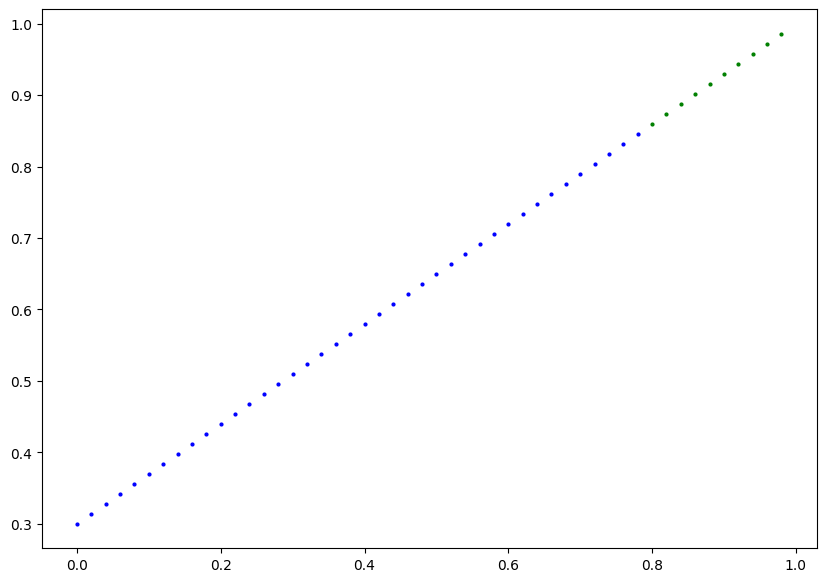

In [ ]:
plot_predictions();

## 2. Construir o modelo

Nosso primiero modelo PyTorch

O que nosso modelo faz:
* Começa com valores aleatórios(weight e bias)
* Olha os dados de treinamento e ajusta os valores aleatórios para representar melhor (ou chegar mais perto) os valores ideais ( o weight e o bias nós usamos para criar os dados)

Como ele faz isso?

Por meio de dois algoritmos principais:
1. Descida do Gradiente
2. Backpropagation

In [34]:
from torch import nn

# Crie uma classe de modelo de regressão linear
class LinearRegressionModel(nn.Module): # <- quase tudo no PyTorch herda de nn.Module
    def __init__(self):
        super().__init__() # Chama o construtor da classe pai, para ja criar os dicionarios weights e bias
        self.weights = nn.Parameter(torch.randn(1, # <- começa com um numero aleatorio do peso e tenta ajustar para o peso ideal
                                                requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                                dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        print(self.weights)
    
        self.bias = nn.Parameter(torch.randn(1, # <- começa com um bias aleatorio e tenta ajustar ele ao bias ideal
                                            requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                            dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        
        # Método Forward para definir o cálculo no modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" são os dados de entrada, x: torch.Tensor espera que a entrada seja um tensor e -> torch.Tensor espera que a saída seja um Tensor
        return self.weights * x + self.bias # Essa é a fórmula da regressão linear


In [35]:
model_0 = LinearRegressionModel()
model_0.state_dict()

Parameter containing:
tensor([0.4617], requires_grad=True)


OrderedDict([('weights', tensor([0.4617])), ('bias', tensor([0.2674]))])

### Itens essenciais de construção de modelos do PyTorch

* torch.nn - contem todos os blocos de construção de grafos computacionais(uma rede neural pode ser considerada um grafo computacional)
* torch.nn.Parameter - Quais parametros nosso modelo deve tentar e aprender, frequentemente uma camada PyTorch de torch.nn define isso para nós
* torch.nn.Module - A classe base para todos os nossos módulos de rede neural, se voce esta com a subclasse, deve sobrescrever forward()
* torch.optim - é aqui que os otimizaores do PyTorch vivem, eles ajudarão na descida do gradiente
* def forward() - todas as subclasses de nn.Module exigem que voce sobrescreva forward, ese método define o que acontece no cálculo forward

### Checando o conteudo do nosso modelo PyTorch

Agora criamos um modelo, vamos ver o que tem dentro..

Podemos verificar os parametros do nosso modelo ou o que esta dentro dele usando `.parameters() `.

In [ ]:
# Listar os parametros nomeados
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Fazendo previsões usando `torch.inference_mode()`

Para verificar a capacidade de previsão do nosso modelo, vamos ver o quão bem ele prevê `y_test`  com base no `X_test`.

Quando passarmos os dados pelo nosso modelo, ele sera executado pelo método forward

In [ ]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [ ]:
# Fazer previsões com o modelo
with torch.inference_mode():
    y_preds = model_0(X_test)


# Pode-se fazer algo semelhante com o torch.no_grad(), mas torch.inference_mode() é preferido
#with torch.no_grad():
    #y_preds = model_0(X_test)


y_preds    


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

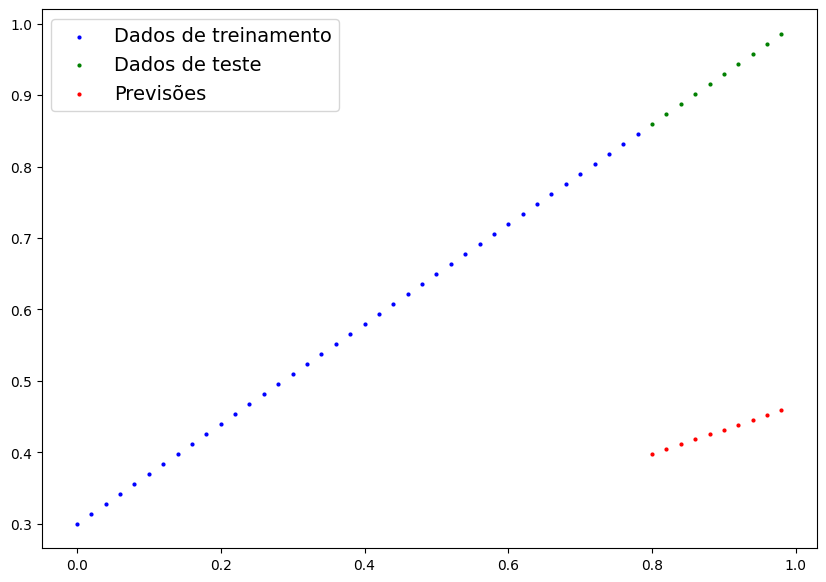

In [ ]:
plot_predictions(predictions = y_preds)

## 3. Treinando o modelo

A ideia geral do treinamento é que um modelo se mova a partir de alguns parâmetros *desconhecidos* (esses podem ser aleatórios) para alguns paramêtros *conhecidos*

Ou em outras palavras de uma pior representação dos dados a uma melhor representação dos dados.

Uma maneira de medir quão ruins ou quão erradas estao as previsões do seu modelo é usar uma função de perda(Loss Function)

* Nota: Funçao de perda pode ser chamada função de custo(cost function) ou criterio em diferentes áreas. Em nosso caso, vamos nos referir a isso como função de perda.

Coisas que precisamos treinar:

* **Loss Function:** é uma função para medir o quanto as previsões de seu modelo estão erradas em relação aos resultados, quanto menor melhor.
* **Optimizador:** Leva em conta a perda de um modelo e ajusta os parâmetros do modelo(pesos e vieses no nosso caso) para melhorar a funçao de perda.
 - Dentro do otimizador temos dois parâmetros:
     - `params`- os parametros do modelo que voce deseja otimizar, por exemplo `params = model_o.parameters()`
     - `lr`(learning rate)- a taxa de aprendizado é um hiperparâmetro que define quão grande/pequeno o otimizador mudar os parâmetros a cada passo( um pequeno lr resulta em uma pequena mudança, um grande lr resulta em uma grande mudança)

E especificamente para o PyTorch, nós precisamos de: 
* Um looping de treinamento
* Um looping de teste


In [ ]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# Checando os parâmetros do nosso modelo( um parÂmetro é um valor que o próprio modelo define)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Configurar uma função de perda
loss_fn = nn.L1Loss()

# Configurar um otimizador (descida do gradiente estocastica)
optimizer =  torch.optim.SGD(params = model_0.parameters(), lr = 0.01) # lr = possivelmente o hiperparâmetro de aprendizado mais importante que voce pode definir

**P**: Qual função de perda e otimizador devo usar?

**R**: Isso depende do problema. Mas com experiência voce tera uma ideia do que funciona e o que não funciona para o seu problema em particular

Por exemplo, para um problema de regressão linear(como o nosso), a loss function de `nn.L1Loss` e o otimizador `torch.optim.SGD()`são suficientes.

Mas para um problema de classificação, como classificar qual foto é de um cachorro ou gato, voce provavelmente usaria a loss funcion  `nn.BCELoss()` (Entropia cruzada binária ).

### Construindo um loop de treinamento(e loop de teste) em PyTorch

Algumas coisas que fizemos no loop de treinamento:
0. Loop por meio dos dados e faça...
1. Forward pass ( isso envolve a movimentação dos dados em nossas funções `forward()`) para fazer previsões nos dados - também chamado de Forward Propagation
2. Calcular a perda (comparar as previsões forward pass com os verdadeiros rótulos)
3. Otimizador zero grad
4. Loss Backward - mover-se para trás na rede para calcular os gradientes de cada um dos parâmetros do nosso modelo com relação à perda(**backpropagation**)
5. Otimizador - isso usará o otimizador para ajustar os parâmetros de nossos modelos para melhorar a perda(**gradient descent**)

In [ ]:
torch.manual_seed(42)

# Epócas são um loop pelos dados... ( isso é um hiperparâmetro por que nós mesmos definimos)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

### Treinando
# 0. Percorrer os dados em loop
for epoch in range(epochs):
    # coloca o modelo em modo treinamento (ativa Dropout/BatchNorm)
    model_0.train()
    
    #1. Forward pass(Previsão)
    y_pred = model_0(X_train)

    # 2. Calcular a perda de treino
    loss = loss_fn(y_pred, y_train)

    # 3. zerar os gradientes
    optimizer.zero_grad()

    # 4. Executa backpropagation sobre a perda com relação aos parâmetros do modelo
    loss.backward()

    # 5. Otimizador (executa a descida do gradiente)
    optimizer.step() # Por default , essas alterações do otimizador serâo acumuladas através do loop entao temos que zerá-los acima, na etapa 3 para a próxima iteração do loop


    ### Teste
    model_0.eval() # desativa diferetes configurações no modelo que não são necessárias para avaliação/teste (dropout/batch normalization)
    with torch.inference_mode(): #desativa o rastreamento de gradientes e mais algumas coisas nos bastidores
        # with torch.no_grad(): # Voce pode talvez ver torch.no_grad em codigos PyTorch mais antigos
        # 1. fazer o forward pass(previsões)
        test_pred = model_0(X_test)

        #2. Calcular a perda
        test_loss = loss_fn(test_pred, y_test)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"época: {epoch} | Perda: {loss} | test loss: {test_loss} ")
        print(model_0.state_dict())

época: 0 | Perda: 0.31288138031959534 | test loss: 0.48106518387794495 
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
época: 10 | Perda: 0.1976713240146637 | test loss: 0.3463551998138428 
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
época: 20 | Perda: 0.08908725529909134 | test loss: 0.21729660034179688 
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
época: 30 | Perda: 0.053148526698350906 | test loss: 0.14464017748832703 
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
época: 40 | Perda: 0.04543796554207802 | test loss: 0.11360953003168106 
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
época: 50 | Perda: 0.04167863354086876 | test loss: 0.09919948130846024 
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
época: 60 | Perda: 0.03818932920694351 | test loss: 0.08886633068323135 
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
época: 7

In [ ]:
import numpy as np
loss_values = torch.Tensor(loss_values).numpy()
test_loss_values = torch.Tensor(test_loss_values).numpy()

loss_values, test_loss_values

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 array([0.48106518, 0.3463552 , 0.2172966 , 0.14464018, 0.11360953,
        0.09919948, 0.08886633, 0.08059376, 0.07232123, 0.06473556,
        0.05646304, 0.0481905 , 0.04060482, 0.03233228, 0.02405975,
        0.01647409, 0.00820156, 0.00502309, 0.00502309, 0.00502309],
       dtype=float32))

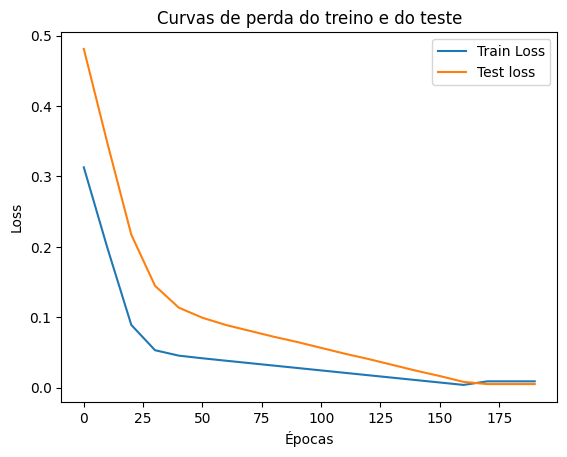

In [ ]:
# plot das curvas de perda
plt.plot(epoch_count, loss_values, label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Curvas de perda do treino e do teste")
plt.ylabel("Loss")
plt.xlabel("Épocas")
plt.legend()

In [ ]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
weight, bias

(0.7, 0.3)

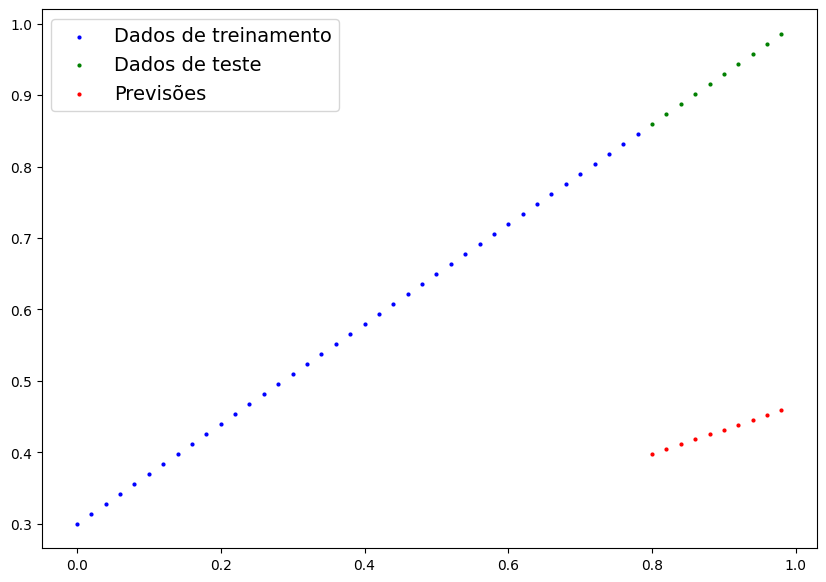

In [ ]:
plot_predictions(predictions = y_preds)

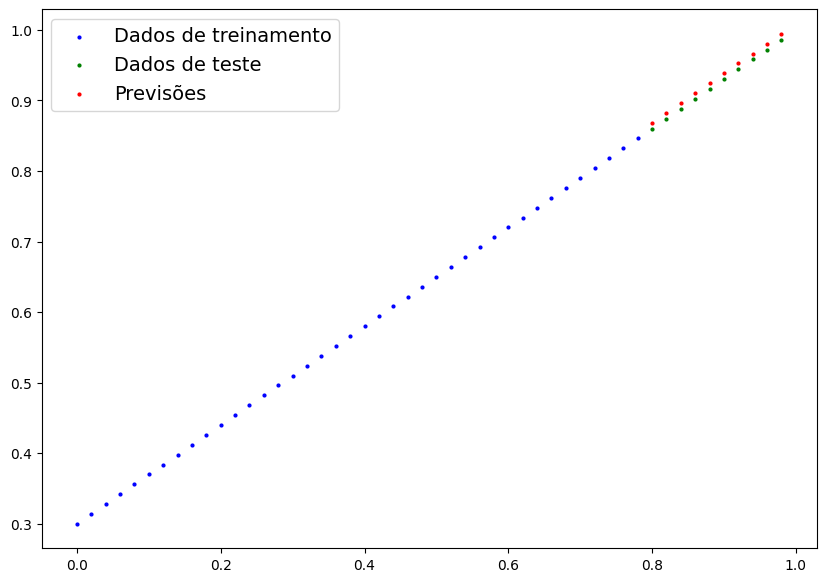

In [ ]:
plot_predictions(predictions = y_preds_new)

 ## Salvando um modelo em PyTorch

 Há três métodos principais que devemos saber sobre para salvar e carregar os modelos em PyTorch.

 1. `torch.save()` - permite que voce salve um objeto PyTorch em Python no formato pickle
 2. `torch.load()`- permite carregar um objeto PyTorch salvo
 3. `torch.nn.Module.load_state_dict()` - isso permite que voce carregue um state dictionary salvo de um modelo

In [ ]:
# Salvando nosso modelo PyTorch
from pathlib import Path

# 1. Crie um diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_0.pth" 
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando o modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),f =  MODEL_SAVE_PATH)

Salvando o modelo em: modelos/01_Pytorch_workflow_model_0.pth


In [ ]:
!ls -l modelos

total 4
-rw-rw-r-- 1 lucas lucas 2117 jun  5 23:10 01_Pytorch_workflow_model_0.pth


## Carregando um modelo PyTorch

Já que salvamos o `state_dict()` do nosso modelo  ao invés do modelo inteiro, criaremos uma nova instancia da nossa classe de modelo e carregaremos o `state_dict()` salvo

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Para carregar o nosso modelo, intanciamos uma nova classe
loaded_model_0 = LinearRegressionModel()

# Carregamos o state_dict salvo de model_0(isso atualizará a nova instância com parâmetros atualizados)
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Fazendo algumas previsões com nosso modelo carregado
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# Comparar as previsões do modelo carregado com as previsões do modelo original
loaded_model_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Juntando tudo isso

Vamos voltar às etapas acima e ver tudo em um só lugar.

In [ ]:
# Importando PyTorch e matplotlib
import torch 
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu130'

Criando um código independente de dispositivo.

Isso significa se tivermos acesso a GPU, nosso código a usará(paara uma potencial computação mais rápida).

Se não houver GPU disponível, o código terá como padrão o uso da CPU.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}")

cpu


### 6.1 Dados

In [ ]:
# Criar algun sdados usando a fórmula de regressão linear y = weight * X + bias
weight = 0.5
bias = 0.1

# Criando valores em um intervalo
start = 0
end = 1
step = 0.02
# Criar X e y(features e labels)
X = torch.arange(start,end,step).unsqueeze(dim = 1) # Sem unsqueeze erros aparecerão
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1100],
         [0.1200],
         [0.1300],
         [0.1400],
         [0.1500],
         [0.1600],
         [0.1700],
         [0.1800],
         [0.1900]]))

In [ ]:
# Dividindo os dados
div_train = int(0.8 * len(X))
X_train, y_train = X[:div_train], y[:div_train]
X_test, y_test = X[div_train:], y[div_train:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

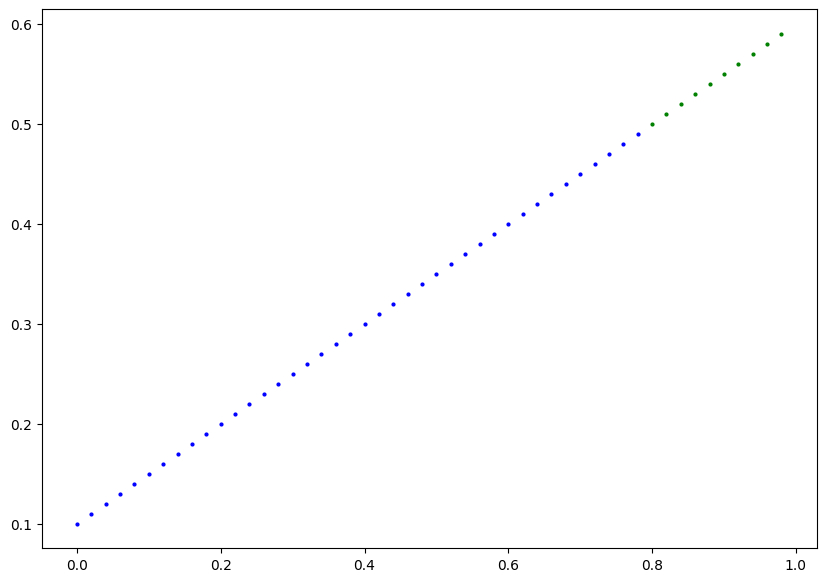

In [ ]:
# Plotando os dados
# NOte: Se você não tiver a função plot_predictions() carregada , isso resultará em erro
plot_predictions(X_train, y_train, X_test, y_test)


## 6.2 Construindo um modelo linear PyTorch

In [ ]:
# Criar um modelo linear por meio de umas subclasses de nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Usaremos nn.Linear() para criar os parâmetros do modelo / também chamado de transformação linear, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features = 1,
                                      out_features = 1)
 
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Definir a manual_seed para que tenhamos reprodutibilidade    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Checar o dispositivo atual do modelo
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### 6.3 Treinamento

Para treinamento nós precisamos:
* Loss function
* Otimizador
* Loop de treinamento
* Loop de teste


In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [ ]:
torch.manual_seed(42)

epocas = 200

# Colocar os dados no dispositivo de destino(device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

X_train = X_train.detach()
y_train = y_train.detach()
for epoca in range(epocas):
    model_1.train()

    y_pred = model_1(X_train)
    loss= loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        loss_test = loss_fn(test_pred, y_test)

    if epoca % 10 == 0:
        print(f"Epoca: {epoca} | Loss: {loss.item()} | Test Loss: {loss_test.item()}")

Epoca: 0 | Loss: 0.833177924156189 | Test Loss: 0.9519761800765991
Epoca: 10 | Loss: 0.7179681062698364 | Test Loss: 0.8172663450241089
Epoca: 20 | Loss: 0.6027581095695496 | Test Loss: 0.6825565695762634
Epoca: 30 | Loss: 0.487548291683197 | Test Loss: 0.5478467345237732
Epoca: 40 | Loss: 0.3723384439945221 | Test Loss: 0.41313689947128296
Epoca: 50 | Loss: 0.2571285367012024 | Test Loss: 0.2784270644187927
Epoca: 60 | Loss: 0.14191867411136627 | Test Loss: 0.1437171995639801
Epoca: 70 | Loss: 0.026708656921982765 | Test Loss: 0.00900720339268446
Epoca: 80 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 90 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 100 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 110 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 120 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 130 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoc

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
weight, bias

(0.5, 0.1)

### 6.4 Fazendo e avaliando previsões 

In [ ]:
# Colocar o modelo no modo de avaliação
model_1.eval()

# Fazendo previsões nos dados de teste
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds    

tensor([[0.5023],
        [0.5122],
        [0.5220],
        [0.5319],
        [0.5417],
        [0.5516],
        [0.5614],
        [0.5712],
        [0.5811],
        [0.5909]])

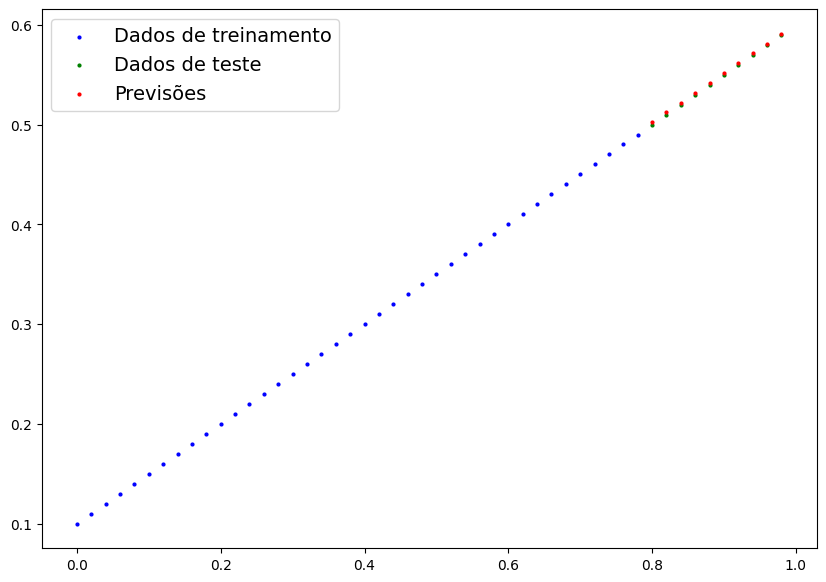

In [ ]:
# Checar as previsões do nosso modelo visualmente
plot_predictions(predictions = y_preds)


### 6.5 Salvando e carregando um modelo treinado 

In [ ]:
from pathlib import Path

# 1. Criar diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(), f = MODEL_SAVE_PATH)




Salvando modelo em: modelos/01_Pytorch_workflow_model_1.pth


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
# Carregar um modelo PyTorch

# Criamos uma nova instância do modelo de regressão linear V2
loaded_model_1 = LinearRegressionModelV2()

# Carregar o state dict do model_1 salvo
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))


# Colocar o modelo carregado  no dispositivo
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
# Avaliar o modelo carregado
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Exercicios e Extra-curricular

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
weight = 0.3
bias = 0.9
start = 0
end = 2
step = 0.01
X = torch.arange(start,end, step).unsqueeze(dim = 1)
y = weight * X + bias
len(X), len(y)

(200, 200)

In [ ]:
divisao_treino = int(0.8 * len(X))
X_treino, y_treino = X[:divisao_treino], y[:divisao_treino]
X_teste, y_teste = X[divisao_treino:], y[divisao_treino:]

len(X_treino), len(y_treino), len(X_teste), len(y_teste)

(160, 160, 40, 40)

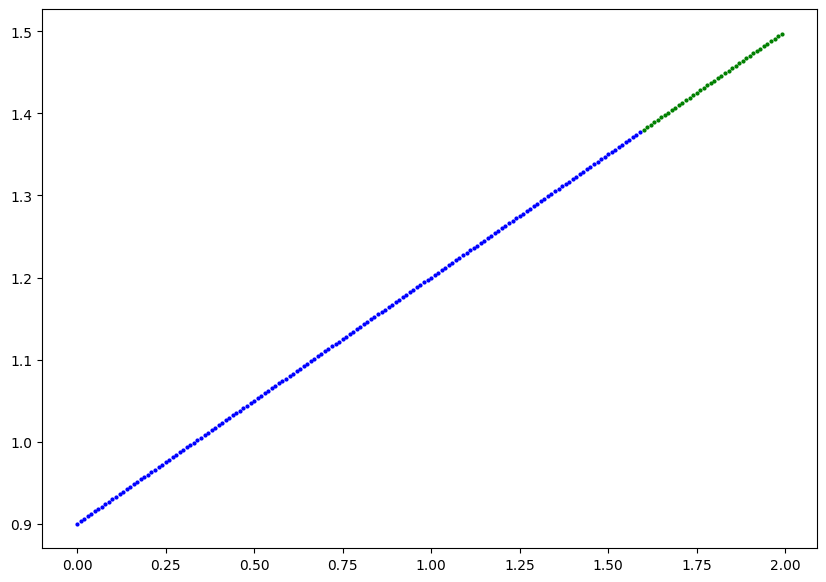

In [ ]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")

In [ ]:
class LinearRegressionModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features= 1,
                                out_features=1)
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear(x)    

In [ ]:
model_2 = LinearRegressionModelV3()
model_2.state_dict()

OrderedDict([('linear.weight', tensor([[0.9545]])),
             ('linear.bias', tensor([0.0826]))])

In [ ]:
funcao_perda = nn.L1Loss()

otimizador = torch.optim.SGD

In [ ]:
otimizador = otimizador(params = model_2.parameters(), lr = 0.001)

In [ ]:
epocas = 30000
for epoca in range(epocas):
    y_previsoes_treino = model_2(X_treino)
    perda_treino = funcao_perda(y_previsoes_treino, y_treino)
    otimizador.zero_grad()
    perda_treino.backward()
    otimizador.step()

    model_2.eval()
    with torch.inference_mode():
        y_previsoes_teste = model_2(X_teste)
        perda_teste = funcao_perda(y_previsoes_teste, y_teste)

    if epoca % 20 == 0:
        print(f"época: {epoca} | Perda no treino: {perda_treino} | Perda no teste: {perda_teste}")


época: 0 | Perda no treino: 0.015168559737503529 | Perda no teste: 0.030180955305695534
época: 20 | Perda no treino: 0.013358714990317822 | Perda no teste: 0.026562700048089027
época: 40 | Perda no treino: 0.011548980139195919 | Perda no teste: 0.02292739227414131
época: 60 | Perda no treino: 0.009739186614751816 | Perda no teste: 0.019326146692037582
época: 80 | Perda no treino: 0.007929443381726742 | Perda no teste: 0.01569082774221897
época: 100 | Perda no treino: 0.006119645666331053 | Perda no teste: 0.012055513449013233
época: 120 | Perda no treino: 0.004309860989451408 | Perda no teste: 0.00845426321029663
época: 140 | Perda no treino: 0.0025001198519021273 | Perda no teste: 0.004818952176719904
época: 160 | Perda no treino: 0.0006903245812281966 | Perda no teste: 0.0011835992336273193
época: 180 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 200 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 220 | Per

In [ ]:
model_2.eval()
with torch.inference_mode():
    y_previsoes_model_2 = model_2(X_teste)

    

In [ ]:
y_previsoes_model_2[:5],y_teste[:5]

(tensor([[1.3784],
         [1.3814],
         [1.3844],
         [1.3874],
         [1.3904]]),
 tensor([[1.3800],
         [1.3830],
         [1.3860],
         [1.3890],
         [1.3920]]))

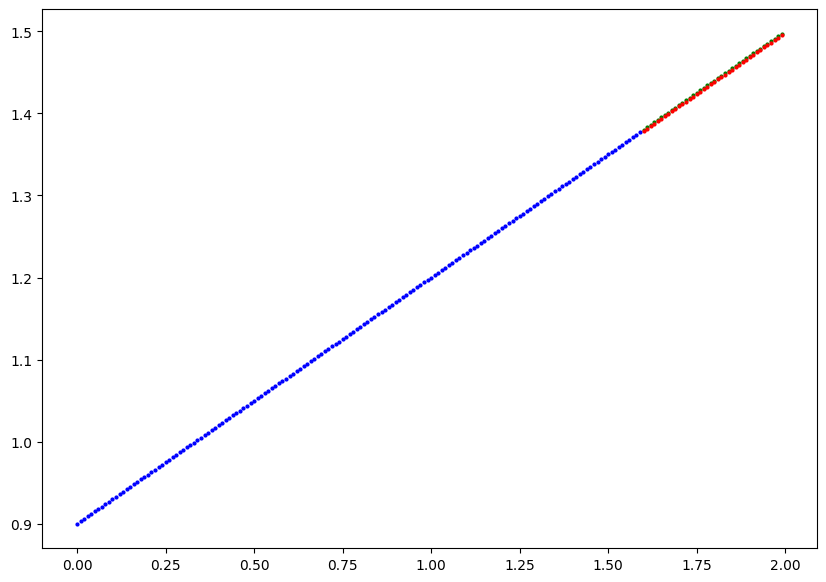

In [ ]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")
plt.scatter(X_teste, y_previsoes_model_2, c = "r", s = 4, label = "Previsões do modelo")

In [ ]:
from pathlib import Path

CAMINHO_MODELO = Path("modelos")
CAMINHO_MODELO.mkdir(parents = True, exist_ok = True)

NOME_MODELO = "01_Pytorch_workflow_model_2.pth"
CAMINHO_SALVO_MODELO = CAMINHO_MODELO / NOME_MODELO

print(f"Salvando modelo em: {CAMINHO_SALVO_MODELO}")
torch.save(obj = model_2.state_dict(), f = CAMINHO_SALVO_MODELO)

Salvando modelo em: modelos/01_Pytorch_workflow_model_2.pth


In [ ]:
loaded_model_2 = LinearRegressionModelV3()
loaded_model_2.load_state_dict(torch.load(CAMINHO_SALVO_MODELO))
y_preds_loaded = loaded_model_2(X_teste)
y_preds_loaded == y_previsoes_model_2

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 02. Classificação em redes neurais com Pytorch 

Classificação é um problema de prever se algo é uma coisa ou outra(pode ter varias coisas como opções)

## 1. Criar alguns dados de classificação e deixá-lo prontos

In [3]:
import sklearn

In [4]:
from sklearn.datasets import make_circles

# Criar 1000 amostras
n_amostras = 1000

# Criar circulos
X, y = make_circles(n_amostras,
                    noise = 0.03,
                    random_state=42)

In [5]:
len(X), len(y)

(1000, 1000)

In [6]:
print(f"Primeiras 5 amostras de X:{X[:5]}")
print(f"Primeiras 5 amostras de y:{ y[:5]}")


Primeiras 5 amostras de X:[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Primeiras 5 amostras de y:[1 1 1 1 0]


In [7]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [8]:
# Criar um DataFrame de dados circulares com Pandas
import pandas as pd
circulos = pd.DataFrame({"X1": X[:, 0], 
                         "X2": X[:,1],
                         "label": y})

circulos.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [9]:
circulos.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

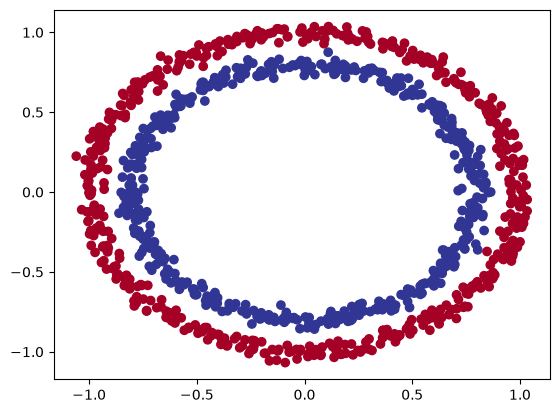

In [10]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

**Nota:** Os dados que estamos trabalhando são frequentemente mencionados como um conjunto de dados de brinquedo(toy dataset), um dataset que seja pequeno o suficiente para ser experimentado, mas grande o suficiente para praticar os fundamentos

### 1.1  Checar formatos (shapes) de entrada e saída

In [11]:
X.shape, y.shape

((1000, 2), (1000,))

In [12]:
# Veja o primeiro exemplo de features e labels
X_sample = X[0]
y_sample = y[0]
X_sample, y_sample

print(f"Valores para ua amostra de X: {X_sample} e o mesmo para y: {y_sample}")
print(f"Shape de uma amostra de X: {X_sample.shape}, o mesmo para y: {y_sample.shape}")

Valores para ua amostra de X: [0.75424625 0.23148074] e o mesmo para y: 1
Shape de uma amostra de X: (2,), o mesmo para y: ()


### 1.2 Transformando dados em tensores e criar divisões de treino e teste

In [13]:
import torch
torch.__version__

'2.12.1+cu130'

In [14]:
type(X)

numpy.ndarray

In [15]:
# Tranformar dados em tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [16]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [17]:
# Separar dados em conjuntos de treinamento e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state = 42)


In [18]:
len(X_treino), len(X_teste), len(y_treino), len(y_teste)

(800, 200, 800, 200)

## 2 Construindo um modelo

Vamos construir um modelo para classificar nossos pontos azuis e vermelhos.

Para isso, nós queremos:
1. Configurar o código agnóstico do dispositivo, portanto nosso codigo dera executado em um acelerador(GPU) se houver uma, se não houver será executado na CPU
2. Construir o modelo(pela subclasse `nn.Module`)
3. Definir a função de perda e o otimizador
4. Criar um loops de treinamento e de teste



In [19]:
import torch
from torch import nn

# Fazer o código agnóstico
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [20]:
X_treino

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Agora nós temos o código agnóstico de dispositivo configurado, vamos criar um modelo que:

1. Subclasse de `nn.Module`(quase todos os modelos são da subclasse Pytorch `nn.Module`)
2. Criar 2 camadas `nn.Linear()` e queremos que eles sejam capazes de lidar com os formatos dos nossos dados
3. Definir o método `forward()` que delimita o forward pass(ou forward computation) do modelo
4. Instanciar uma instância da nossa classe do modelo e envia-la para o `dispositivo` alvo



In [21]:
X_treino.shape

torch.Size([800, 2])

In [22]:
# 1. Construir um modelo com a subclasse nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Criar duas camadas nn.Linear capazes de manipular as formas dos nossos dados
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5) # pega duas entradas e transforma em cinco saídas
        self.layer_2 = nn.Linear(in_features = 5, out_features = 1) # recebe 5 saídas da camada anterior e transforma em uma saída(mesmo formato de y)

    # 3. Definindo o método forward
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> saída
    

# 4. Instanciar uma classe do nosso modelo e enviá-la para o dispositivo de destino
model_1_0 = CircleModelV0().to(device)
model_1_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [23]:
device

'cpu'

In [24]:
next(model_1_0.parameters()).device

device(type='cpu')

In [25]:
# Vamos replicar o modelo acima usando nn.Sequential()
model_1_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features= 5, out_features = 1)
).to(device)

model_1_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [26]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0242,  0.3380],
                      [-0.5884, -0.2712],
                      [ 0.3457, -0.3203],
                      [-0.6622, -0.3306],
                      [ 0.3036,  0.0689]])),
             ('0.bias', tensor([ 0.3407, -0.3590, -0.6164,  0.4249, -0.5763])),
             ('1.weight',
              tensor([[-0.0187, -0.1585,  0.1217, -0.0824, -0.0095]])),
             ('1.bias', tensor([0.2358]))])

In [27]:
# Fazer algumas previsões com o modelo
with torch.inference_mode():
    untrained_preds = model_1_0(X_teste.to(device))
print(f"tamanho das previsões: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Tamanho das amostras de teste: {len(X_teste)}, Shape: {X_teste.shape}")
print(f"\nPrimeiras 10 previsões:\n{torch.round(untrained_preds[:10])}")
print(f"\n Primeiros 10 rótulos(labels):\n{y_teste[:10]}")


tamanho das previsões: 200, Shape: torch.Size([200, 1])
Tamanho das amostras de teste: 200, Shape: torch.Size([200, 2])

Primeiras 10 previsões:
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])

 Primeiros 10 rótulos(labels):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [28]:
X_teste[:10] , y_teste[:10] 

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Configurar a função de perda e o otimizador

Qual função de perda ou otimizador deve-se usar?

De novo... isso é especifivo do problema.

Por exemplo para regressão você pode escolher o MAE ou MSE (mean absolute error or mean squared error).

Para classificação voce pode escolher a entropia cruzada binária(binary cross entropy) ou entropia cruzada categórica(cross entropy).

Como um lembrete, a função de perda mede o quanto as previsões do modelo estão **erradas**.

E para os otimizadores, dois dos mais comuns e úteis são o SGD e o Adam, no entanto pytorch tem muitas opções integradas.

* Para a função de perda, vamos usar `torch.nn.BCEWithLogitsLoss()`
* Para diferentes otimizadores ver `torch.optim()`

In [29]:
#loss_fn = nn.BCELoss() #BCELoss = requer que as entradas tenham passado pela função de ativação sigmoide antes de serem inseridas na BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss tem a ativação sigmoide incorporada

otimizador = torch.optim.SGD(params = model_1_0.parameters(),
                             lr = 0.001
                             )

In [26]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/ len(y_pred)) * 100
    return acc

## 3. Treinamento de um modelo

Para treinar nosso modelo, precisaremos criar um loop de treinamento com as seguintes etapas:
1. Forward pass(inferencia)
2. Calcular a perda
3. Zerar os gradientes
4. Backpropagation
5. Otimizador(descida do gradiente)


### 3.1 Vamos passar de logits -> probabilidade de previsão -> previsão de rótulos

Os resultados de nosso modelo serão **logits**.

Podemos converter esses **logits** em **probabilidades de previsão** passando por eles para terem algum tipo de função de ativação(sigmoide para entropia cruzada binaria e softmax para clasificação multiclasse).

Então nós podemos converter as probabilidades de previsão do nosso modelo em **previsão de rótulos** arredondando-os ou usando `argmax()`.

In [31]:
# Veja as 5 primeiras saídas da inferência nos dados de teste
model_1_0.eval()
with torch.inference_mode():
    y_logits = model_1_0(X_teste.to(device))[:5]
y_logits

tensor([[0.1280],
        [0.2079],
        [0.0424],
        [0.1517],
        [0.2392]])

In [32]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

In [33]:
# Usar a funçao de ativação sigmóide em nosso modelo logits para transformá-los em probabilidades de previsão
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5319],
        [0.5518],
        [0.5106],
        [0.5379],
        [0.5595]])

Para nossos valores de probabilidade de previsão, precisamos realizar um arredondamento de range-style neles:
* `y_pred_probs` >= 0.5, `y=1` (classe 1)
* `y_pred_probs` < 0.5, `y=0` (classe 0)

In [34]:
# Encontrando os rótulos previstos
y_preds = torch.round(y_pred_probs)

# Por completo(logits -> probabilidade das previsoes -> previsoes dos rótulos(labels))
y_pred_labels = torch.round(torch.sigmoid(model_1_0(X_teste.to(device))[:5]))

# Checar se há igualdade
print(torch.equal(y_preds.squeeze(), y_pred_labels.squeeze()))

# Fazer isso para se livrar da dimensão extra mais uma vez
y_preds.squeeze()

True


tensor([1., 1., 1., 1., 1.])

In [35]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Construindo loops de treinamento e teste

In [36]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Definir o número de épocas
epochs = 100

# Vamos colocar os dados no dispositivo de destino
X_treino, y_treino = X_treino.to(device), y_treino.to(device)
X_teste, y_teste = X_teste.to(device), y_teste.to(device)

# Criar nosso loop de treinamento e avaliação
for epoch in range(epochs):
    ### Treinamento
    model_1_0.train()

    # 1. Forward pass
    y_logits = model_1_0(X_treino).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # transformar logits -> probabilidades de previsão -> probabilidade de rótulos


    # 2. Calcular a perda/acurácia
    #loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss espera probabilidades de previsão como entrada
    #               y_treino)
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss espera logits brutos como entrada 
                   y_treino)
    acc = accuracy_fn(y_true = y_treino,
                      y_pred = y_pred)
    

    # 3. Otimizador zero grad
    otimizador.zero_grad()

    # 4. Loss backward(backpropagation)
    loss.backward()

    # 5. Etapa do otimizador(descida do gradiente)
    otimizador.step()

    ### Teste
    model_1_0.eval()
    with torch.inference_mode():
        # 1. Forward pass(inferência)
        test_logits = model_1_0(X_teste).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calcular a perda do teste/precisão
        test_loss = loss_fn(test_logits,
                            y_teste)
        test_acc = accuracy_fn(y_true = y_teste,
                            y_pred= test_pred)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        print(f"Época: {epoch} | Perda: {loss:.5f} | Acc: {acc:.2f}% | Perda do teste: {test_loss:.5f} | Precisão no teste: {test_acc:.2f}%")







Época: 0 | Perda: 0.69849 | Acc: 53.87% | Perda do teste: 0.70165 | Precisão no teste: 53.00%


Época: 10 | Perda: 0.69845 | Acc: 54.12% | Perda do teste: 0.70161 | Precisão no teste: 53.00%
Época: 20 | Perda: 0.69841 | Acc: 54.62% | Perda do teste: 0.70156 | Precisão no teste: 53.00%
Época: 30 | Perda: 0.69837 | Acc: 55.00% | Perda do teste: 0.70152 | Precisão no teste: 53.00%
Época: 40 | Perda: 0.69833 | Acc: 55.38% | Perda do teste: 0.70148 | Precisão no teste: 53.00%
Época: 50 | Perda: 0.69830 | Acc: 55.38% | Perda do teste: 0.70144 | Precisão no teste: 53.00%
Época: 60 | Perda: 0.69826 | Acc: 55.62% | Perda do teste: 0.70140 | Precisão no teste: 54.00%
Época: 70 | Perda: 0.69822 | Acc: 55.75% | Perda do teste: 0.70136 | Precisão no teste: 54.00%
Época: 80 | Perda: 0.69819 | Acc: 56.38% | Perda do teste: 0.70132 | Precisão no teste: 54.00%
Época: 90 | Perda: 0.69815 | Acc: 56.62% | Perda do teste: 0.70128 | Precisão no teste: 54.50%


## 4. Fazendo previsões e avaliando o modelo

Pelas métricas parece que o nosso modelo não está aprendendo nada...

Para inspecionar isso vamos fazer algumas previsões e torná-las visuais!

Em outras palavras, "Visualize, visualize, visualize"

Para fazer isso, vamos importar uma função chamada `plot_decision_boundary()`   - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py


In [37]:
import requests
from pathlib import Path

# Baixe as "helper functions" do repositorio Learn Pytorch (se ainda não tiver sido baixado)
if Path("helper_functions.py").is_file():
    print(f"helper_functions.py já existe, skipando o download")
else:
    print(f"Download helper_functions.py")
    request =  requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary



helper_functions.py já existe, skipando o download


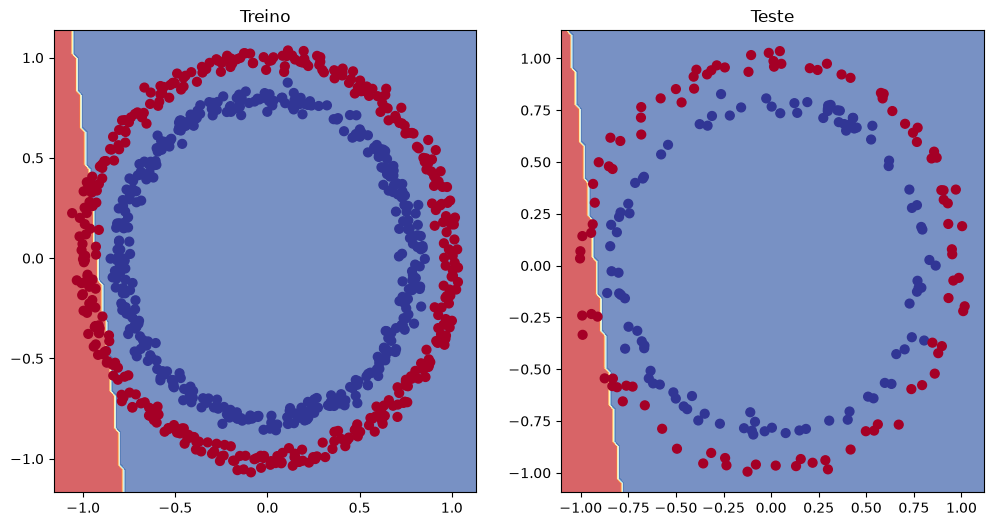

In [38]:
# Plotar o limite de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_0, X_treino, y_treino)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_0, X_teste, y_teste)






## 5. Melhorando um modelo(a partir de uma perspectiva do modelo)

* Adicionar mais camadas - dar ao modelo mais chances de aprender sobre os padrões nos dados
* Adicionar mais unidade ocultas - ir de 5 unidades ocultas para 10
* Inferir por mais tempo, dar ao modelo mais chances de aprender
* Mudar as funções de ativação
* Mudar o learning rate(passo da descida do gradiente)
* Trocar a função de perda

Essas opções são todas da perspectiva do nosso modelo, porque elas lidam diretamente com o modelo e não com os dados

E como todas essas opções são valores, nós (como engenheiros de machine learning e cientista de dados ) podemos mudar,  o que podemos mudar (referenciar) são chamados de **hiperparametros**

Vamos tentar melhorar nosso modelo:
* Adicionando mais unidades ocultas: 5 -> 10
* Aumentando o número de camadas: 2 -> 3
* Aumentando o número de épocas: 100 -> 1000



In [39]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0242,  0.3380],
                      [-0.5881, -0.2712],
                      [ 0.3455, -0.3202],
                      [-0.6620, -0.3306],
                      [ 0.3036,  0.0689]])),
             ('0.bias', tensor([ 0.3408, -0.3583, -0.6169,  0.4252, -0.5763])),
             ('1.weight',
              tensor([[-0.0200, -0.1560,  0.1237, -0.0833, -0.0074]])),
             ('1.bias', tensor([0.2314]))])

In [40]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1) 
    def forward(self, x):
        #z = self.layer_1(x)
        #z = self.layer_2(z)
        #z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) # essa maneira de escrever operações  aproveita os aumentos de velocidade nos bastidores
    

model_1_1 = CircleModelV1().to(device)
model_1_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [41]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0242,  0.3380],
                      [-0.5881, -0.2712],
                      [ 0.3455, -0.3202],
                      [-0.6620, -0.3306],
                      [ 0.3036,  0.0689]])),
             ('0.bias', tensor([ 0.3408, -0.3583, -0.6169,  0.4252, -0.5763])),
             ('1.weight',
              tensor([[-0.0200, -0.1560,  0.1237, -0.0833, -0.0074]])),
             ('1.bias', tensor([0.2314]))])

In [42]:
model_1_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [43]:
loss_fn_1 = nn.BCEWithLogitsLoss()
otimizador_1 = torch.optim.SGD(params = model_1_1.parameters(), lr = 0.1)

In [44]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epocas = 1000
X_treino, y_treino = X_treino.to(device), y_treino.to(device)
X_teste, y_teste = X_teste.to(device), y_teste.to(device)

for epoca in range(epocas):
    model_1_1.train()
    logits_1 = model_1_1(X_treino).squeeze()
    y_pred_1 = torch.round(torch.sigmoid(logits_1))
    loss = loss_fn_1(logits_1, y_treino)
    acc = accuracy_fn(y_true = y_treino, y_pred = y_pred_1)
    otimizador_1.zero_grad()
    loss.backward()
    otimizador_1.step()


    model_1_1.eval()
    with torch.inference_mode():
        logits_teste = model_1_1(X_teste).squeeze()
        y_pred_1_teste = torch.round(torch.sigmoid(logits_teste))
        loss_teste = loss_fn_1(logits_teste, y_teste)
        acc_teste = accuracy_fn(y_true = y_teste, y_pred = y_pred_1_teste)
    if(epoca % 100 == 0):
        print(f" Época: {epoca} | Perda no treino: {loss:.5f} | Acurácia no treino: {acc:.2f}% | Perda no teste: {loss_teste:.5f} | Acurácia no teste: {acc_teste:.2f}%")



 Época: 0 | Perda no treino: 0.69396 | Acurácia no treino: 50.88% | Perda no teste: 0.69261 | Acurácia no teste: 51.00%
 Época: 100 | Perda no treino: 0.69305 | Acurácia no treino: 50.38% | Perda no teste: 0.69379 | Acurácia no teste: 48.00%
 Época: 200 | Perda no treino: 0.69299 | Acurácia no treino: 51.12% | Perda no teste: 0.69437 | Acurácia no teste: 46.00%
 Época: 300 | Perda no treino: 0.69298 | Acurácia no treino: 51.62% | Perda no teste: 0.69458 | Acurácia no teste: 45.00%
 Época: 400 | Perda no treino: 0.69298 | Acurácia no treino: 51.12% | Perda no teste: 0.69465 | Acurácia no teste: 46.00%
 Época: 500 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69467 | Acurácia no teste: 46.00%
 Época: 600 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69468 | Acurácia no teste: 46.00%
 Época: 700 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69468 | Acurácia no teste: 46.00%
 Época: 800 | Perda no tre

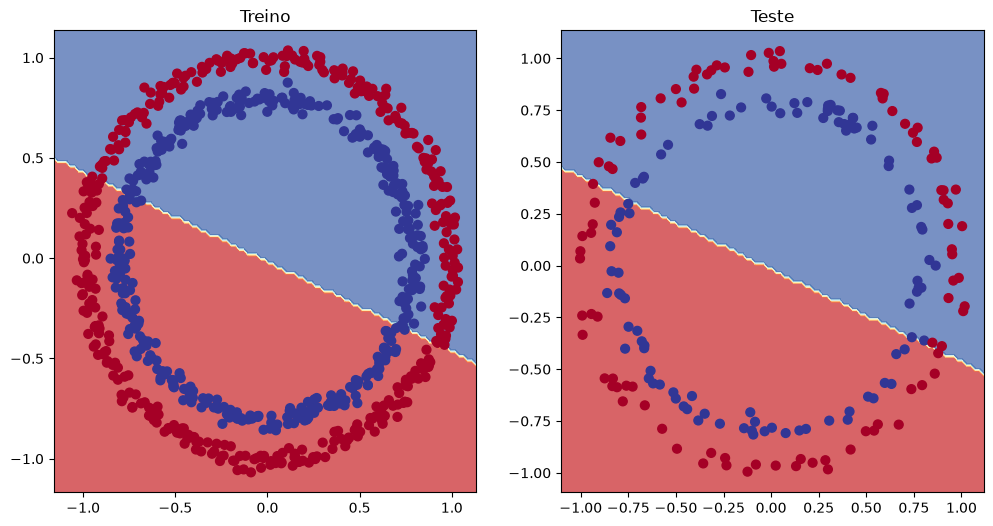

In [45]:
# Plotar o limite de decisão
# Plotar o limite de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_1, X_treino, y_treino)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_1, X_teste, y_teste)






### 5.1 Vamos preparar os dados para ver se o nosso modelo pode se ajustar a uma linha reta

Uma maneira de solucionar problemas maiores é testando problemas menores

In [46]:
# Criando alguns dados(mesmo que a seção 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Criando dados
X_regression = torch.arange(start,end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias # Fórmula da regressão linear (sem epsilon)

# Verificar os dados
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [47]:
# Criar divisões de treinamento e teste
train_split = int(len(X_regression)* 0.8)
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression , y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Checar os comprimentos
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

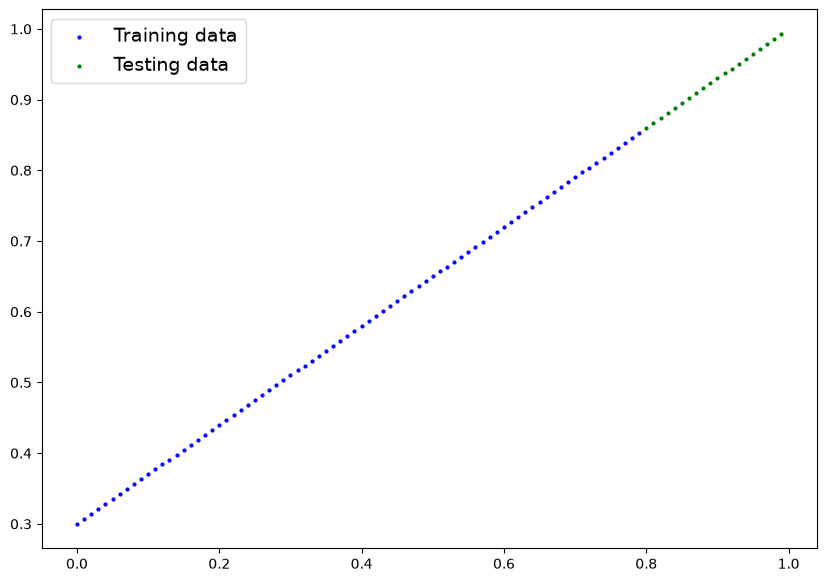

In [48]:
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [49]:
X_train_regression[:10], y_train_regression[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

### 5.2 Ajustando `model_1_1` à uma linha reta

In [50]:
# Mesma arquitetura do modelo 1 (mas usando nn.Sequential())
model_1_2 = nn.Sequential(nn.Linear(in_features = 1, out_features = 10),
                          nn.Linear(in_features = 10, out_features = 10),
                          nn.Linear(in_features = 10, out_features = 1)).to(device)

model_1_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [51]:
# Função perda e otimizador
loss_fn = nn.L1Loss() # MAE loss com dados de regressão
optimizer = torch.optim.SGD(params = model_1_2.parameters(),
                            lr = 0.01)

In [52]:
# Treinar o modelo
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Configurar o número de épocas
epochs = 1000

# Colocar nossos dados no dispositivo de destino
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Treino
for epoch in range(epochs):
    model_1_2.train()
    y_pred =  model_1_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_2.eval()
    with torch.inference_mode():
        y_pred_test = model_1_2(X_test_regression)
        test_loss = loss_fn(y_pred_test, y_test_regression)
    if epoch % 100 == 0:
        print(f"Época: {epoch} | Perda: {loss:.5f} | Perda no teste: {test_loss:.5f}")



Época: 0 | Perda: 0.75986 | Perda no teste: 0.91103
Época: 100 | Perda: 0.02858 | Perda no teste: 0.00081
Época: 200 | Perda: 0.02533 | Perda no teste: 0.00209
Época: 300 | Perda: 0.02137 | Perda no teste: 0.00305
Época: 400 | Perda: 0.01964 | Perda no teste: 0.00341
Época: 500 | Perda: 0.01940 | Perda no teste: 0.00387
Época: 600 | Perda: 0.01903 | Perda no teste: 0.00379
Época: 700 | Perda: 0.01878 | Perda no teste: 0.00381
Época: 800 | Perda: 0.01840 | Perda no teste: 0.00329
Época: 900 | Perda: 0.01798 | Perda no teste: 0.00360


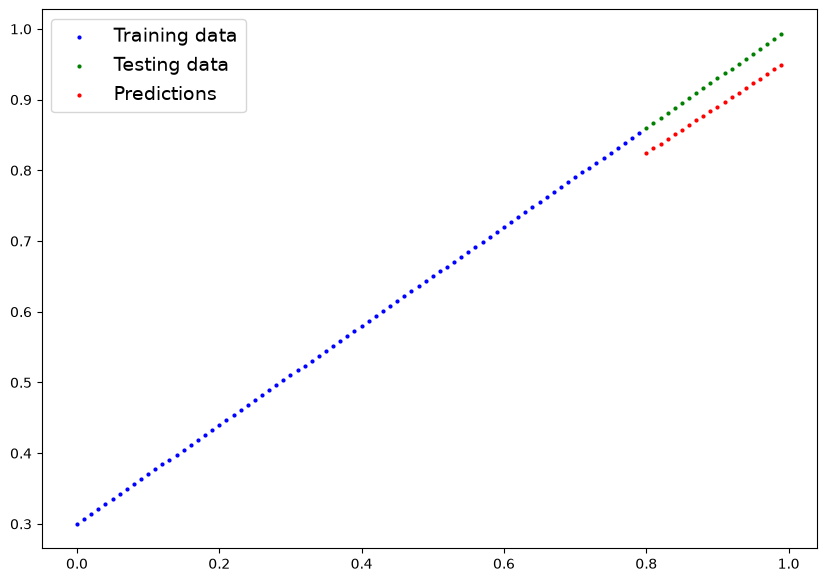

In [53]:
# Ligar o método de avaliação
model_1_2.eval()

# Fazer previsões (inferencia)
with torch.inference_mode():
    y_preds = model_1_2(X_test_regression)

# Plotar os dados e as previsões
plot_predictions(train_data = X_train_regression.cpu(),
                  train_labels = y_train_regression.cpu(),
                  test_data = X_test_regression.cpu(),
                  test_labels = y_test_regression.cpu(),
                  predictions = y_preds.cpu())

## 6. A peça que faltava em nossso modelo: não linearidade

"Quais padões você poderia desenhar se fosse lhe dado um quantidade infinita de linhas retas e não retas?"

Ou em termos de machine learning, infinitas (mas na realidade é finito) de funções lineares e não lineares

### 6.1 Recriando dados não lineares (circulos vermelhos e azuis)

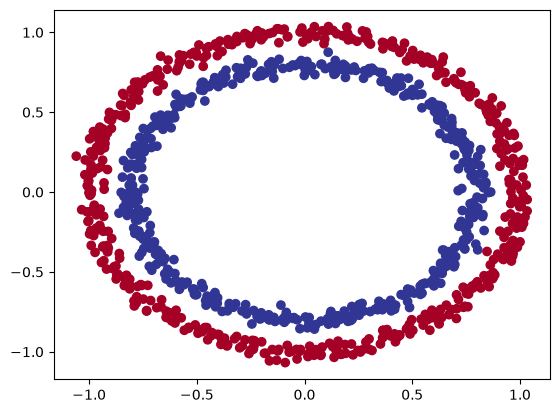

In [54]:
# Criar e plotar dados
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

plt.scatter(X[:,0], X[:,1], c = y, cmap = plt.cm.RdYlBu)

In [55]:
# Converter os dados para tensores e depois para divisõpes de treinamento e teste
import torch
from sklearn.model_selection import train_test_split

# Transformar dados em tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Separar em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Construindo um modelo com não linearidade

* Linear = linhas retas
* Não linear = linhas não retas

Redes neurais artificiais são uma grande combinação de  funções lineares (retas) e não lineares(não retas) que são potencialmente capazes de encontrar padrões nos dados.

In [56]:
# Criar um modelo com funções de ativações não lineares
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU() # Relu é uma função de ativação não linear

    def forward(self, x):
        # Onde devemos colocar nossas funções de ativações não lineares
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1_3 = CircleModelV2().to(device)
model_1_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [57]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1_3.parameters(),
                            lr = 0.1)

### 6.3  Treinamento de um modelo com não-linearidade

In [58]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_1_3.train()
    y_logits = model_1_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train, y_pred = y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_3.eval()
    with torch.inference_mode():
        test_logits = model_1_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)
    if epoch % 100 == 0:
        print(f"Época: {epoch} | Loss: {loss:.4f} | Acurácia treino: {acc:.2f}% | Loss teste: {test_loss:.4f} | Acurácia teste: {test_acc:.2f}%")

Época: 0 | Loss: 0.6929 | Acurácia treino: 50.00% | Loss teste: 0.6932 | Acurácia teste: 50.00%
Época: 100 | Loss: 0.6912 | Acurácia treino: 52.88% | Loss teste: 0.6910 | Acurácia teste: 52.50%
Época: 200 | Loss: 0.6898 | Acurácia treino: 53.37% | Loss teste: 0.6894 | Acurácia teste: 55.00%
Época: 300 | Loss: 0.6879 | Acurácia treino: 53.00% | Loss teste: 0.6872 | Acurácia teste: 56.00%
Época: 400 | Loss: 0.6852 | Acurácia treino: 52.75% | Loss teste: 0.6841 | Acurácia teste: 56.50%
Época: 500 | Loss: 0.6810 | Acurácia treino: 52.75% | Loss teste: 0.6794 | Acurácia teste: 56.50%
Época: 600 | Loss: 0.6751 | Acurácia treino: 54.50% | Loss teste: 0.6729 | Acurácia teste: 56.00%
Época: 700 | Loss: 0.6666 | Acurácia treino: 58.38% | Loss teste: 0.6632 | Acurácia teste: 59.00%
Época: 800 | Loss: 0.6516 | Acurácia treino: 64.00% | Loss teste: 0.6476 | Acurácia teste: 67.50%
Época: 900 | Loss: 0.6236 | Acurácia treino: 74.00% | Loss teste: 0.6215 | Acurácia teste: 79.00%


### 6.4 Avaliando nosso modelo com funções de ativação não lineares

In [59]:
# Inferência
model_1_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_1_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

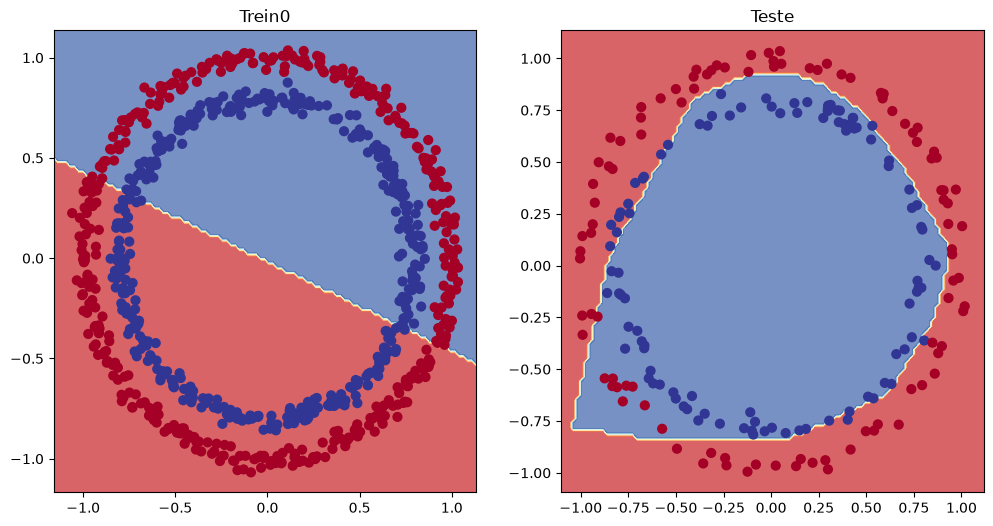

In [60]:
# Plotar os limites de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Trein0")
plot_decision_boundary(model_1_1, X_train, y_train) # model_1_1 = sem não linearidade
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_3, X_test, y_test) # model_1_3 = com não linearidade

## 7. Replicando funções de ativação não lineares

Redes neurais, em vez de dizermos ao modelo o que ele deve aprender, fornecemos a ele as ferramentas para descobrir padrões nos dados e assim tenta descobrir os melhores padões por conta própria.

E essas ferramentas são funções lineares e não lineares

In [61]:
# Criando um tensor
A = torch.arange(-10,10,1, dtype = torch.float32)
A.dtype

torch.float32

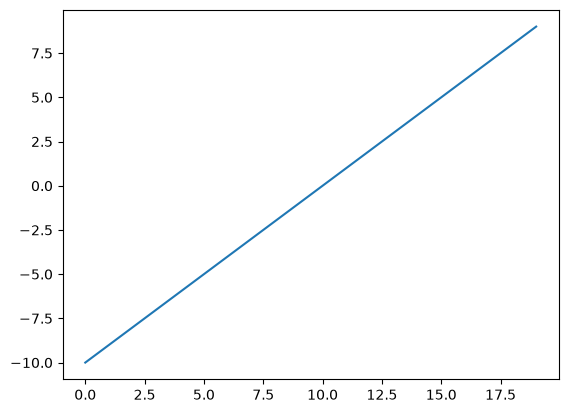

In [62]:
# Visualizar esse tensor
plt.plot(A)

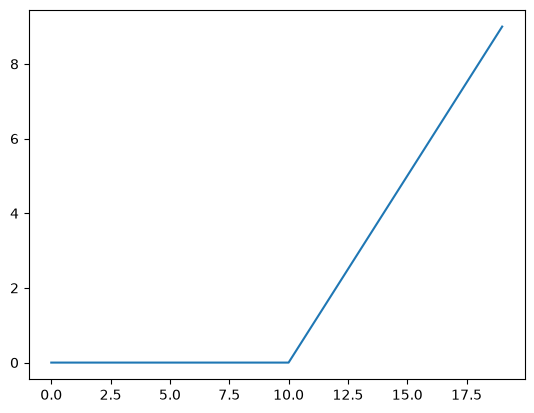

In [63]:
plt.plot(torch.relu(A))

In [64]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # entradas tem que ser tensores

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

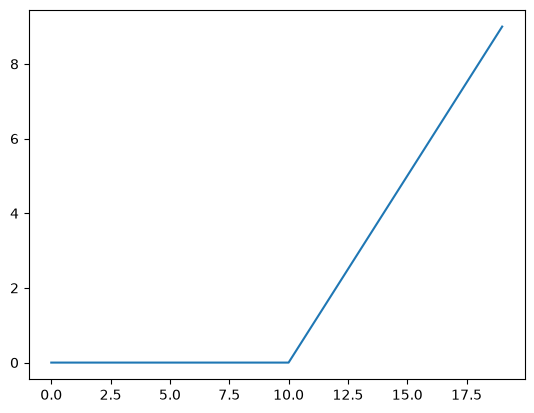

In [65]:
# Plot  função de ativação ReLU
plt.plot(relu(A))

In [66]:
# Agora vamos fazer o mesmo para sigmoid
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

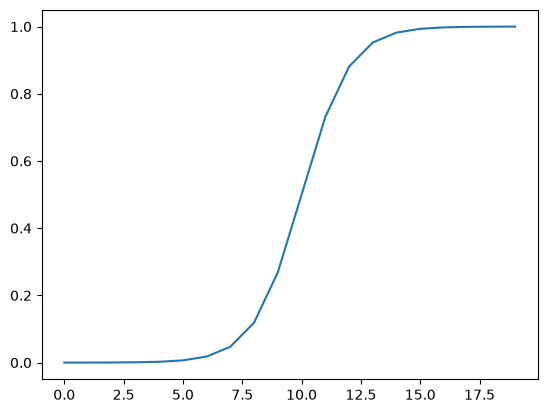

In [67]:
plt.plot(torch.sigmoid(A))

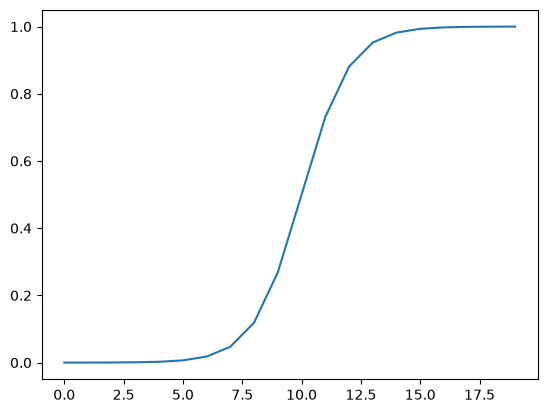

In [68]:
plt.plot(sigmoid(A))

## 8. Colocando tudo junto com um problema de classificação multiclasse

* Classificação binária = uma coisa ou outra(gato ou cachorro, spam ou não spam) 
* Classificação multiclasse = mais que uma coisa ou outra( cachorro ou gato ou galinha)

### 8.1 Criação de um conjunto brinquedo de dados multiclasse

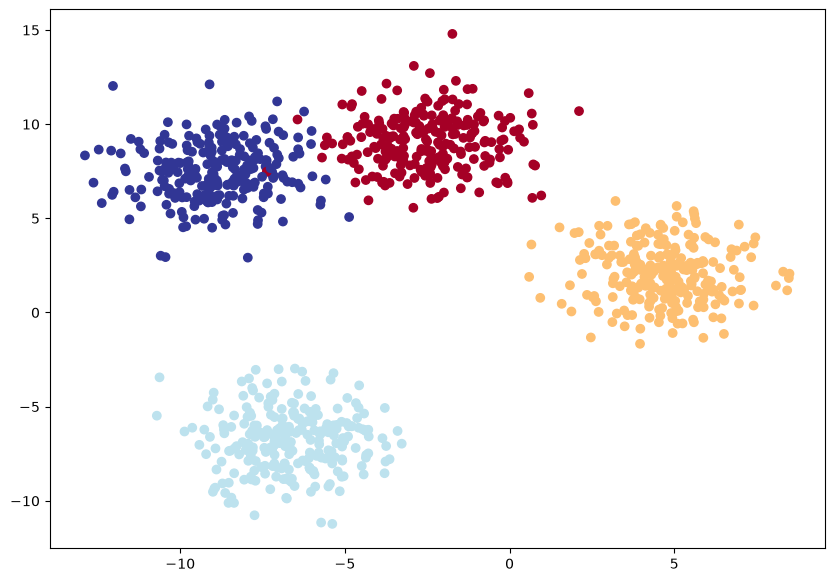

In [69]:
# Importar dependencias
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Definir o número de hiperparametros para a criação de dados
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Criar dados multiclasse
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED) # adicionar um pouco de aleatoriedade aos dados

# 2. Transformar dados em tensores
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Dividindo em treino e teste
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# 4. Plotar os dados(visualize, visualize, visualize)
plt.figure(figsize = (10,7))
plt.scatter(X_blob[:, 0], X_blob[:,1], c = y_blob, cmap = plt.cm.RdYlBu)





### 8.2 Criando um modelo de classificação multiclasse no PyTorch

In [70]:
# Criar o código independente de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [71]:
# Criar um modelo de classificação multiclasse
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        """Inicializar o modelo de classificação multiclasse.
        Args:
            input_features (int): Numero de recursos de entrada para o modelo
            output_features (int): Numero de recursos de saida do modelo (número de classes de saída)
            hidden_units (int): Numero de unidades ocultas entre camadas, default = 8
        """
        super().__init__()
        self.linear_layer_stack  = nn.Sequential(
            nn.Linear(in_features = input_features, out_features = hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

# Ciar uma instancia do BlobModel e enviá-la ao dispositivo de destino
model_1_4 = BlobModel(input_features = 2, 
                      output_features = 4,
                      hidden_units = 8).to(device)

model_1_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [72]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [73]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 8.3 Criar a função de perda e um otimizador para um modelo de classificação multiclasse


In [74]:
# Criar uma função de perda para classificação multiclasse - função de perda mede quanto as previsões do nosso modelo estão erradas
loss_fn = nn.CrossEntropyLoss()

# Criar um otimizador para classificação multiclasse - otimizador atualiza os paramêtros do nosso modelo para tentar reduzir a perda
optimizer = torch.optim.SGD(params = model_1_4.parameters(),
                            lr = 0.1) # learning rate é um hiperparametro, logo podemos mudar

### 8.4 Obter probabilidades de previsão para um modelo multiclasse PyTorch

Para avaliar,treinar e testar nosso modelo, precisamos converter as saidas do modelo (logits) para probabilidades de previsão e depois para rótulos de previsão.

Logits (saída bruta do modelo) -> probabilidades de previsão (use `torch.softmax`) -> rótulos de previsão (Pegue o argmax das probabilidades de previsão)

In [75]:
# Vamos obter alguns resultados brutos do nosso modelo(logits)
model_1_4.eval()
with torch.inference_mode():
    y_logits = model_1_4(X_blob_test.to(device))

y_logits[:10]


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]])

In [76]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [77]:
# Converter os resultados logit de nossos modelos em probabilidades de previsão
y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_logits[:5])
print(y_pred_probs[:5])


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])


In [78]:
# Converter as probabilidades de previsão do nosso modelo em rótulos de previsão
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3])

In [79]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 8.5 Criar um loop de treinamento e um de teste para um modelo PyTorch multiclasses

In [80]:
y_blob_train.dtype

torch.int64

In [81]:
# Ajustar o modelo multiclasse aos dados
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Definir o número de épocas
epochs = 100

# Colocar os dados no dispositivo de destino
X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

for epoch in range(epochs):

    model_1_4.train()

    y_logits = model_1_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    # print(test_logits.shape, y_blob_test.shape)
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true = y_blob_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_4.eval()
    with torch.inference_mode():

        test_logits = model_1_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test, y_pred = test_preds)
        
    if epoch % 10 == 0:
        print(f"Época: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Loss teste: {test_loss:.4f} | Acc teste: {test_acc:.2f}%")

Época: 0 | Loss: 1.0432 | Acc: 65.50% | Loss teste: 0.5786 | Acc teste: 95.50%


Época: 10 | Loss: 0.1440 | Acc: 99.12% | Loss teste: 0.1304 | Acc teste: 99.00%
Época: 20 | Loss: 0.0806 | Acc: 99.12% | Loss teste: 0.0722 | Acc teste: 99.50%
Época: 30 | Loss: 0.0592 | Acc: 99.12% | Loss teste: 0.0513 | Acc teste: 99.50%
Época: 40 | Loss: 0.0489 | Acc: 99.00% | Loss teste: 0.0410 | Acc teste: 99.50%
Época: 50 | Loss: 0.0429 | Acc: 99.00% | Loss teste: 0.0349 | Acc teste: 99.50%
Época: 60 | Loss: 0.0391 | Acc: 99.00% | Loss teste: 0.0308 | Acc teste: 99.50%
Época: 70 | Loss: 0.0364 | Acc: 99.00% | Loss teste: 0.0280 | Acc teste: 99.50%
Época: 80 | Loss: 0.0345 | Acc: 99.00% | Loss teste: 0.0259 | Acc teste: 99.50%
Época: 90 | Loss: 0.0330 | Acc: 99.12% | Loss teste: 0.0242 | Acc teste: 99.50%


### 8.6 Fazendo e avaliando as previsões de um modelo multiclasse PyTorch

In [82]:
# Fazer previsões
model_1_4.eval()
with torch.inference_mode():
    y_logits = model_1_4(X_blob_test)

# Ver as primeiras dez previsões  
y_logits[:10] 

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

In [83]:
# Vamos passar de logits -> probabilidades de previsão
y_pred_probs = torch.softmax(y_logits, dim = 1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3697e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2266e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5435e-08, 4.7619e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4287e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9937e-08, 1.0045e-03],
        [3.0436e-14, 6.8303e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0767e-09, 2.0006e-04]])

In [84]:
# Vamos passar de probabilidades de previsão -> previsão de rótulos
y_preds = y_pred_probs.argmax(dim = 1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

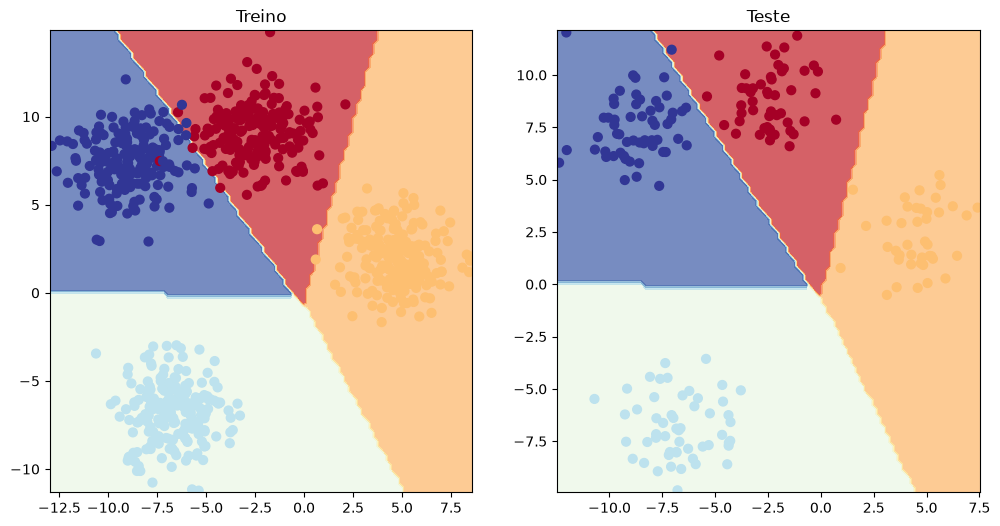

In [85]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_4, X_blob_test, y_blob_test)


## 9. Mais algumas métricas de classificação... (para avaliar nosso modelo  de classificação)

* Acurácia - Com 100 amostras, quantas nosso modelo acerta?
* Precisão
* Recall
* F1-score
* Matriz de confusão
* Classificaton report (relatório de classificação)


In [86]:
from torchmetrics import Accuracy

# Configurar a métrica
torchmetric_accuracy = Accuracy(task = "multiclass", num_classes = 4).to(device)
# Calcular a acurácia
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950)

## Exercicios e Extra-curriculares

### Modelo de classificação binária

In [87]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


X_moon , y_moon = make_moons(n_samples = 1000, random_state= 42, noise = 0.2)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(X_moon,
                                                                        y_moon,
                                                                        test_size = 0.2,
                                                                        random_state = 42)
len(X_moon_train), len(y_moon_train) , len(X_moon_test), len(y_moon_test)




(800, 800, 200, 200)

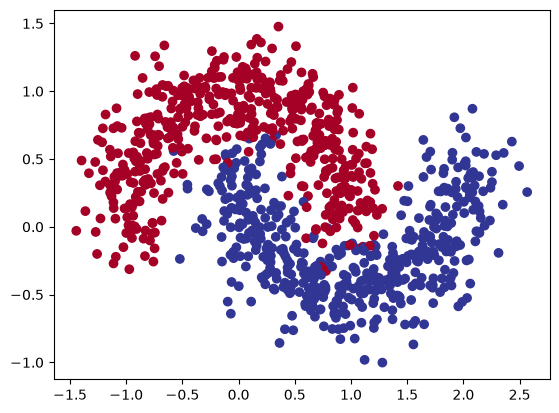

In [88]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x = X_moon[:,0],
            y = X_moon[:,1],
            c = y_moon,
            cmap = plt.cm.RdYlBu)

In [89]:
class ModelMoon(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(nn.Linear(in_features = 2, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 1))
    def forward(self, x):
        return self.rede(x)

model_ex = ModelMoon().to(device)

In [90]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model_ex.parameters(),
                             lr = 0.01)
from torchmetrics import Accuracy
torchmetric_accuracy = Accuracy(task = "binary").to(device)

In [91]:
X_moon_train = torch.from_numpy(X_moon_train).type(torch.float)
X_moon_test = torch.from_numpy(X_moon_test).type(torch.float)
y_moon_train = torch.from_numpy(y_moon_train).type(torch.float)
y_moon_test =  torch.from_numpy(y_moon_test).type(torch.float)

In [92]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
X_moon_train, y_moon_train = X_moon_train.to(device), y_moon_train.to(device)
X_moon_test, y_moon_test = X_moon_test.to(device), y_moon_test.to(device)

for epoch in range(epochs):

    model_ex.train()
    y_logits = model_ex(X_moon_train)
    y_logits = model_ex(X_moon_train).squeeze()
    loss = loss_fn(y_logits, y_moon_train)

    y_preds = torch.round(torch.sigmoid(y_logits))
    acc = torchmetric_accuracy(y_preds , y_moon_train) * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_ex.eval()
    with torch.inference_mode():

        y_test_logits = model_ex(X_moon_test).squeeze()
        y_test_preds = torch.round(torch.sigmoid(y_test_logits))
        
        test_loss = loss_fn(y_test_logits, y_moon_test)
        test_acc = torchmetric_accuracy(y_test_preds, y_moon_test) * 100
    
    if epoch % 10 == 0:
        print(f"Época: {epoch} | loss: {loss:.4f} | acc: {acc:.2f}% | loss teste: {test_loss:.4f} | acc teste: {test_acc:.2f}%")


Época: 0 | loss: 0.7031 | acc: 38.88% | loss teste: 0.6887 | acc teste: 50.00%
Época: 10 | loss: 0.5737 | acc: 82.00% | loss teste: 0.5665 | acc teste: 79.50%
Época: 20 | loss: 0.3958 | acc: 82.38% | loss teste: 0.4004 | acc teste: 79.50%
Época: 30 | loss: 0.3078 | acc: 85.38% | loss teste: 0.3115 | acc teste: 82.00%
Época: 40 | loss: 0.2720 | acc: 87.50% | loss teste: 0.2670 | acc teste: 88.00%
Época: 50 | loss: 0.2546 | acc: 88.88% | loss teste: 0.2459 | acc teste: 90.00%
Época: 60 | loss: 0.2383 | acc: 89.75% | loss teste: 0.2301 | acc teste: 90.50%
Época: 70 | loss: 0.2243 | acc: 90.62% | loss teste: 0.2150 | acc teste: 92.50%
Época: 80 | loss: 0.2093 | acc: 91.50% | loss teste: 0.1963 | acc teste: 94.00%
Época: 90 | loss: 0.1913 | acc: 92.62% | loss teste: 0.1732 | acc teste: 94.50%
Época: 100 | loss: 0.1704 | acc: 93.88% | loss teste: 0.1469 | acc teste: 95.50%
Época: 110 | loss: 0.1479 | acc: 94.75% | loss teste: 0.1214 | acc teste: 95.50%
Época: 120 | loss: 0.1260 | acc: 95.75%

In [93]:
model_ex.eval()
with torch.inference_mode():
    y_logits = model_ex(X_moon_test)
    y_preds = torch.round(torch.sigmoid(y_logits)) 

y_preds[:10], y_moon_test[:10]    

(tensor([[1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

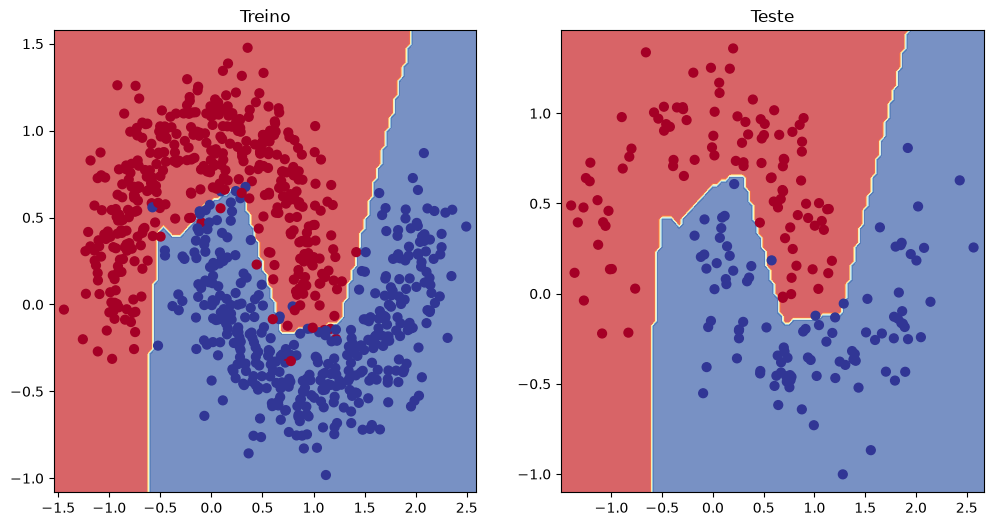

In [94]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_ex, X = X_moon_train, y = y_moon_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model = model_ex, X = X_moon_test, y = y_moon_test)

In [95]:
def Tanh(x):
    return ((torch.exp(x) - torch.exp(-x))/ ((torch.exp(x)) + torch.exp(-x))) 


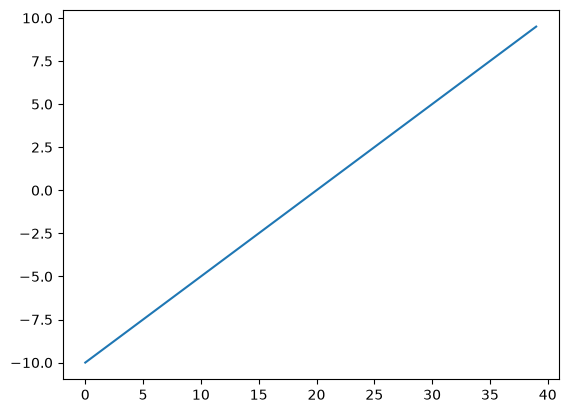

In [96]:
B = torch.arange(-10, 10, 0.5)
plt.plot(B)

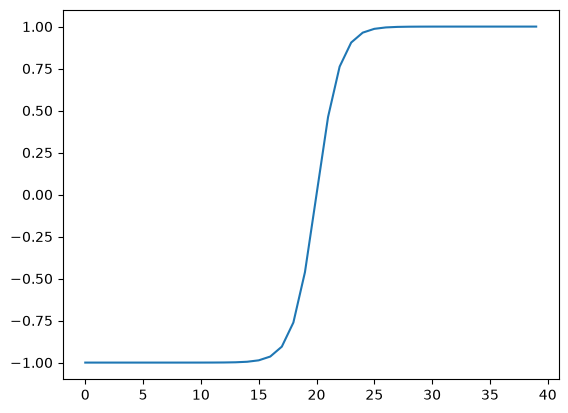

In [97]:
plt.plot(Tanh(B))

### Modelo de classificação multiclasses

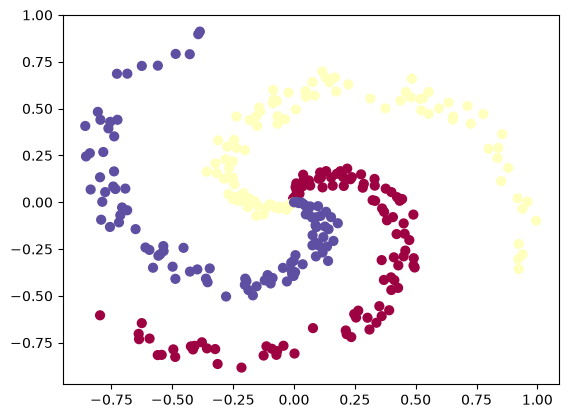

In [98]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [99]:
X = torch.from_numpy(X)
y = torch.from_numpy(y)

X = X.type(torch.float)
y = y.type(torch.LongTensor)

In [100]:
X[:3], y[:3]

(tensor([[-0.0000,  0.0000],
         [-0.0042,  0.0092],
         [-0.0034,  0.0199]]),
 tensor([0, 0, 0]))

In [101]:
class ModelMulti(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(nn.Linear(in_features = 2, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 3))
    def forward(self, x):
        return self.rede(x)

model_ex2 = ModelMulti().to(device)


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 42,
                                                    test_size = 0.2)

len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [103]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_ex2.parameters(),
                             lr = 0.005)
acc_metric = Accuracy(task = "multiclass", num_classes = 3).to(device)

In [104]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    model_ex2.train()
    y_logits = model_ex2(X_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    loss = loss_fn(y_logits, y_train)
    acc = acc_metric(y_pred, y_train) * 100
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_ex2.eval()
    with torch.inference_mode():
        y_test_logits = model_ex2(X_test)
        y_test_pred = torch.softmax(y_test_logits, dim = 1).argmax(dim = 1)
        test_loss = loss_fn(y_test_logits, y_test_pred)
        test_acc = acc_metric(y_test_pred, y_test) * 100
    if epoch % 100 == 0:
        print(f"Època: {epoch} | loss: {loss:.4f} | acc: {acc:.2f}% | Loss teste: {test_loss:.4f} | Teste acc: {test_acc:.2f}%")



Època: 0 | loss: 1.1016 | acc: 32.50% | Loss teste: 0.9849 | Teste acc: 36.67%
Època: 100 | loss: 0.5558 | acc: 68.33% | Loss teste: 0.3927 | Teste acc: 53.33%
Època: 200 | loss: 0.2002 | acc: 93.75% | Loss teste: 0.1959 | Teste acc: 96.67%
Època: 300 | loss: 0.0802 | acc: 98.75% | Loss teste: 0.0526 | Teste acc: 100.00%
Època: 400 | loss: 0.0519 | acc: 98.75% | Loss teste: 0.0260 | Teste acc: 100.00%
Època: 500 | loss: 0.0400 | acc: 99.17% | Loss teste: 0.0160 | Teste acc: 100.00%
Època: 600 | loss: 0.0335 | acc: 99.17% | Loss teste: 0.0105 | Teste acc: 100.00%
Època: 700 | loss: 0.0294 | acc: 99.17% | Loss teste: 0.0072 | Teste acc: 100.00%
Època: 800 | loss: 0.0266 | acc: 99.17% | Loss teste: 0.0051 | Teste acc: 100.00%
Època: 900 | loss: 0.0245 | acc: 99.17% | Loss teste: 0.0038 | Teste acc: 100.00%


In [105]:
model_ex2.eval()
with torch.inference_mode():
    y_logits = model_ex2(X_test)

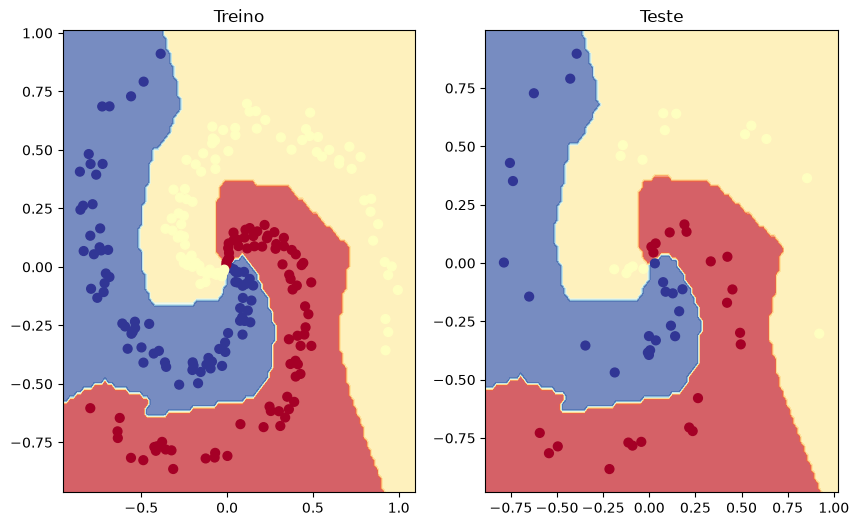

In [106]:
plt.figure(figsize = (10,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model = model_ex2, X = X_train, y = y_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model = model_ex2, X = X_test, y = y_test)

In [107]:
next(model_ex2.parameters())

Parameter containing:
tensor([[ 0.0351,  2.5086],
        [-0.0994,  0.5833],
        [-0.5928,  0.1746],
        [-0.3589,  1.8980],
        [ 1.0199, -2.1114],
        [ 0.8952,  2.1547],
        [ 3.0098,  2.2102],
        [ 1.8782, -0.8695],
        [ 3.5796,  1.7268],
        [-1.6799,  1.3655],
        [-2.9496,  2.4823],
        [-1.4675,  1.8475],
        [-2.3806,  1.6629],
        [-1.5772, -0.0115],
        [-0.4947, -2.1586]], requires_grad=True)

# 03. Visão computacional com PyTorch 

## 0. Bibliotecas de visão computacional em PyTorch

* `torchvision` - Biblioteca de domínio base para visão computacional com PyTorch
* `torchvision.datasets` - Obtenha conjuntos de dados e funções de carregamentos de dados para visão computacional
* `torchvision.models` - Obtenha modelos de visão computacional pré-treinados para voce aproveitar para o seu problema
* `torchvision.transforms` - Funções para manipulação dos seus dados de visão computacional(imagens), para que fiquem adequadas para serem usadas em um modelo de ML
* `torch.utils.data.Dataset`- Classe base  de conjuntos de dados para PyTorch
*  `torch.utils.data.DataLoader` - Cia um iterável Python em um dataset

In [1]:
# import PyTorch
import torch
from torch import nn

# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib para visualização
import matplotlib.pyplot as plt

# verificar as versões
print(torch.__version__)
print(torchvision.__version__)


KeyboardInterrupt: 

## 1. Obtendo um conjunto de dados

O conjunto de dados do torchvision.datasets que será ultilizado é: FashionMNIST 

In [ ]:
# Configurar dados de treinamento
train_data = datasets.FashionMNIST(
    root = "data", # Onde fazer o download dos dados
    train = True, # Queremos o conjunto de dados de treinamento?
    download = True, # Queremos fazer o download (sim/não)?
    transform = torchvision.transforms.ToTensor(), # Como queremos transformar os dados?
    target_transform = None # Como queremos transformar os rótulos/alvos?
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# Ver o primeiro exemplo de treinamento
image, label = train_data[0]

image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

### 1.1 Checando o formato de entrada e de saída dos dados

In [ ]:
# Checar o formato da nossa imagem
print(f"Formato da imagem: {image.shape} -> [canais de cores, altura, largura]") 
print(f" Rótulo da imagem: {class_names[label]}")

Formato da imagem: torch.Size([1, 28, 28]) -> [canais de cores, altura, largura]
 Rótulo da imagem: Ankle boot


### 1.2 Visualizando nossos dados

Formato da imagem: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

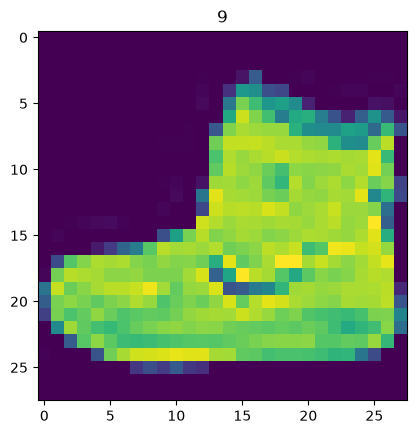

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Formato da imagem: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

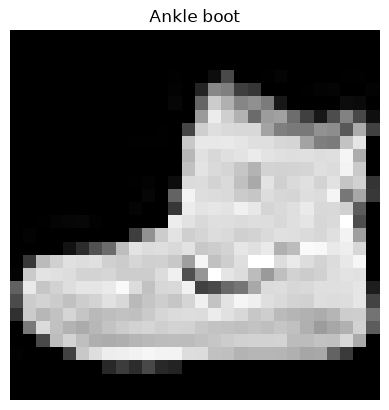

In [ ]:
plt.imshow(image.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)

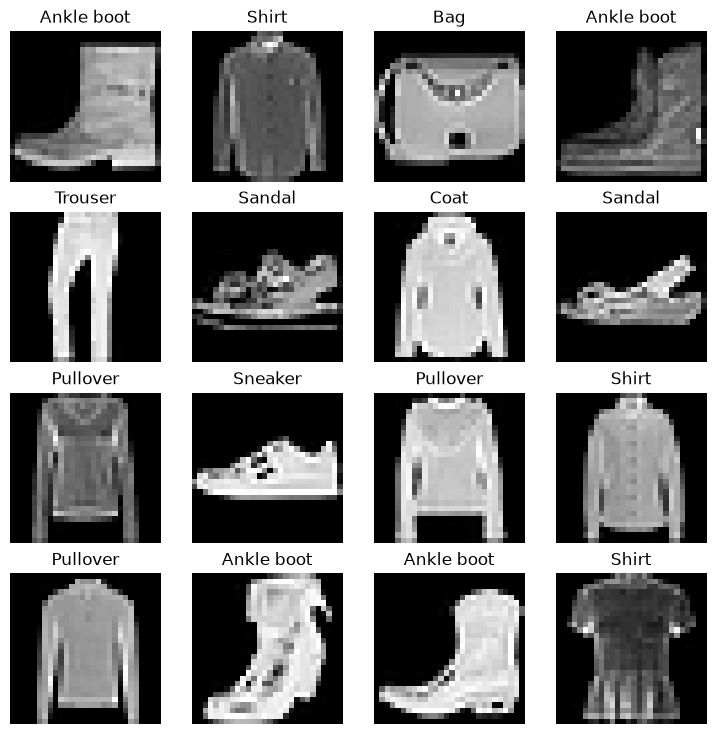

In [ ]:
# Plotar mais imagens
#torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)

Voce acha que esses itens de vestuario (imagens) podem ser modelados com linhas lineares? Ou voce acha que precisaremos de não linearidade?


In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Preparar o DataLoader(carregamento de dados)

Nossos dados estão na forma de conjunto de dados PyTorch.

DataLoader transforma nosso conjunto de dados em um iterável python.

Mais especificamente, queremos transformar nossos dados em lotes ou minilotes(batches ou mini-batches).

Por que fariamos isso?

1. É mais eficiente do ponto de vista computacional , no hardware talvez não seja possível procurar na memória 60000 imagens de uma vez só. Então nós quebramos isso em 32 imagens por vez (lote de tamanho 32).
2. Isso dá à nossa rede neural mais chances de atualizar seus gradientes por época


In [ ]:
from torch.utils.data import DataLoader

# Configure o hiperparametro tamanho do lote (batch size)
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d3230aeeab0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d3230aede80>)

In [ ]:
# Vamos checar o que criamos
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Comprimento do train_dataloader: {len(train_dataloader)} lotes de {BATCH_SIZE}...")
print(f"Comprimento do test_dataloader: {len(test_dataloader)} lotes de {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d3230aeeab0>, <torch.utils.data.dataloader.DataLoader object at 0x7d3230aede80>)
Comprimento do train_dataloader: 1875 lotes de 32...
Comprimento do test_dataloader: 313 lotes de 32...


In [ ]:
# Verificar o que está dentro do train_dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Tamanho da imagem: torch.Size([1, 28, 28])
Rótulo: 8, tamanho do rótulo: torch.Size([])


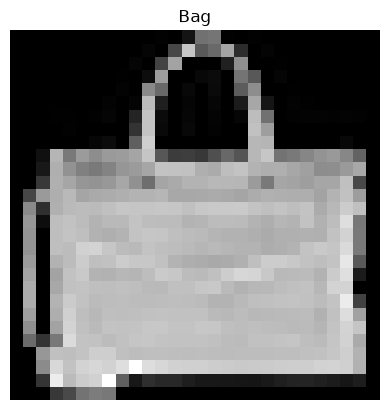

In [ ]:
# Mostrar um exemplo
#torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch), size = [1]).item()
img,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Tamanho da imagem: {img.shape}")
print(f"Rótulo: {label}, tamanho do rótulo: {label.shape}")

## 3. Modelo 0: Construir um modelo linha de base 

Ao começar a criar uma série de experimentos de modelagem de aprendizado de máquina, a melhor prática é começar com um modelo de linha de base.

Um modelo de linha de base é um modelo simples, voce tentará melhorá-lo com o modelo/experimento subsequente.

Em outras palavras: Comece de forma simples e adicione complexidade quando necessário.

In [ ]:
# Criar a flatten layer( camada achatada)
flatten_model = nn.Flatten()

# Obter uma única amostra
x = train_features_batch[0]

# Achatar a amostra
output = flatten_model(x) # executa a inferência

# Imprimir o que aconteceu
print(f"Formato antes do achatamento: {x.shape} -> [canais de cores, altura, largura]")
print(f"Formato depois do achatamento: {output.shape} -> [canais de cores, altura*largura]")

Formato antes do achatamento: torch.Size([1, 28, 28]) -> [canais de cores, altura, largura]
Formato depois do achatamento: torch.Size([1, 784]) -> [canais de cores, altura*largura]


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape,
                      out_features = hidden_units),
            nn.Linear(in_features = hidden_units,
                      out_features = output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)



In [ ]:
torch.manual_seed(42)

# Configurar o modelo com parametros de entrada
model_0 = FashionMNISTModelV0(
    input_shape = 784, # isso é 28 * 28
    hidden_units = 10, # quantas unidades na camada oculta?
    output_shape = len(class_names) # um para cada classe
    ).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Configurar o otimizador,a função de perda e as métricas de avaliação

* Função de perda - como estamos trabalhando com dados de várias classes, nossa função de perda será `nn.CrossEntropyLoss()`
* Otimizador - nosso otimizador `torch.optim.SGD()` (descida do gradiente estocástica)
* Métricas de avaliação - já que estamos trabalhando com um problema de classificação, vamos usar a acurácia como nossa métrica de avaliação


In [ ]:
import requests 
from pathlib import Path

# Baixar as helper_functions do repo Learn PyTorch
if Path("helper_functions.py").is_file():
    print("helper_functions.py já existe, pulando download...")
else:
    print("Baixando helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_functions.py já existe, pulando download...


In [ ]:
# Importar a métrica acurácia
from helper_functions import accuracy_fn

#Configurar a função de perda e o otimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

### 3.2 Criando uma função para cronometrar nossos experimentos

O aprendizado de máquina é muito experimental.

Dois dos principais aspectos que muitas vezes você desejará são:
1. Acompanhar o desempenho do seu modelo (perda e precisão)
2. Velocidade de execução 

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    """Imprime a diferença entre a hora inicial e a hora final."""
    total_time = end - start
    print(f"Tempo de treinamento em {device}: {total_time:.3f} segundos")
    return total_time


In [ ]:
start_timer = timer()
# algum código
end_timer = timer()
print_train_time(start = start_timer, end = end_timer, device = "cpu")

NameError: name 'timer' is not defined

### 3.3 Criando um loop de treinamento e treinamento de um modelo em lotes de dados

1. Percorrer as épocas.
2. Percorrer os lotes de treinamento (batches), executando as etapas de treinamento e calculando a perda do treinamento *por lote(batch)*.
3. Percorrer os loops de teste, executando as etapas de teste e calculando a perda do teste *por lote(batch)*.
4. Imprimir o que esta acontecendo.
5. Cronometrar tudo (por diversão).

In [ ]:
# Importar tqdm para a barra de progresso
from tqdm.auto import tqdm

# Definir a semente e iniciar o cronômetro
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Configurar o número de épocas (vamos manter isso em um nível pequeno para um tempo de treinamento mais rápido)
epochs = 3

# Criar um loop de treinamento e teste
for epoch in tqdm(range(epochs)):
    print(f"Época: {epoch}\n------")
    ### Treinamento 
    train_loss = 0
    # Adicionar um loop para percorrer os lotes de treinamento
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Inferência
        y_pred = model_0(X)

        # 2. Calcular a perda(por batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # acumular a perda do treino

        # 3. Zerar os gradientes do otimizador
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Passo do otimizador
        optimizer.step()

        # Imprimir o que esta acontecendo
        if batch % 400 == 0:
            print(f"Olhando para {batch * len(X)}/ {len(train_dataloader.dataset)} amostras")

    # Dividir a perda total do treino pelo comprimento do train_dataloader
    train_loss /= len(train_dataloader)

    ### Teste
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            # 1. Inferência
            test_pred = model_0(X_test)

            # 2. Calcular a perda(acumulativamente)
            test_loss += loss_fn(test_pred, y_test)

            # 3. Calcular a precisão
            test_acc += accuracy_fn(y_test, test_pred.argmax(dim = 1))

        # Calcular a média das perdas do teste por lote
        test_loss /= len(test_dataloader)

        # Calular a média das precisões por lote
        test_acc /= len(test_dataloader)

    # Imprimir o que esta acontecendo
    print(f"\n Perda do treino: {train_loss:.4f} | Perda do teste: {test_loss:.4f} | Teste acc: {test_acc:.4f}% ")

# Calcular o tempo de treinamento 
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_on_cpu,
                                            end = train_time_end_on_cpu,
                                            device = str(next(model_0.parameters()).device))



/home/lucas/.cache/pypoetry/virtualenvs/pytorch-0JguN_8h-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Época: 0
------
Olhando para 0/ 60000 amostras


Olhando para 12800/ 60000 amostras
Olhando para 25600/ 60000 amostras
Olhando para 38400/ 60000 amostras
Olhando para 51200/ 60000 amostras


 33%|███▎      | 1/3 [00:17<00:35, 18.00s/it]


 Perda do treino: 0.5904 | Perda do teste: 0.5095 | Teste acc: 82.0387% 
Época: 1
------
Olhando para 0/ 60000 amostras
Olhando para 12800/ 60000 amostras
Olhando para 25600/ 60000 amostras
Olhando para 38400/ 60000 amostras
Olhando para 51200/ 60000 amostras


 67%|██████▋   | 2/3 [00:32<00:15, 15.87s/it]


 Perda do treino: 0.4763 | Perda do teste: 0.4799 | Teste acc: 83.1969% 
Época: 2
------
Olhando para 0/ 60000 amostras
Olhando para 12800/ 60000 amostras
Olhando para 25600/ 60000 amostras
Olhando para 38400/ 60000 amostras
Olhando para 51200/ 60000 amostras


100%|██████████| 3/3 [00:46<00:00, 15.47s/it]


 Perda do treino: 0.4550 | Perda do teste: 0.4766 | Teste acc: 83.4265% 
Tempo de treinamento em cpu: 46.416 segundos


## 4. Fazer previsões e obter resultados do modelo zero

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device = device):
    """ Retornar um dicionário que contém os resultados da previsão de modelos no DataLoader."""
    loss, acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X,y in tqdm(data_loader):
            # Fazer nossos dados ficarem independentes do dispositivo
            X,y = X.to(device), y.to(device)

            # Fazer previsões
            y_pred = model(X)

            # Acumular os valores de perda e precisão por lote(batch)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y,
                               y_pred = y_pred.argmax(dim = 1))
            
        
        # Dividir a perda e a precisão para encontrar a perda e a precisão média por lote
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # Só funciona se o modelo foi criado a partir de uma classe
            "model_loss": loss.item(),
            "model_acc": acc}

# Calcular os resultados do model_0 nos dados de teste
model_0_results = eval_model(model = model_0,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)
model_0_results

100%|██████████| 313/313 [00:01<00:00, 159.68it/s]


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 5. Configurar o código agnóstico do dispositivo( para usar a GPU se tiver uma)

In [ ]:
# Configure o código agnóstico de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 6. Model 1: Construção de um modelo melhor com não linearidade

Nós aprendemos sobre o poder da não linearidade no módulo 02.

In [ ]:
# Criar um modelo com camadas não lineares e lineares
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                input_shape: int,
                hidden_units: int,
                output_shape: int):

        super().__init__()
        self.layer_stack = nn.Sequential(nn.Flatten(), # Achata as entradas em um único vetor
                                         nn.Linear(in_features = input_shape, out_features = hidden_units),
                                         nn.ReLU(),
                                         nn.Linear(in_features = hidden_units, out_features = output_shape),
                                         nn.ReLU())
    def forward(self,x: torch.Tensor):
        return self.layer_stack(x)
    


In [ ]:
# Criar uma instância do modelo 1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape = 784, # Essa é a saída da camada achatada depois do 28*28
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device) # enviar para GPU se estiver disponível
next(model_1.parameters()).device

device(type='cpu')

### 6.1 Configurar a perda, o otimizador e métricas de avaliação


In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss() # isso medirá o quanto nosso modelo está errado
optimizer = torch.optim.SGD(params = model_1.parameters(), # tenta atualizar os parametros do nosso modelo para reduzir a perda
                            lr = 0.1)

### 6.2 Funcionalizando os loops de treino e teste

Vamos criar uma função para:
* loop de treinamento - `train_step()`
* loop de teste - `test_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    """Executa a etapa de treinamento com um modelo que esta tentando aprender no dataloader."""
    train_loss, train_acc = 0,0

    # Colocar o modelo em modo de treinamento
    model.train()

    # Adicionar um loop para percorrer os lotes de treinamento
    for batch, (X,y) in enumerate(data_loader):
        # Colocar os dados no dispositivo de destino
        X, y = X.to(device), y.to(device)
        # 1. Inferência (retorna os logits do modelo, tem que usar o argmax quando for avaliar)
        y_pred = model(X)

        # 2. Calcular a perda e a precisão(por batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # acumular a perda do treino
        train_acc += accuracy_fn(y_true = y,
                                 y_pred = y_pred.argmax(dim = 1)) # vai de logits -> rótulos de previsão

        # 3. Zerar os gradientes do otimizador
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Passo do otimizador
        optimizer.step()

    # Dividir a perda total do treino e a precisão pelo comprimento do train_dataloader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f" Perda no treino: {train_loss:.5f} | Precisão treino: {train_acc:.2f}%")

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    """Executa uma etapa de loop de teste no modelo que passa pelo dataloader."""
    test_loss, test_acc = 0,0
    # Colocar o modelo em modo de avaliação
    model.eval()
    # Ativar o modo de inferência
    with torch.inference_mode():
        for X,y in data_loader:
            # Enviar os dados para o dispositivo de destino
            X, y = X.to(device), y.to(device)

            # 1. Inferência (retorna logits brutos, tem que converter em rotulos de previsão para avaliar o modelo)
            test_pred = model(X)

            # 2. Calcular a perda e a precisão
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y,
                                    y_pred = test_pred.argmax(dim = 1)) # vamos de logits -> rótulos de previsão
        # Ajustar as métricas e imprimir
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Perda do teste: {test_loss:.5f} | Precisão do teste: {test_acc:.2f}%\n")

In [ ]:
torch.manual_seed(42)

# Medir o tempo 
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

# Configurar as épocas
epochs = 3

# Criar um loop de otimização e avaliação usando train_step() e test_step()
for epoch in tqdm(range(epochs)):
    print(f"Época: {epoch}\n--------")
    train_step(model = model_1,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)
    test_step(model = model_1,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
              device = device)

 
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start = train_time_start_on_gpu ,
                                            end =  train_time_end_on_gpu, 
                                            device = device)


  0%|          | 0/3 [00:00<?, ?it/s]

Época: 0
--------
 Perda no treino: 1.09199 | Precisão treino: 61.34%


 33%|███▎      | 1/3 [00:15<00:30, 15.05s/it]

Perda do teste: 0.95636 | Precisão do teste: 65.00%

Época: 1
--------
 Perda no treino: 0.78101 | Precisão treino: 71.93%


 67%|██████▋   | 2/3 [00:30<00:15, 15.01s/it]

Perda do teste: 0.72227 | Precisão do teste: 73.91%

Época: 2
--------
 Perda no treino: 0.67027 | Precisão treino: 75.94%


100%|██████████| 3/3 [00:43<00:00, 14.61s/it]

Perda do teste: 0.68500 | Precisão do teste: 75.02%

Tempo de treinamento em cpu: 43.851 segundos


> **Nota: ás vezes dependendo dos seus dados/hardware, voce pode descobrir que o modelo treina mais rápido na CPU do que na GPU**
>
> Por que isso acontece?
>
> 1. Pode ser que o overhead para copiar os dados/modelos da e para a GPU supere os beneficios computacionais oferecidos por ela
> 2. O hardware que você esta usando tem uma melhor CPU em termos de capacidade de computação em seguida a GPU.

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
total_train_time_model_0

46.415551929

In [ ]:
# Obter o dicionário de resultados do model_1
model_1_results = eval_model(model = model_1,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn,
                             device = device)
model_1_results



100%|██████████| 313/313 [00:01<00:00, 178.07it/s]


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

## Model 2: Criar uma rede neural convolucional(CNN)

CNN's são conhecidas como ConvNets

CNN's são conhecidas por suas capacidades para encontrar padões em dados visuais

In [ ]:
# Criar uma rede neural convolucional
class FashionMNISTModelV2(nn.Module):
    """Arquitetura do modelo que replica o TinyVGG modelo do site CNN Explainer."""
    def __init__(self, input_shape: int, hidden_units:int, output_shape: int):
        super().__init__()
        self.conv_block_1 =  nn.Sequential(
            # Criar uma conv layer
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),  # valores que nós podemos configurar em nossas redes neurais são chamados de hiperparâmetros
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, 
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)

        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),  # valores que nós podemos configurar em nossas redes neurais são chamados de hiperparâmetros
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, 
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 7 * 7, # Isso é um truque para calcular isso
                      out_features = output_shape,
                      )

        )

    def forward(self,x):
        x = self.conv_block_1(x)
        #print(f"Formato de saída de conv_block_1: {x.shape}")
        x = self.conv_block_2(x)
        #print(f"Formato de saída de conv_block_2: {x.shape}")
        x = self.classifier(x)
        #print(f"Formato de saída do classificador: {x.shape}")
        return x

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)

In [ ]:
rand_image_tensor = torch.randn(size = (1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
# Passar a imagem pelo modelo
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

In [ ]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

### 7.1 Passando por `nn.Conv2D()`


In [ ]:
torch.manual_seed(42)

# Criar um lote de imagens
images = torch.randn(size = (32,3,64,64))
test_image = images[0]

print(f" Formato do lote da imagem: {images.shape}")
print(f"Formato da imagem unica: {test_image.shape}")
print(f"Imagem de teste:\n {test_image}")

 Formato do lote da imagem: torch.Size([32, 3, 64, 64])
Formato da imagem unica: torch.Size([3, 64, 64])
Imagem de teste:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.85

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
torch.manual_seed(42)
# Criar uma uníca camada Conv2D
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size = 3,
                       stride = 1,
                       padding = 1)

# Passar os dados pela camada convolucional
conv_output = conv_layer(test_image.unsqueeze(dim = 0))
conv_output.shape

torch.Size([1, 10, 64, 64])

### 7.2 Passando por `nn.MaxPool2d()`

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# Vamos imprimir a forma da imagem original sem uma dimensão a mais(unsqueeze)
print(f"Forma original da imagem de teste: {test_image.shape}")
print(f"Imagem de teste com uma dimensão a mais: {test_image.unsqueeze(dim = 0).shape}")

# Criar uma amostra de uma camada nn.MaxPool2d
max_pool_layer = nn.MaxPool2d(kernel_size = 2)

# Passar os dados apenas pela camada convolucional
test_image_through_conv = conv_layer(test_image.unsqueeze(dim = 0))
print(f"Formato depois de passar por uma conv_layer(): {test_image_through_conv.shape}")

# Passar os dados por meio da camada max pool
test_image_through_conv_and_maxpool = max_pool_layer(test_image_through_conv)
print(f" Formato depois de passar pela conv_layer e pela max_pool_layer: {test_image_through_conv_and_maxpool.shape}")

Forma original da imagem de teste: torch.Size([3, 64, 64])
Imagem de teste com uma dimensão a mais: torch.Size([1, 3, 64, 64])
Formato depois de passar por uma conv_layer(): torch.Size([1, 10, 64, 64])
 Formato depois de passar pela conv_layer e pela max_pool_layer: torch.Size([1, 10, 32, 32])


In [ ]:
torch.manual_seed(42)
# Criar um tensor aleatório com um número semelhante de dimensões para nossas imagens
random_tensor = torch.randn(size =(1,1,2,2))
print(f"\n Tensor aleatorio:\n {random_tensor} ")
print(f"Formato do tensro aleatorio: {random_tensor.shape}")

#Criar uma camada max pool
max_pool_layer = nn.MaxPool2d(kernel_size = 2)

# Passar o tensor aleatório por meio da camada max pool
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\n Tensor max pool:\n {max_pool_tensor}")
print(f"Formato do tensor max pool: {max_pool_tensor.shape}")




 Tensor aleatorio:
 tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]]) 
Formato do tensro aleatorio: torch.Size([1, 1, 2, 2])

 Tensor max pool:
 tensor([[[[0.3367]]]])
Formato do tensor max pool: torch.Size([1, 1, 1, 1])


### 7.3 Configurar uma função de perda e um otimizador para o `model_2`

In [ ]:
# Configurar a função de perda/métricas de avaliação/otimizador
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.1)

### 7.4 Treinando e testando o `model_2` usando nossas funções de treinamento e teste

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Medir o tempo
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Treinar e testar o modelo
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Época: {epoch}\n-----------")
    train_step(model = model_2,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)
    test_step(model = model_2,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
              device = device)
    
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start = train_time_start_model_2, 
                                            end = train_time_end_model_2,
                                            device = device)


    

  0%|          | 0/3 [00:00<?, ?it/s]

Época: 0
-----------
 Perda no treino: 0.59203 | Precisão treino: 78.52%


 33%|███▎      | 1/3 [00:45<01:30, 45.42s/it]

Perda do teste: 0.39263 | Precisão do teste: 85.91%

Época: 1
-----------
 Perda no treino: 0.36232 | Precisão treino: 87.04%


 67%|██████▋   | 2/3 [01:28<00:44, 44.14s/it]

Perda do teste: 0.34975 | Precisão do teste: 87.33%

Época: 2
-----------
 Perda no treino: 0.32416 | Precisão treino: 88.25%


100%|██████████| 3/3 [02:12<00:00, 44.06s/it]

Perda do teste: 0.32896 | Precisão do teste: 88.13%

Tempo de treinamento em cpu: 132.176 segundos


In [ ]:
# Obter o dicionario de resultados do model_2
model_2_results = eval_model(model = model_2,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn,
                             device = device)

model_2_results


100%|██████████| 313/313 [00:03<00:00, 89.64it/s]


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32895955443382263,
 'model_acc': 88.12899361022365}

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

## 8. Comparação de resultados dos modelos e o tempo de treinamento

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.328960,88.128994


In [ ]:
# Adicionaremos o tempo de treinamento na comparação de resultados
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,46.415552
1,FashionMNISTModelV1,0.685001,75.019968,43.850609
2,FashionMNISTModelV2,0.328960,88.128994,132.175740


Text(0, 0.5, 'model')

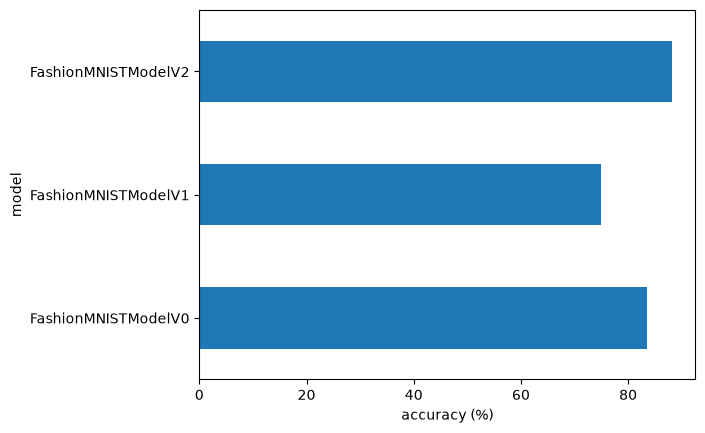

In [ ]:
# Visualizar os resultados do nosso modelo
compare_results.set_index("model_name")["model_acc"].plot(kind = "barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")


## 9. Fazer e avaliar previsões aleatórias com o melhor modelo

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Preparar a amostra (adicionar uma dimensão de lote e passar para o dispositivo alvo)
            sample = torch.unsqueeze(sample, dim = 0).to(device)

            # Inferência( saida do modelo são logit brutos)
            pred_logit = model(sample)

            # Obter a probabilidade de previsão(logit -> probabilidade de previsão)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)

            # Tirar o pred_prob da GPU para cálculos adicionais
            pred_probs.append(pred_prob.cpu())
    # Empilhar pred_probs para tyransformar uma lista em um tensor
    return torch.stack(pred_probs)


In [ ]:
import random
#random.seed(42)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data), k = 9):
    test_samples.append(sample)
    test_labels.append(label)

# Visualizar o formato da primeira amostra
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Dress')

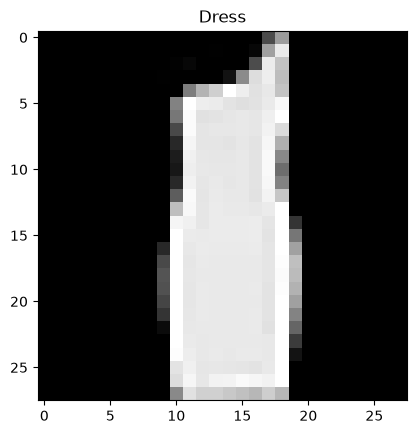

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]])

In [ ]:
# Fazer previsões 
pred_probs = make_predictions(model = model_2,
                              data = test_samples)

# Ver a lista das duas primeiras probabilidades de previsão
pred_probs[:2]

tensor([[2.6524e-03, 7.8964e-04, 6.5885e-05, 9.9619e-01, 1.1649e-05, 2.8577e-06,
         1.3050e-04, 6.4404e-05, 6.8477e-05, 2.8650e-05],
        [2.3767e-02, 1.6647e-02, 8.5696e-03, 9.1813e-01, 2.5856e-02, 5.0575e-05,
         8.5000e-04, 2.2943e-03, 3.5770e-03, 2.6260e-04]])

In [ ]:
# Converter probabilidades de previsão em rótulos
pred_classes = pred_probs.argmax(dim = 1)
pred_classes

tensor([3, 3, 9, 6, 5, 7, 1, 6, 4])

In [ ]:
test_labels

[3, 3, 9, 6, 5, 7, 1, 0, 4]

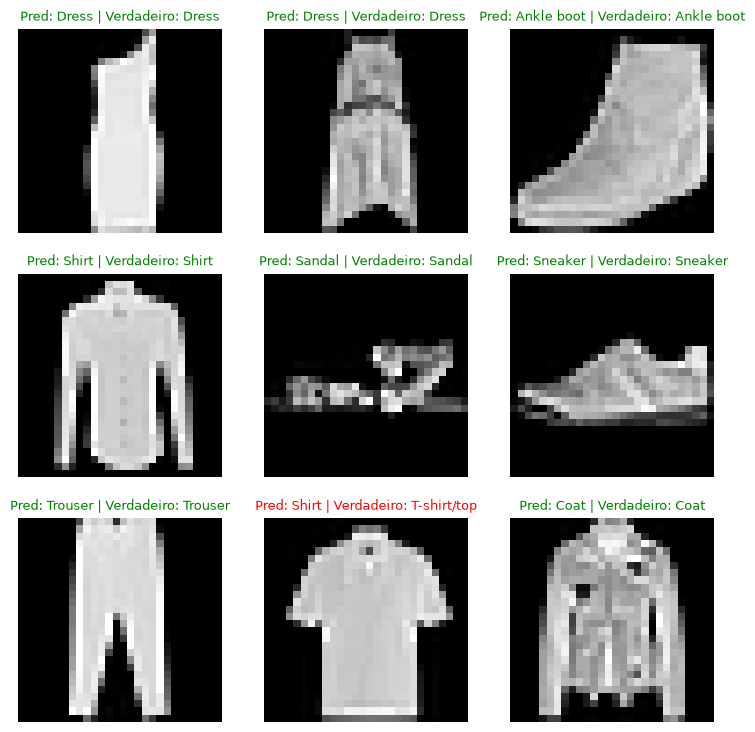

In [ ]:
# Plotar previsões
plt.figure(figsize = (9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Criar um subplot para cada amostra
    plt.subplot(nrows, ncols, i+1)

    # Plotar a imagem de destino
    plt.imshow(sample.squeeze(), cmap = "gray")

    # Encontrar o rótulo de previsão( em formato de texto)
    pred_label = class_names[pred_classes[i]]

    # Obter o rótulo verdadeiro(formato de texto)
    truth_label = class_names[test_labels[i]]

    # Criar um título para o plot
    title_text = f"Pred: {pred_label} | Verdadeiro: {truth_label}"

    # Checar se há uma igualdade entre pred e truth e mudar a cor do texto
    if pred_label == truth_label:
        plt.title(title_text, fontsize = 9, c = "g") # texto verde se a previsão for a mesma que truth
    else:
        plt.title(title_text, fontsize = 9, c = "r")
    plt.axis(False)

## 10. Criar uma matriz de confusão para avaliação adicional da previsão

Uma matriz de confusão é uma maneira fantástica de avalisar visualmente nossos modelos de classificação

1. Fazer previsões com nosso modelo treinado no dataset de teste
2. Criar uma matriz de confusão `torchmetrics.ConfusionMatrix()`
3. Plotar a matriz de confusão usando `mlxtend.plotting.plot_confusion_matrix()`


In [ ]:
# IMportar tqdm.auto
from tqdm.auto import tqdm


# 1. Fazer previsões com nosso modelo treinado
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc = "Fazendo previsões..."):
        # Enviar os dados e os alvos para o dispositivo alvo
        X, y = X.to(device), y.to(device)
        # Inferência
        y_logit = model_2(X)
        # Transformar as previsões de logits -> previsões de probabilidade -> rótulos de previsão
        y_pred = torch.softmax(y_logit.squeeze(), dim = 0).argmax(dim = 1)
        # Colocar as previsões na CPU para avaliação
        y_preds.append(y_pred.cpu())

# Usar a lista concatenada de previsões em um tensor
#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Fazendo previsões...: 100%|██████████| 313/313 [00:04<00:00, 72.23it/s]


tensor([9, 2, 1,  ..., 8, 1, 8])

In [ ]:
len(y_pred_tensor)

10000

In [ ]:
import mlxtend
import torchmetrics
mlxtend.__version__

'0.25.0'

In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
y_pred_tensor[:10]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
test_data.targets

tensor([9, 2, 1,  ..., 8, 1, 5])

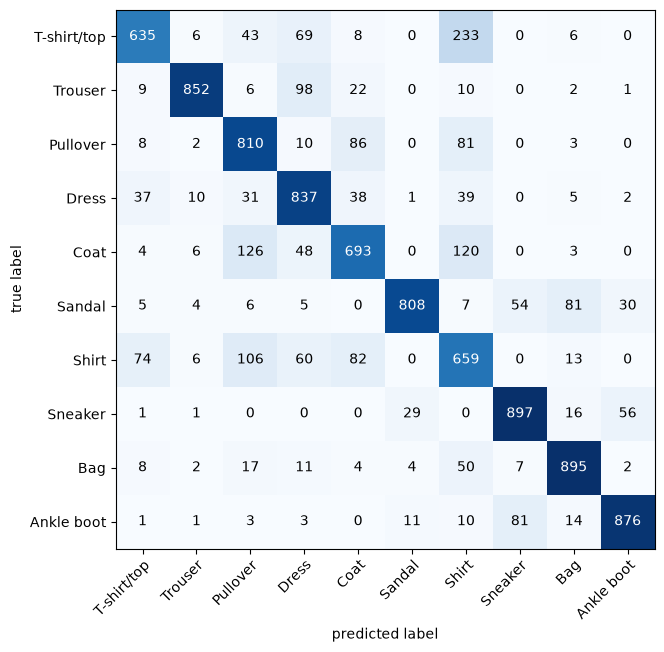

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Configurar a instância da matriz de confusão e comparar as previsões com o alvo
confmat = ConfusionMatrix(task = "multiclass" , num_classes = len(class_names))
confmat_tensor = confmat(preds = y_pred_tensor,
                         target = test_data.targets)
                         
# 3. Plotar nossa matriz de confusão
fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(), # matplotlib gosta de trabalhar com numpy
    class_names = class_names,
    figsize = (10,7)
)

## 11. Salvar e carregar o modelo de melhor desempenho

In [ ]:
from pathlib import Path

# Criar o caminho do diretorio do modelo
MODEL_PATH = Path('modelos')
MODEL_PATH.mkdir(parents = True,
                 exist_ok = True)
# Criar um caminho para salvar o modelo
MODEL_NAME = '03_Pytorch_computer_vision_model_2.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Salvar o dicionario estatico do modelo
print(f'Salvando o modelo em: {MODEL_SAVE_PATH}')
torch.save(obj = model_2.state_dict(),
           f = MODEL_SAVE_PATH)


Salvando o modelo em: modelos/03_Pytorch_computer_vision_model_2.pth


In [ ]:
# Criar uma nova instancia 
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape = 1,
                                     hidden_units = 10,
                                     output_shape = len(class_names))

# Carregar o dicionario estatico salvo
loaded_model_2.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

# Enviar o modelo para o dispositivo de destino
loaded_model_2.to(device)


FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32895955443382263,
 'model_acc': 88.12899361022365}

In [ ]:
# Avaliar o modelo carregado
torch.manual_seed(42)
loaded_model_2_results = eval_model(
    model = loaded_model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
    )
loaded_model_2_results

100%|██████████| 313/313 [00:07<00:00, 42.81it/s]


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32895955443382263,
 'model_acc': 88.12899361022365}

In [ ]:
# Checar se os resultados do modelo carregado estao proximos uns dos outros
torch.isclose(torch.tensor(model_2_results['model_loss']),
              torch.tensor(loaded_model_2_results['model_loss']),
              atol = 1e-08)

tensor(True)

## Exercicios

In [ ]:
train_data = torchvision.datasets.MNIST(root = 'data',
                                        train = True,
                                        transform = ToTensor(),
                                        target_transform = None,
                                        download = True)

test_data = torchvision.datasets.MNIST(root = 'data',
                                       train = False,
                                       transform = ToTensor(),
                                       target_transform = None,
                                       download = True)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

Text(0.5, 1.0, '9')

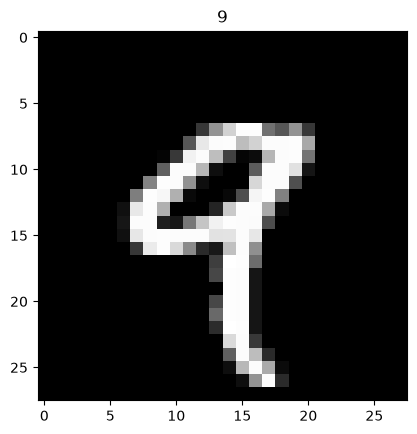

In [ ]:
image, label = train_data[4]
plt.imshow(image.squeeze(dim = 0), cmap = 'gray')
plt.title(label)

In [ ]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [ ]:
train_dataloader = torch.utils.data.DataLoader(dataset = train_data,
                                               batch_size = 32,
                                               shuffle = True)

test_dataloader = torch.utils.data.DataLoader(dataset = test_data,
                                              batch_size = 32,
                                              shuffle = True)

In [ ]:
class FASHIONMNISTMODELV3(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      padding = 1,
                      stride = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      padding = 1,
                      stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2))
        self.conv_block_2 = nn.Sequential(nn.Conv2d(in_channels = hidden_units,
                                          out_channels = hidden_units,
                                          kernel_size = 3,
                                          padding = 1,
                                          stride = 1),
                            nn.ReLU(),
                            nn.Conv2d(in_channels = hidden_units,
                                      out_channels = hidden_units,
                                      kernel_size = 3,
                                      padding = 1,
                                      stride = 1),
                            nn.ReLU(),
                            nn.MaxPool2d(kernel_size = 2))
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(in_features = hidden_units * 7 * 7 ,
                                                  out_features = output_shape))
        
    def forward(self,x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
                                

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_ex = FASHIONMNISTMODELV3(input_shape = 1,
                               hidden_units = 10,
                               output_shape = len(class_names))

In [ ]:
optimizer = torch.optim.SGD(params = model_ex.parameters(),
                            lr = 0.1)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer


train_time_start = timer()

epochs = 3


for epoch in tqdm(range(epochs)):
    print(f"Época: {epoch}\n-----")
    train_step(model = model_ex,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn= accuracy_fn,
               device = device)
    test_step(model = model_ex,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
               device = device)
    
train_time_end = timer()
total_train_time = print_train_time(start = train_time_start,
                                    end = train_time_end,
                                    device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Época: 0
-----
 Perda no treino: 0.26621 | Precisão treino: 91.31%


 33%|███▎      | 1/3 [00:44<01:29, 45.00s/it]

Perda do teste: 0.07977 | Precisão do teste: 97.41%

Época: 1
-----
 Perda no treino: 0.07018 | Precisão treino: 97.80%


 67%|██████▋   | 2/3 [01:33<00:46, 46.77s/it]

Perda do teste: 0.04154 | Precisão do teste: 98.54%

Época: 2
-----
 Perda no treino: 0.05307 | Precisão treino: 98.36%


100%|██████████| 3/3 [02:25<00:00, 48.35s/it]

Perda do teste: 0.04680 | Precisão do teste: 98.46%

Tempo de treinamento em cpu: 145.052 segundos


In [ ]:
import random
#random.seed(42)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data), k = 9):
    test_samples.append(sample)
    test_labels.append(label)

# Visualizar o formato da primeira amostra
test_samples[0].shape

torch.Size([1, 28, 28])

In [ ]:
pred_probs = make_predictions(model = model_ex,
                 data = test_samples)

In [ ]:
pred_classes = pred_probs.argmax(dim = 1)
pred_classes

tensor([0, 2, 7, 7, 9, 6, 0, 5, 9])

In [ ]:
test_labels

[0, 2, 7, 7, 9, 6, 0, 5, 9]

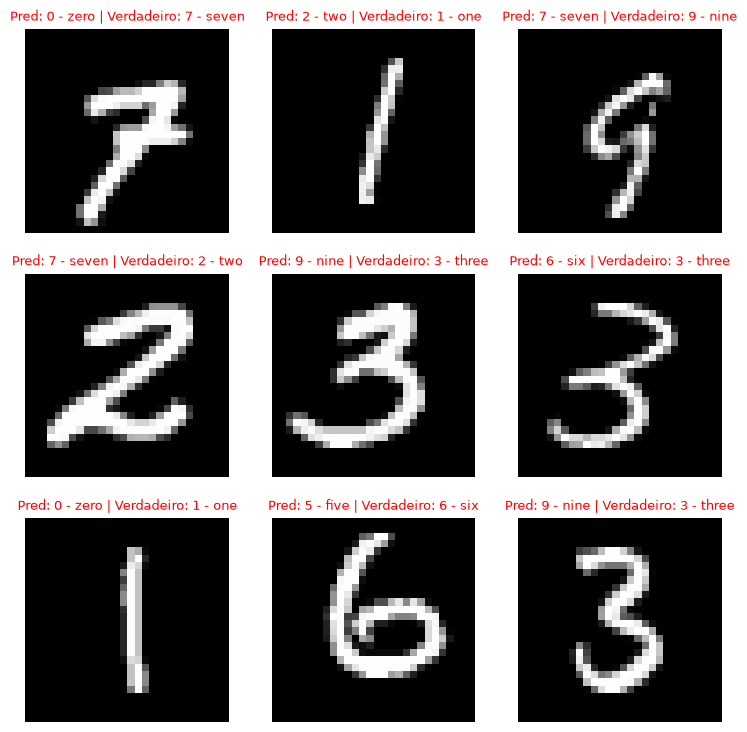

In [ ]:
# Plotar previsões
plt.figure(figsize = (9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Criar um subplot para cada amostra
    plt.subplot(nrows, ncols, i+1)

    # Plotar a imagem de destino
    plt.imshow(sample.squeeze(), cmap = "gray")

    # Encontrar o rótulo de previsão(em formato de texto)
    pred_label = class_names[pred_classes[i]]

    # Obter o rótulo verdadeiro(formato de texto)
    truth_label = class_names[test_labels[i]]

    # Criar um título para o plot
    title_text = f"Pred: {pred_label} | Verdadeiro: {truth_label}"

    # Checar se há uma igualdade entre pred e truth e mudar a cor do texto
    if pred_label == truth_label:
        plt.title(title_text, fontsize = 9, c = "g") # texto verde se a previsão for a mesma que truth
    else:
        plt.title(title_text, fontsize = 9, c = "r") # texto vermelho se a previsão for diferente
    plt.axis(False)

In [ ]:

from tqdm.auto import tqdm

y_preds = []
model_ex.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc = "Fazendo previsões..."):
        X, y = X.to(device), y.to(device)
        y_logit = model_ex(X)
        y_pred = torch.softmax(y_logit.squeeze(), dim = 0).argmax(dim = 1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Fazendo previsões...: 100%|██████████| 313/313 [00:01<00:00, 191.50it/s]


tensor([0, 8, 6,  ..., 0, 8, 1])

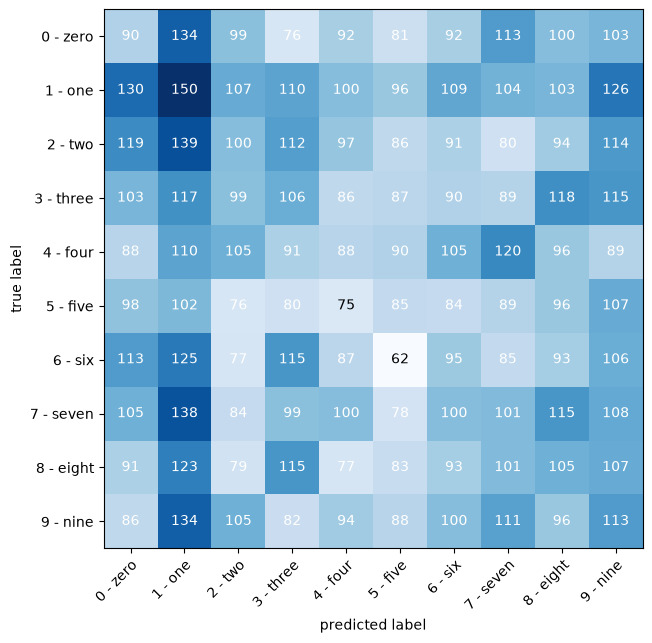

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Configurar a instância da matriz de confusão e comparar as previsões com o alvo
confmat = ConfusionMatrix(task = "multiclass" , num_classes = len(class_names))
confmat_tensor = confmat(preds = y_pred_tensor,
                         target = test_data.targets)
                         
# 3. Plotar nossa matriz de confusão
fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(), # matplotlib gosta de trabalhar com numpy
    class_names = class_names,
    figsize = (10,7)
)

In [ ]:
random_tensor = torch.rand(size = [1,3,64,64])

conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 17,
                       kernel_size = 7,
                       stride = 5,
                       padding = 4)

random_tensor.shape


torch.Size([1, 3, 64, 64])

In [ ]:
output_tensor = conv_layer(random_tensor)
output_tensor.shape

torch.Size([1, 17, 14, 14])

# 04. Customizando conjuntos de dados com Pytorch

## 0. Importando Pytorch e configuraçao do codigo independente de dispositivo

In [1]:
import torch
from torch import nn

# Precisamos de pelo menos Pytorch 1.10.0
torch.__version__

'2.12.1+cu130'

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device 

'cpu'

## 1. Obter dados

Nosso conjunto de dados e um subconjunto do conjunto de dados Food101.

Food101 tem 101 classes diferentes de alimentos e 1000 imagens por classe( 750 treino e 250 teste).

Nosso dataset tem 3 classes de alimentos e apenas 10% das imagens( ~75 treinamento, ~25 teste).

Por que fazer isso?

Quando se esta começando com projetos de machine learning e importante tentar as coisas em pequena escala e depois aumentar a escala quando necessario.

O objetivo e acelerar a velocidade dos experimentos.

In [3]:
import requests
import zipfile
from pathlib import Path

# Configurar um caminho para uma pasta de dados
data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi'

# Sea pasta e imagens nao existir, baixaremos e prepararemos ela
if image_path.is_dir():
    print(f'{image_path} diretorio ja existe... pulando download')
else:
    print(f'{image_path} nao existe, criando um...')
    image_path.mkdir(parents = True,
                     exist_ok = True)

# Baixar os dados de pizza, bife e sushi
with open(data_path/ 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print(f' Baixando dados de pizza, crane e sushi')
    f.write(request.content)

# descompactar os dados de pizza, carne e sushi
with zipfile.ZipFile(data_path/ 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print(f' Descompactando dados de pizza, carne e sushi...')
    zip_ref.extractall(image_path)


data/pizza_steak_sushi diretorio ja existe... pulando download
 Baixando dados de pizza, crane e sushi
 Descompactando dados de pizza, carne e sushi...


## 2. Tornar-se um com os dados (preparaçao e exploraçao dos dados)

In [4]:
import os
def walk_through_dir(dir_path):
    ''' Funçao auxiliar que percorre dir_path e retorna o seu conteudo'''
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'Temos {len(dirnames)} diretorios e {len(filenames)} imagens em {dirpath}')

In [5]:
walk_through_dir(image_path)

Temos 2 diretorios e 0 imagens em data/pizza_steak_sushi
Temos 3 diretorios e 0 imagens em data/pizza_steak_sushi/test
Temos 0 diretorios e 25 imagens em data/pizza_steak_sushi/test/pizza
Temos 0 diretorios e 19 imagens em data/pizza_steak_sushi/test/steak
Temos 0 diretorios e 31 imagens em data/pizza_steak_sushi/test/sushi
Temos 3 diretorios e 0 imagens em data/pizza_steak_sushi/train
Temos 0 diretorios e 78 imagens em data/pizza_steak_sushi/train/pizza
Temos 0 diretorios e 75 imagens em data/pizza_steak_sushi/train/steak
Temos 0 diretorios e 72 imagens em data/pizza_steak_sushi/train/sushi


In [6]:
# Configurar nossos caminhos de treinamento e teste
train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizando uma imagem

Vamos escrever um codigo para:
1. Obter todos os caminhos de imagem
2. Escolher um caminho de imagem aleatorio usando random.choice() do Python
3. Obter o nome da classe da imagem usando `pathlib.Path.parent.stem`
4. Como estamos trabalhando com imagens, vamos abrir a imagem com o PIL do python
5. Mostrar a imagem e imprimir alguns metadados

Caminho da imagem aleatoria: data/pizza_steak_sushi/train/steak/2324994.jpg
 Classe da imagem: steak
 Altura da imagem: 384
 Largura da imagem: 512


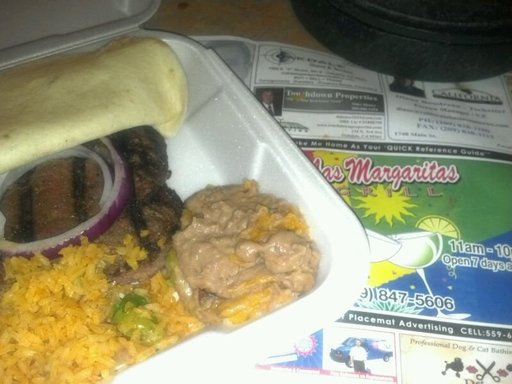

In [7]:
import random
from PIL import Image

# Configurar a semente
#random.seed(42)

# 1. Obter todos os caminhos de imagem
image_path_list = list(image_path.glob('*/*/*.jpg'))

# 2. Escolher um caminho de uma imagem aleatoria 
random_image_path = random.choice(image_path_list)

# 3. Obter a classe da imagem a partir do nome do caminho( a classe da imagem é o nome do diretorio onde a imagem esta armazenada)
image_class = random_image_path.parent.stem

# 4. Abrir a imagem
img = Image.open(random_image_path)

# 5. Imprimir metadados
print(f'Caminho da imagem aleatoria: {random_image_path}')
print(f' Classe da imagem: {image_class}')
print(f' Altura da imagem: {img.height}')
print(f' Largura da imagem: {img.width}')
img

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

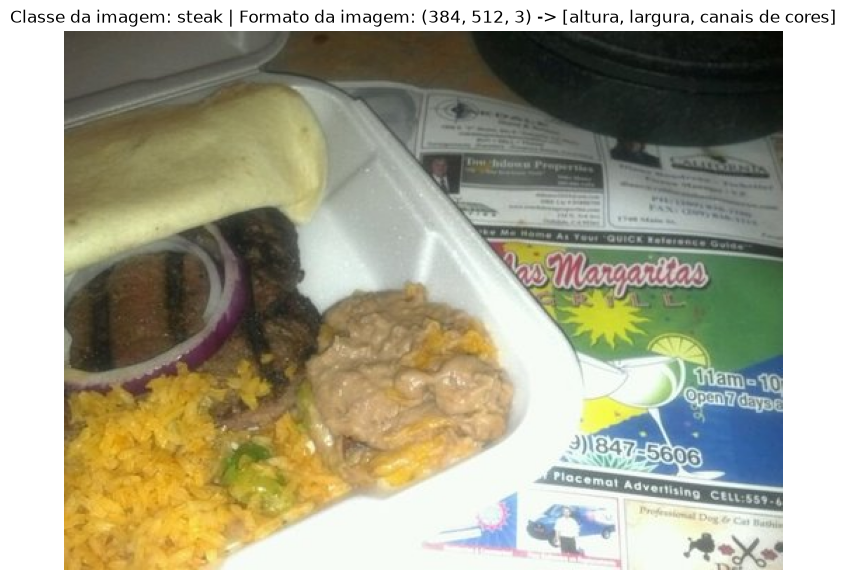

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Transformar a imagem em um array
img_as_array = np.asarray(img)

# Plotar a unagem com matplotlib
plt.figure(figsize = (10,7))
plt.imshow(img_as_array)
plt.title(f'Classe da imagem: {image_class} | Formato da imagem: {img_as_array.shape} -> [altura, largura, canais de cores]')
plt.axis(False)

In [9]:
img_as_array

array([[[ 72,  68,  59],
        [ 70,  66,  57],
        [ 69,  65,  56],
        ...,
        [  6,   8,   3],
        [  6,   7,   2],
        [  5,   6,   1]],

       [[ 72,  68,  59],
        [ 70,  66,  57],
        [ 69,  65,  56],
        ...,
        [  7,   9,   4],
        [  8,   9,   4],
        [  7,   8,   3]],

       [[ 71,  67,  58],
        [ 71,  67,  58],
        [ 70,  66,  57],
        ...,
        [  8,  10,   5],
        [  9,  10,   5],
        [  9,  10,   5]],

       ...,

       [[200, 151,  46],
        [201, 152,  47],
        [196, 147,  42],
        ...,
        [213, 210, 191],
        [211, 206, 187],
        [210, 207, 188]],

       [[199, 151,  43],
        [200, 152,  44],
        [192, 144,  36],
        ...,
        [214, 209, 189],
        [215, 208, 189],
        [212, 207, 187]],

       [[201, 153,  45],
        [203, 155,  47],
        [192, 144,  36],
        ...,
        [214, 208, 186],
        [214, 207, 188],
        [208, 201, 182]]

## 3. Transformando dados

Antes de podermos usar nossos dados de imagem com o Pytorch:
1. Transformar os dados de destino em tensores( nos nosso caso, uma representaçao numerica das nossas imagens)
2. Transforma-los em um `torch.utuls.data.Dataset` e posteriormente transformar em `torch.utils.data.DataLoader`, chamaremos esses de  `Dataset` e `DataLoader`.

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transformando dados com torchvision.transforms

Transforms pode ajudar a preparar as imagens para serem usadas com um modelo/realizar o data augmentation - https://pytorch.org/vision/stable/transforms.html

In [11]:
# Escrever a transformaçao de uma imagem
data_transform = transforms.Compose([
    # Redimensionar nossas imagens para 64x64
    transforms.Resize(size = (64,64)),
    # Inverter as imagens aleatoriamente na horizontal
    transforms.RandomHorizontalFlip(p = 0.5),
    # Transformar a imagem em um tensor Pytorch
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.0275, 0.0353, 0.0471,  ..., 0.3020, 0.2941, 0.2824],
         [0.0353, 0.0353, 0.0431,  ..., 0.3098, 0.3059, 0.2980],
         [0.0353, 0.0275, 0.0353,  ..., 0.3216, 0.3137, 0.3098],
         ...,
         [0.6118, 0.7765, 0.7216,  ..., 0.8157, 0.8039, 0.7961],
         [0.7176, 0.6824, 0.7373,  ..., 0.8078, 0.8157, 0.8078],
         [0.8314, 0.7569, 0.8235,  ..., 0.7882, 0.7961, 0.8235]],

        [[0.0353, 0.0510, 0.0588,  ..., 0.2863, 0.2784, 0.2667],
         [0.0431, 0.0471, 0.0588,  ..., 0.2980, 0.2902, 0.2824],
         [0.0431, 0.0471, 0.0549,  ..., 0.3137, 0.3020, 0.2941],
         ...,
         [0.6039, 0.7569, 0.7333,  ..., 0.6039, 0.5961, 0.6039],
         [0.6863, 0.6471, 0.7451,  ..., 0.5961, 0.6157, 0.6118],
         [0.8196, 0.7569, 0.8353,  ..., 0.5765, 0.6039, 0.6314]],

        [[0.0157, 0.0275, 0.0353,  ..., 0.2431, 0.2353, 0.2314],
         [0.0235, 0.0275, 0.0431,  ..., 0.2510, 0.2471, 0.2471],
         [0.0235, 0.0235, 0.0353,  ..., 0.2667, 0.2588, 0.

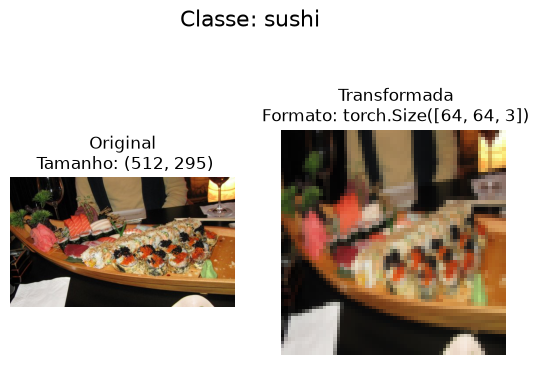

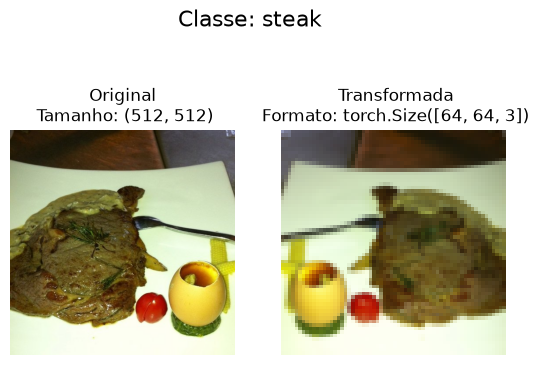

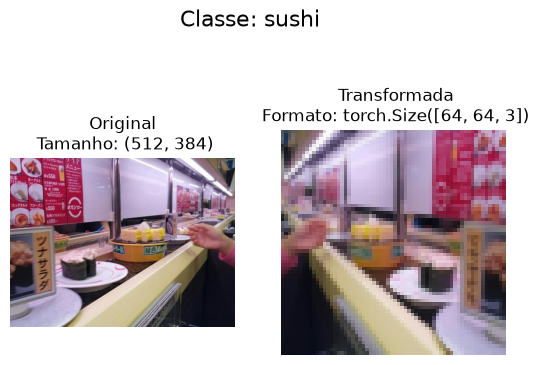

In [13]:
def plot_transformed_images(images_paths: list, transform, n = 3, seed = None):
    '''
    Seleciona imagens aleatorias de um caminho e carrega/transforma elas 
    e, em seguida plota a original vs a versao transformada
    '''
    if(seed):
        random.seed(seed)
    random_image_paths = random.sample(images_paths, k = n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows = 1, ncols = 2 )
            ax[0].imshow(f)
            ax[0].set_title(f'Original\n Tamanho: {f.size}')
            ax[0].axis(False)

            # Transformar e plotar a imagem de destino
            transformed_image = transform(f).permute(1,2,0) # nota: nos precisaremos mudar a forma para ter compatibilidade com o matplotlib (C,H,W) -> (H,W,C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f' Transformada\n Formato: {transformed_image.shape}')
            ax[1].axis(False)

            fig.suptitle(f'Classe: {image_path.parent.stem}', fontsize = 16)

plot_transformed_images(images_paths = image_path_list,
                        transform = data_transform,
                        n = 3,
                        seed = None)

## 4. Opçao 1: Carregar dados de imagem usando `ImageFolder`

Podemos carregar os dados de classificaçao de imagem usando `torchvision.datasets.ImageFolder`

In [14]:
# Usar ImageFolder para criar datasets
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform, # Uma transformaçao para os dados
                                  target_transform = None ) # Uma transformacao para o rotulo/alvo

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [16]:
# Obter o nome das classes como uma lista
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [17]:
# Obter nomes das classes como um dicionario
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [18]:
# Checar o tamanho do nosso dataset
len(train_data), len(test_data)

(225, 75)

In [19]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [20]:
# Indexar o conjunto de dados de treinamento para obter uma unica imagem e um rotulo
train_data[0]

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [21]:
img, label = train_data[0][0], train_data[0][1]
print(f'Tensor da imagem:\n {img}')
print(f'Formato da imagem: {img.shape}')
print(f'Tipo de dado da imagem: {img.dtype}')
print(f'Rotulo da imagem: {label}')
print(f'Tipo de dado do rotulo: {type(label)}')

Tensor da imagem:
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ...,

Formato original: torch.Size([3, 64, 64]) -> [canais de cores, altura, largura]
Formato permutado: torch.Size([64, 64, 3]) -> [altura,largura,canais de cores]


Text(0.5, 1.0, 'pizza')

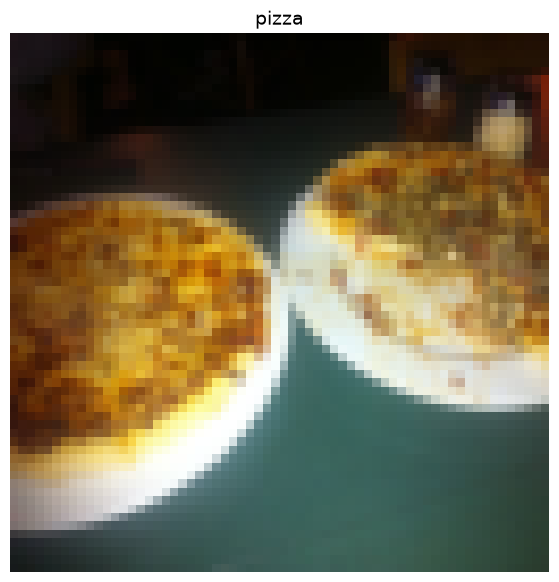

In [22]:
# Reorganizar a ordem das dimensoes
img_permute = img.permute(1,2,0)

# Printar os formatos diferentes
print(f'Formato original: {img.shape} -> [canais de cores, altura, largura]\nFormato permutado: {img_permute.shape} -> [altura,largura,canais de cores]')

# Plotar a imagem
plt.figure(figsize = (10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label], fontsize = 14)

### 4.1  Transformar as imagens acrregadas em carregadores de dados (DataLoader)

Um `DataLoader` nos ajudara a transformar nossos conjuntos de dados em suas tabelas e podemos configurar o `batch_size` portanto nosso modelo pode ver `batch_size` imagens por tempo.

In [23]:
import os
os.cpu_count()

6

In [24]:
# Transformar nosso conjuntos de dados de treinamento e teste em DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 3,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                              num_workers = 3,
                              shuffle = False)


train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x761042c72cf0>,
 <torch.utils.data.dataloader.DataLoader at 0x761042b724b0>)

In [25]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [26]:
img, label = next(iter(train_dataloader))

# O tamanho do lote agora sera um, podemos alterar o tamanho do lote se quisermos
print(f'Formato da imagem: {img.shape} -> [batch_size, canais de cores, altura, largura]')
print(f' Formato do rotulo: {label.shape}')

Formato da imagem: torch.Size([1, 3, 64, 64]) -> [batch_size, canais de cores, altura, largura]
 Formato do rotulo: torch.Size([1])


## 5. Opçao 2: Carregando dados de imagem com um conjunto de dados personalizado

1. Poder carregar imagens do arquivo dois
2. Poder obter nome de classes do conjunto de dados
3. Para obter classes como dicionario do conjunto de dados 

Pros: 
* Pode criar um conjunto de dados a partir de praticamente qualquer coisa
* Nao ficamos limitados as funçoes `dataset` pre-construidas do Pytorch

Contras:
* Mesmo que voce possa criar um `dataset` a partir de quase tudo, isso nao significa que ele funcionara automaticamente...
* O uso de um `dataset` personalizado exige que escrevamos mais codigo, que pode estar sujeito a erros ou problemas de desempenho

Todos os datasets personalizados em Pytorch, geralmente sao uma subclasse de `torch.utils.data.Dataset`

In [27]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [28]:
# Instancia de torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Criando uma funçao auxiliar para obter o nome de classes

Queremos uma funçao que nos permita:
1. Obter o nome das classes usando `os.scandir()` para percorrer um diretorio de destino (o ideal e que o diretorio esteja no formato padrao de classificaçao de imagens).
2. Gerar um erro se os nomes das classes nao forem encontrados (se isso acontecer pode haver algo errado com a estrutura do diretorio).
3. Transformar os nomes das classes em um dict e em uma lista e retorna-los.



In [29]:
# Configurar o caminho para o diretorio de destino
target_directory = train_dir
print(f'Diretorio de destino: {target_directory}')

# Obter o nome das classes do diretorio de destino
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Diretorio de destino: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [30]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:
    '''Encontrar os nomes das pastas das classes em um diretorio de destino'''
    # 1. Obter os nomes das classes escaneando o diretorio de destino
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Lançar um erro se os nomes das classes nao puderem ser encontrados
    if not classes:
        raise FileNotFoundError(f'Nao foi possivel achar nenhuma classe em {directory}... verifique a estrutura dos arquivos')

    # 3. Criar um dicioinario para obter rotulos indexados (computadores preferem numeros em vez de strings como rotulos)
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [31]:
find_classes(target_directory)


(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Criar um `Dataset` customizado para replicar a funçao `Image Folder`

Para criar nosso proprio dataset personalizado nos precisamos de:

1.  Subclasse `torch.utils.data.Dataset`
2. Iniciar nossa subclasse com o diretorio de destino(o diretorio que gostariamos de obter os dados) como uma transformaçao se quisermos transformar nossos dados.
3. Criar varios atributos:
 * paths - caminhos das nossas imagens
 * transform - a transformaçao que desejamos usar
 * classes - lista das classes de destino
 * class_to_idx - um dicionario das classes de destino mapeadas por rotulos inteiro
 4. Criar uma funçao `load_images()`, essa funçao abrira uma imagem
 5. Sobrescrever o metodo `__len__()` para retornar o comprimento do nosso dataset
 6. Sobrescrever o metodo  `__getitem()__` para retornar uma determinada amostra quando e passado um indice

In [32]:
# 0.  Escrever uma classe de conjunto de dados personalizados 
from torch.utils.data import Dataset

# 1. Subclasse torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    # 2. Inicializr nosos conjunto de dados personalizado
    def __init__(self,
                 targ_dir: str,
                 transform = None):
        # 3. Criar atributos de classe
        # Obter todos os caminhos de imagem
        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
        # Configurar transform
        self.transform = transform
        # Criar classes e dicionarios de classes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Criar a funçao que carregue imagens 
    def load_image(self, index: int) -> Image.Image:
        'Abre uma imagem a partir de um caminho e a retorna'
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Sobrescrever __len__()
    def __len__(self) -> int:
        'Retorna o numero total de amostras'
        return len(self.paths)

    # 6. Sobrescrever o metodo __getitem__() para retornar  uma amostra especifica
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        ' Retorna uma amostra dos dados, dados e rotulo (X,y)'
        img = self.load_image(index)
        class_name = self.paths[index].parent.name #espera o caminho no formato: pasta de dados/nome_classe/imagem.jpg
        class_idx = self.class_to_idx[class_name]

        # Transformar os dados( se necessario)
        if self.transform:
            return self.transform(img), class_idx # retorna dados, rotulo0 (X,y)
        else:
            return img,class_idx # retorna imagem e o rotulo que nao foram transformados


In [33]:
from torchvision import transforms
# Criar uma transformaçao
train_transforms = transforms.Compose([
                                    transforms.Resize(size = (64,64)),
                                    transforms.RandomHorizontalFlip(p = 0.5),
                                    transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                    transforms.Resize(size = (64,64)),
                                    transforms.ToTensor()
])
                                    


In [34]:
# Testar nossa funçao ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)

test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                     transform = test_transforms)

In [35]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x761042bf8860>,
 <__main__.ImageFolderCustom at 0x761042bfa7b0>)

In [36]:
len(train_data), len(train_data_custom)

(225, 225)

In [37]:
len(test_data), len(test_data_custom)

(75, 75)

In [38]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [39]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [40]:
# Checando a igualdade entre o dataset da ImageFolder original e da ImageFolderCustomData
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


### 5.3 Criar uma funçao para imprimir imagens aleatorias

1. Obter um `Dataset` e um numero de outros parametros como nome de classes e quantas imagens devem ser visualizadas.
2. Para evitar que a exibiçao fique fora de controle, vamos limitar o numero de imagens a serem vistas a dez.
3. Definir a random seed para reprodutibilidade.
4. Obter a lista de indices de amostras aleatorias do dataset alvo.
5. Configurar um plot em matplotlib.
6. Percorrer as imagens de amostra aleatorias e plota-las com a biblioteca matplotlib
7. Certificar que as dimensoes de nossas imagens estejam alinhadas com matplotlib(HWC)

In [41]:
# 1. Criar uma funçao para receber um conjunto de dados
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed : int = None):
    # 2. Ajustar o display se n for muito grande
    if n > 10:
        n = 10
        display_shape = False
        print(f'Para fins de exibiçao, n nao deve ser maior que 10, configurando para 10 e removendo o formato do display')

    # 3. Configurar a seed
    if seed:
        random.seed(seed)

    # 4. Obter indices de amostras aleatorias
    random_samples_idx = random.sample(range(len(dataset)), k = n)

    # 5. Configurar o plot
    plt.figure(figsize = (16,8))

    # 6. Percorrer os indices aleatorios e plota-los com a biblioteca matplotlib
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Ajustar as dimensoes do tensor para plotar
        targ_image_adjust = targ_image.permute(1,2,0) # [color channels, altura, largura] -> [height,width, color_channels]

        # Plotar amostras ajustadas
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis(False)
        if classes:
            title = f'Classe: {classes[targ_label]}'
            if display_shape:
                title = title + f'\nformato: {targ_image_adjust.shape}'
        plt.title(title)



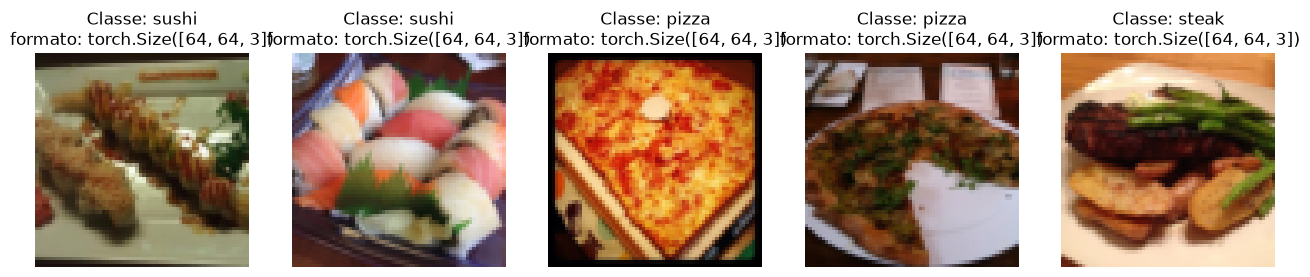

In [42]:
# Exibir imagens aleatorias da pasta de imagens que deu origem ao Dataset
display_random_images(dataset = train_data_custom,
                      n = 5,
                      classes = class_names,
                      seed = None)

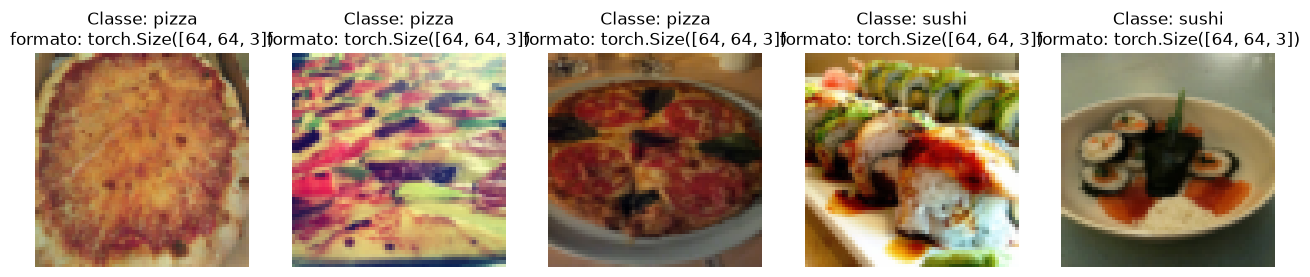

In [43]:
# Exiba imagens aleatorias do dataset ImageFolderCustom
display_random_images(train_data_custom,
                      n = 5,
                      classes = class_names,
                      seed = None)

### 5.4 Tranformasr as imagens carregadas customizadas em `DataLoader's`

In [44]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                        batch_size = BATCH_SIZE,
                        num_workers = NUM_WORKERS,
                        shuffle = True)
test_dataloader_custom = DataLoader(dataset = test_data_custom,
                       batch_size = BATCH_SIZE,
                       num_workers = NUM_WORKERS,
                       shuffle = False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x761042b0c350>,
 <torch.utils.data.dataloader.DataLoader at 0x76113948d760>)

In [45]:
# Obter uma imagem e um rotulo do dataloader personalizado
img_custom, label_custom = next(iter(train_dataloader_custom))

# Printar os formatos
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Outras formas de transformaçao (aumento de dados)

O aumento de dados e o processo de adicionar artificialmente diversidade aos seus dados de treinamento.

No caso de dados de imagem, isso pode significar a aplicaçao de varias transformaçoes de imagem nas imagens de treinamento.

Espera-se que essa pratica resulte em um modelo que seja amis generalizavel para dados nao vistos.

Vamos dar uma olhada em um tipo especifico de aumento de dados usado para treinar os modelos de visao computacional do pytorch para os niveis mais avançados...

Blog: https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/

In [46]:
# Vamos dar uma olhada no TrivialAugment - https://docs.pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_illustrations.html
from torchvision import transforms

train_transform = transforms.Compose([
                                      transforms.Resize(size = (224,224)),
                                      transforms.TrivialAugmentWide(num_magnitude_bins = 5),
                                      transforms.ToTensor()
])

test_transform = transforms.Compose([  
                                     transforms.Resize(size = (224,224)),
                                     transforms.ToTensor()
                                     
])

In [47]:
# Obter todos os caminhos de imagem
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/416067.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/3475871.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/398345.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg')]

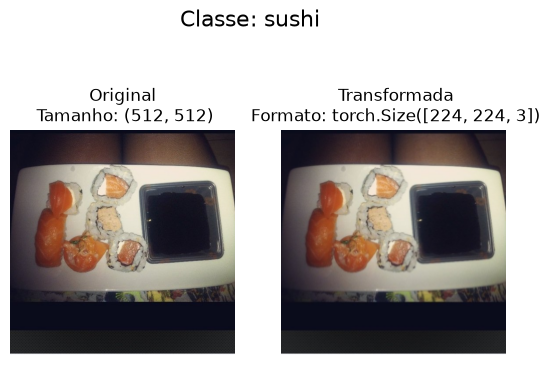

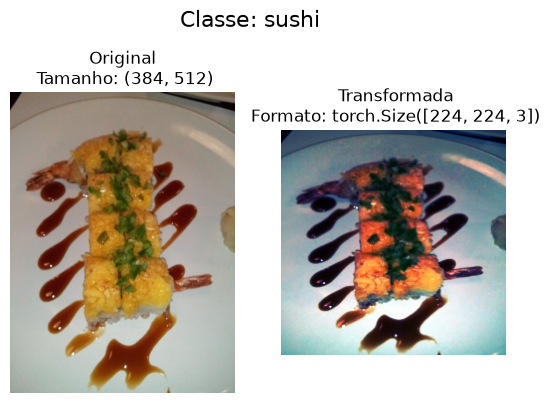

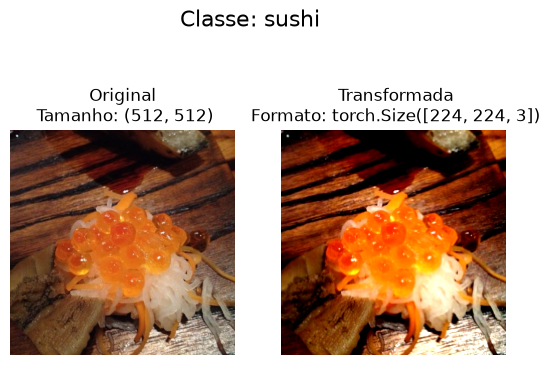

In [48]:
# Plotar imagens aleatorias transformadas
plot_transformed_images(images_paths = image_path_list,
                         transform = train_transform,
                         n = 3,
                         seed = None)

## 7. TinyVGG sem data augmentations

Vamos replicar a arquitetura do TinyVGG do site CNN explainer: https://poloclub.github.io/cnn-explainer/

### 7.1 Criar algumas transformaçoes e carregar os dados para o modelo 0

In [49]:
# Criar uma transformaçao simples
simple_transform = transforms.Compose([
                                       transforms.Resize(size = (64,64)),
                                       transforms.ToTensor()
])

In [50]:
# 1. Carregar e transformar os dados
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root = train_dir,
                                         transform = simple_transform)

test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = simple_transform)

# 2. Transformar o dataset em DataLoader
import os 
from torch.utils.data import DataLoader

# Configurar  batch_size e num_workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# CRiar os Dataloader's
train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True)

test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    num_workers = NUM_WORKERS,
                                    shuffle = False)

### 7.2 Criar a classe do modelo TinyVGG 

In [51]:
class TinyVGG(nn.Module):
    '''Arquitetura do modelo que copia o TinyVGG do CNN Explainer: https://poloclub.github.io/cnn-explainer/
    '''
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
                 super().__init__()
                 self.conv_block_1 = nn.Sequential(
                    nn.Conv2d(in_channels = input_shape,
                              out_channels = hidden_units,
                              kernel_size = 3,
                              stride = 1,
                              padding = 0),
                    nn.ReLU(),
                    nn.Conv2d(in_channels = hidden_units,
                              out_channels = hidden_units,
                              kernel_size = 3,
                              stride = 1,
                              padding = 0),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size = 2,
                                 stride = 2)) # O valor padrao para o stride e o mesmo que o valor do kernel_size
                 
                 self.conv_block_2 = nn.Sequential(
                    nn.Conv2d(in_channels = hidden_units,
                              out_channels = hidden_units,
                              kernel_size = 3,
                              stride = 1,
                              padding = 0),
                    nn.ReLU(),
                    nn.Conv2d(in_channels = hidden_units,
                              out_channels = hidden_units,
                              kernel_size = 3,
                              stride = 1,
                              padding = 0),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size = 2,
                                 stride = 2) # O valor padrao para o stride e o mesmo que o valor do kernel_size
                 )
                 self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(in_features = hidden_units * 13 * 13,
                              out_features = output_shape)
                )
    def forward(self,x):
            x = self.conv_block_1(x)
            #print(x.shape)
            x = self.conv_block_2(x)
            #print(x.shape)
            x = self.classifier(x)
            #print(x.shape)
            return x
            # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # se beneficia da fusao de operadores: https://horace.io/brrr_intro.html

In [52]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3, # numero de canais de cores da nossa imagem
                  hidden_units = 10,
                  output_shape = len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Tentar a inferencia com uma unica imagem (para testar o modelo)

In [53]:
# Obter um lote de imagem unico
image_batch, label_batch = next((iter(train_dataloader_simple)))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [54]:
# Tentar a inferencia
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9130e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6416e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### 7.4 Usar `torch.info` para ter uma ideia dos formatos que estao passando pelo nosso modelo}

In [55]:
import torchinfo
from torchinfo import summary
summary(model_0, input_size = [1,3,64,64] )

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 7.5 Criar funçoes de loops de treino e teste

* `train_step()` - recebe um modelo e um DataLoader e treina o modelo no DataLoader.
* `test_step()` - recebe um modelo e um DataLoader e avalia o modelo no DataLoader.


In [56]:
# Criar train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
    # Colocar o modelo no modo treino
    model.train()

    # Configurar os valores de perda e acuracia do treino
    train_loss, train_acc = 0,0

    # Percorrer os batchs do DataLoader]
    for batch, (X,y) in enumerate(dataloader):
        # enviar os dados para o dispositivo de destino
        X, y = X.to(device), y.to(device)

        # 1. Forward pass(inferencia)
        y_pred = model(X) # saida bruta do modelo

        # 2. Calcular a perda
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        # 3. Zerar os gradientes do otimizador
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Passo do otimizador
        optimizer.step()

        # Calcular a metrica acuracia
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/ len(y_pred)

    # ajustar as metricas para obter a perda e a precisao media por lote
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc



In [57]:
# Criar a funçao test_step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device
              ):
    #
    # Colocar o modelo em avaliaçao
    model.eval()

    # Configuar os valores de perda e acuracia do teste
    test_loss, test_acc = 0,0
    # Ativar o modo de inferencia
    with torch.inference_mode():
        # Percorrer o dataloader
        for batch, (X,y) in enumerate(dataloader):
            # Enviar os dados para o dispositivo de destino
            X,y = X.to(device), y.to(device)
            # 1. Inferencia
            y_pred = model(X)

            # 2. Calcular a perda
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
            # Calcular a acuracia
            y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
            acc = (y_pred_class == y).sum().item() / len(y_pred)
            test_acc += acc

        # Ajustar as metricas para obter a perda e a precisao media por lote
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        return test_loss, test_acc
        

### 7.6 Criar uma funçao `train()` para combinar `train_step()` e `test_step()`

In [58]:
from tqdm.auto import tqdm

# 1. Criar uma funçao de treinamento que receba varios parametros do modelo + otimizador + dataloaders + loss_fn 
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device):
    # 2. Criar um dicionaro de resultados vazio
    results = {'train_loss': [],
               'train_acc': [],
               'test_loss': [],
               'test_acc': []}
    # 3. Percorrer o loop de treinamento e teste por um numero de epocas
    for epoch in tqdm(range(epochs)):
        train_loss , train_acc = train_step(model = model,
                                            dataloader = train_dataloader,
                                            loss_fn = loss_fn,
                                            optimizer = optimizer,
                                            device = device)
        
        test_loss, test_acc = test_step(model = model,
                                        dataloader = test_dataloader,
                                        loss_fn = loss_fn,
                                        device = device)
        # 4. Printar o que esta acontecendo
        print(f' Epoch: {epoch} | Perda do treino: {train_loss:.4f} | Acuracia do treino: {train_acc:.4f} | Perda no teste: {test_loss:.4f} | Acuracia no teste: {test_acc:.4f}')

        # 5. Atualizar o dicionario de resultados
        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)
# 6. Retornar os resultados preenchidos no final de cada epoca
    return results


/home/lucas/.cache/pypoetry/virtualenvs/pytorch-0JguN_8h-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 7.7 Treinar e avaliar o model 0

In [59]:
# configurar as random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Configurar o numero de epocas 
NUM_EPOCHS = 5

# Recriar uma instancia de TinyVGG
model_0 = TinyVGG(input_shape = 3, # numero de canais de cores das noaasa imagens de destino
                  hidden_units = 10,
                  output_shape = len(train_data.classes)).to(device)
# Configurar a funçao de perda e o otimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                            lr = 0.001)

# Iniciar o cronometro
from timeit import default_timer as timer
start_time = timer()

# Treinar o model_0
model_0_results = train(model = model_0,
                        train_dataloader= train_dataloader_simple,
                        test_dataloader= test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = NUM_EPOCHS,
                        device= device)

# Encerrar o cronometro e printar quanto tempo levou para treinar nosso modelo
end_time = timer()
print(f'Tempo total de treinamento: {end_time - start_time:.3f} segundos')


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:02<00:08,  2.14s/it]

 Epoch: 0 | Perda do treino: 1.1063 | Acuracia do treino: 0.3047 | Perda no teste: 1.0983 | Acuracia no teste: 0.3011


 40%|████      | 2/5 [00:04<00:06,  2.15s/it]

 Epoch: 1 | Perda do treino: 1.0998 | Acuracia do treino: 0.3281 | Perda no teste: 1.0697 | Acuracia no teste: 0.5417


...

 Epoch: 2 | Perda do treino: 1.0869 | Acuracia do treino: 0.4883 | Perda no teste: 1.0808 | Acuracia no teste: 0.4924


 80%|████████  | 4/5 [00:07<00:01,  1.74s/it]

 Epoch: 3 | Perda do treino: 1.0844 | Acuracia do treino: 0.4023 | Perda no teste: 1.0607 | Acuracia no teste: 0.5833


100%|██████████| 5/5 [00:09<00:00,  1.83s/it]

 Epoch: 4 | Perda do treino: 1.0663 | Acuracia do treino: 0.4141 | Perda no teste: 1.0657 | Acuracia no teste: 0.5644
Tempo total de treinamento: 9.158 segundos


In [60]:
model_0_results

{'train_loss': [1.1063191145658493,
  1.099800854921341,
  1.0868771821260452,
  1.0844270884990692,
  1.0662999898195267],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.40234375, 0.4140625],
 'test_loss': [1.0983208417892456,
  1.0696993668874104,
  1.080764373143514,
  1.0607410669326782,
  1.0656602780024211],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5833333333333334,
  0.5643939393939394]}

### 7.8 Traçar as curvas de perda do modelo 0

Uma **curva de perda** e uma forma de acompanhar o progresso do seu modelo ao longo do tempo.

Um bom guia para diferentes curvas de perda pode ser visto aqui: https://developers.google.com/machine-learning/testing-debugging/metrics/interpretic


In [61]:
# Obter as chaves dos resultados do modelo zero
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [62]:
def plot_loss_curves(results: Dict[str,List[float]]):
    '''Plota as curvas de treinamento do nosso dicionario de resultados'''
    # Obter os valores de perda do dicionario de resultados(treinamento e teste)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Obter os valores de precisao do dicionario de resultados(treinamento e teste)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Descobrir quantas epocas tinham
    epochs = range(len(results['train_loss']))

    # Configurar um plot
    plt.figure(figsize = (15,7))

    # Plotar a perda
    plt.subplot(1,2,1)
    plt.plot(epochs,loss, label = 'train_loss')
    plt.plot(epochs, test_loss, label = 'test_loss')
    plt.title('Perda')
    plt.xlabel('Epocas')
    plt.legend()

    # Plotar a acuracia
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label = 'train_accuracy')
    plt.plot(epochs, test_accuracy, label = 'test_accuracy')
    plt.title('Precisao')
    plt.xlabel('Epocas')
    plt.legend()




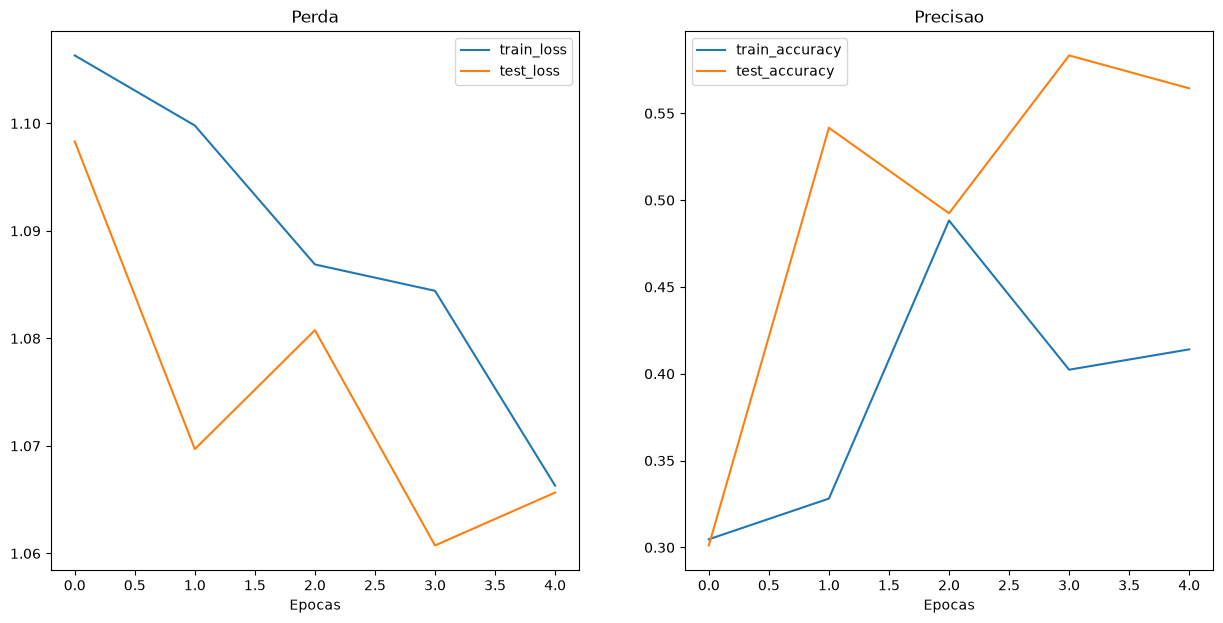

In [63]:
plot_loss_curves(model_0_results)

## 8. Como deve ser uma curva de perda ideal?

https://developers.google.com/machine-learning/testing-debugging/metrics/interpretic

A curva de perda e uma das maneiras mais uteis de solucionar os problemas em um modelo

## 9. Modelo 1:  TinyVGG com Data Augmentation

Agora vamos tentar outro experimento de modelagem, dessa vez usando o mesmo modelo anterior, mas com Data Augmentation.

### 9.1 Criar a transformaçao com Data Augmentation

In [64]:
# Criar transformaçao de treinamento com TrivialAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
                                              transforms.Resize(size = (64,64)),
                                              transforms.TrivialAugmentWide(num_magnitude_bins = 31),
                                              transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
                                            transforms.Resize(size = (64,64)),
                                            transforms.ToTensor()
])

### 9.2  Criar `datasets` de treino e teste e `DataLoader's` com Data Augmentation

In [65]:
# Transformar as pastas de imagem em dataset
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root = train_dir,
                                            transform = train_transform_trivial)

test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = test_transform_simple)

In [66]:
# Transformar nossos datasets em DataLoaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset = train_data_augmented,
                                      batch_size = BATCH_SIZE,
                                      shuffle = True,
                                      num_workers = NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False,
                                    num_workers = NUM_WORKERS)

### 9.3 Vamos construir e treinar o modelo 1 

Desta vez  vamos usar a mesma arquitetura, so que desta vez aumentamos os dados de treinamento.

In [67]:
# Criar o modelo 1 e encia-lo para o dispositivo de destino
torch.manual_seed(42)
model_1 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

Maravilha! Agora temos um modelo e um DataLoader, vamos criar uma funçao de perda e um otimizador e chamar a funçao `train()` que nos criamos anteriormente para treinar e avaliar o modelo.

In [68]:
# Configurar a random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Configurar o numero de epocas
EPOCHS = 5

# Configurar a funçao de perda
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),
                             lr = 0.001)

# Comecar o cronometro
from timeit import default_timer as timer
start_time = timer()

# Treinar o modelo 1
model_1_results = train(model = model_1,
                        train_dataloader = train_dataloader_augmented,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = EPOCHS,
                        device = device)

# Fim do treino
end_time = timer()
print(f' O tempo total de treino foi: {end_time - start_time:.3f} segundos')



 20%|██        | 1/5 [00:01<00:05,  1.42s/it]

 Epoch: 0 | Perda do treino: 1.1045 | Acuracia do treino: 0.2500 | Perda no teste: 1.1015 | Acuracia no teste: 0.2604


 40%|████      | 2/5 [00:03<00:04,  1.53s/it]

 Epoch: 1 | Perda do treino: 1.0762 | Acuracia do treino: 0.4258 | Perda no teste: 1.1311 | Acuracia no teste: 0.2604


 60%|██████    | 3/5 [00:04<00:03,  1.53s/it]

 Epoch: 2 | Perda do treino: 1.0734 | Acuracia do treino: 0.4258 | Perda no teste: 1.1684 | Acuracia no teste: 0.2604


 80%|████████  | 4/5 [00:06<00:01,  1.66s/it]

 Epoch: 3 | Perda do treino: 1.1141 | Acuracia do treino: 0.3047 | Perda no teste: 1.1550 | Acuracia no teste: 0.2604


100%|██████████| 5/5 [00:08<00:00,  1.63s/it]

 Epoch: 4 | Perda do treino: 1.0674 | Acuracia do treino: 0.5000 | Perda no teste: 1.1455 | Acuracia no teste: 0.3125
 O tempo total de treino foi: 8.156 segundos


In [69]:
model_1_results

{'train_loss': [1.10447558760643,
  1.07622691988945,
  1.0734150931239128,
  1.1140789687633514,
  1.0674165487289429],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.5],
 'test_loss': [1.101508378982544,
  1.131097674369812,
  1.1684485077857971,
  1.1549867987632751,
  1.145453155040741],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.3125]}

### 9.4 Plotar as curvas de perda do modelo 1

A curva de perda ajuda a avaliar o desempenho do modelo ao longo do tempo.

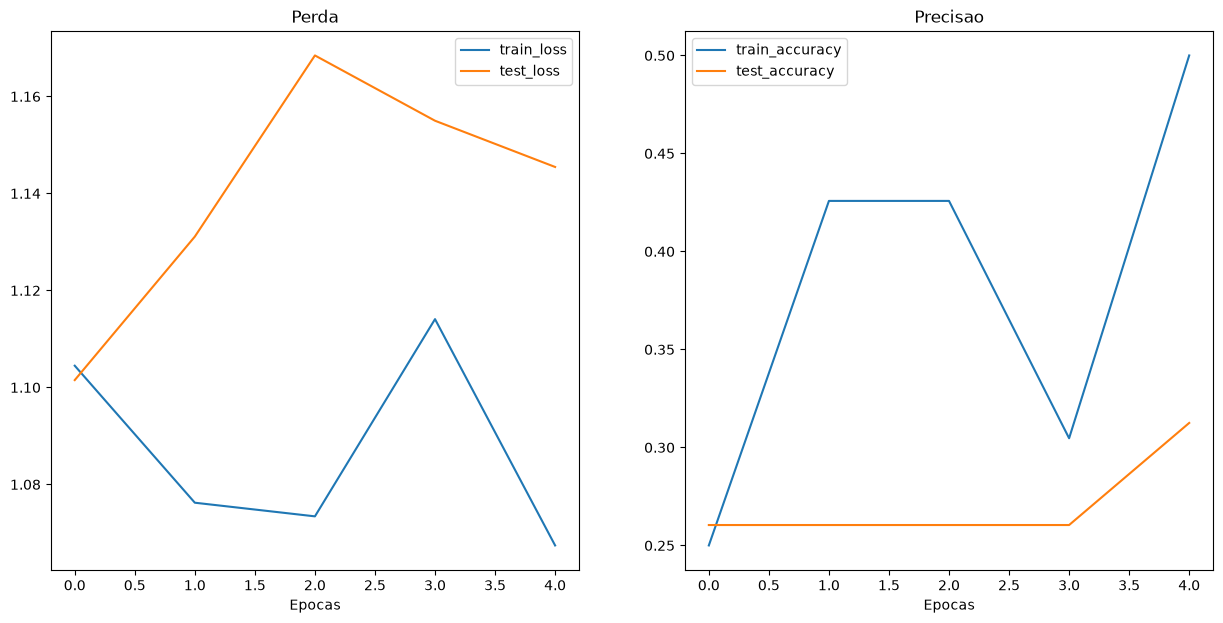

In [70]:
plot_loss_curves(model_1_results)

## 10. Comparar os resultados dos modelos

Depois de avaliar nossos experimentos de modelagem por conta propria, e importante compara-los entre si.

Ha algumas manieras diferentes de fazer isso:
1. Codificaçao rigida(hard coding que e o que estamos fazendo)
2. PyTorch + Tensorboard - https://pytorch.org/docs/stable/tensorboard.html
3. Pesos & vieses( weights and bias) - https://wandb.ai/site/experiment-tracking
4. MLFlow - https://mlflow.org/

In [71]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098321,0.301136
1,1.099801,0.328125,1.069699,0.541667
2,1.086877,0.488281,1.080764,0.492424
3,1.084427,0.402344,1.060741,0.583333
4,1.066300,0.414062,1.065660,0.564394


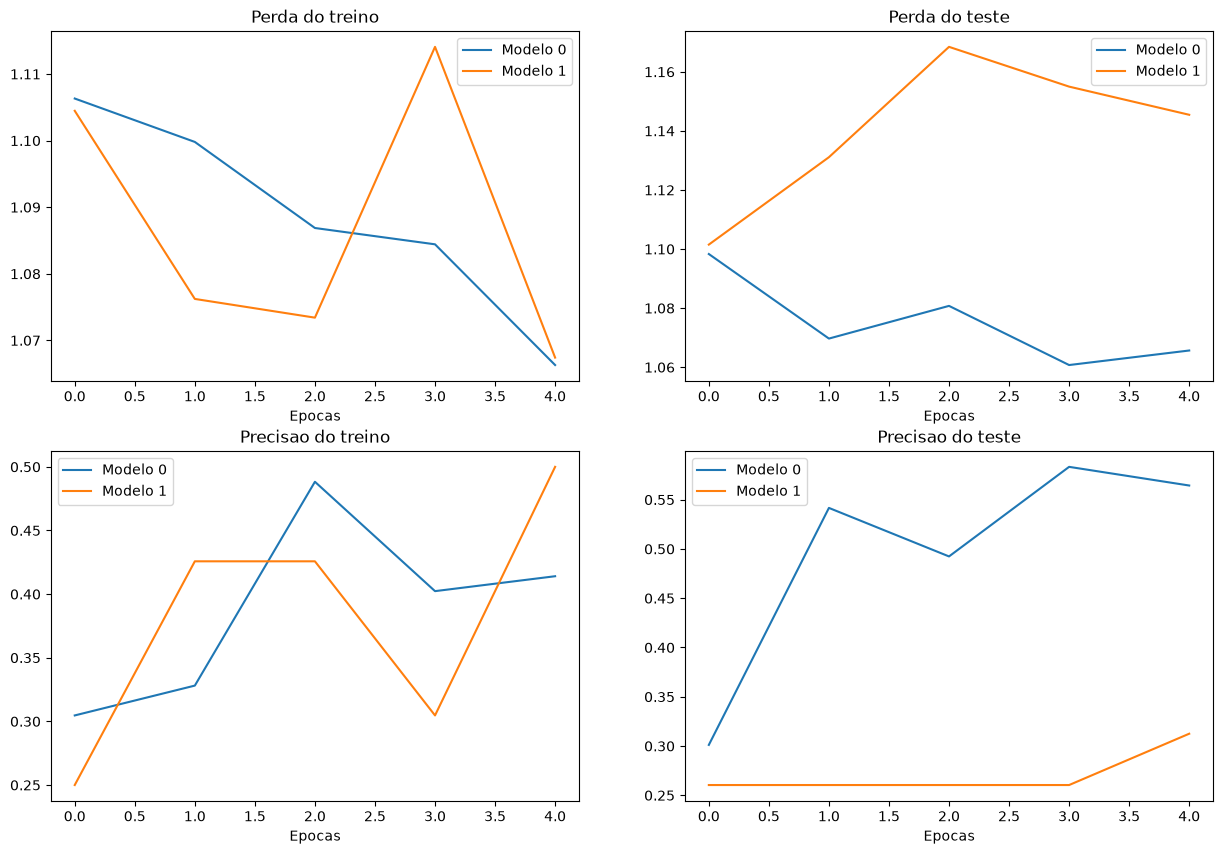

In [72]:
# Configurar um plot
plt.figure(figsize = (15,10))

# Obter o numero de epocas
epochs = range(len(model_0_df))

# Plotar a perda do treino
plt.subplot(2,2,1)
plt.plot(epochs, model_0_df['train_loss'], label = 'Modelo 0')
plt.plot(epochs, model_1_df['train_loss'], label = 'Modelo 1')
plt.title('Perda do treino')
plt.xlabel('Epocas')
plt.legend()

# Plotar a perda do teste
plt.subplot(2,2,2)
plt.plot(epochs, model_0_df['test_loss'], label = 'Modelo 0')
plt.plot(epochs, model_1_df['test_loss'], label = 'Modelo 1')
plt.title('Perda do teste')
plt.xlabel('Epocas')
plt.legend()

# Plotar a acuracia do treino
plt.subplot(2,2,3)
plt.plot(epochs, model_0_df['train_acc'], label = 'Modelo 0')
plt.plot(epochs, model_1_df['train_acc'], label = 'Modelo 1')
plt.title('Precisao do treino')
plt.xlabel('Epocas')
plt.legend()

# Plotar a acuracia do treino
plt.subplot(2,2,4)
plt.plot(epochs, model_0_df['test_acc'], label = 'Modelo 0')
plt.plot(epochs, model_1_df['test_acc'], label = 'Modelo 1')
plt.title('Precisao do teste')
plt.xlabel('Epocas')
plt.legend()



## 11. Fazendo uma previsão em uma imagem personalizada

Embora tenhamos treinado um modelo em dados personalizados... Como você faz uma previsão em uma amostra/imagem que não etsa no nonjunto de dados de treinamento ou de teste.

In [73]:
# Baixar uma imagem personalizada
import requests

# Configurar o caminho da imagem personalizada
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Baixar a imagem caso ela não exista
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # Ao fazer o download do github, precisamos usar o link "raw" do arquivo]
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f" Baixando {custom_image_path}...")
        f.write(request.content)

else:
    print(f"{custom_image_path} já existe, pulando download...")

data/04-pizza-dad.jpeg já existe, pulando download...


### 11.1 Carregando uma imagem personalizada com PyTorch

Temos que nos certificar que a nossa imagem personalizada esteja no mesmo formato que os dados em que o nosso modelo foi treinado.

* Na forma de tensor com tipo (torch.float32)
* Com o formato (64,64,3)
* No dispositivo correto

Nos podemos lwe uma imagem em PyTorch usando `read_image()`

In [74]:
import torchvision

# Ler uma imagem personalizada
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print(f"Tensor da imagem personalizada:\n {custom_image_uint8}")
print(f"Formato da imagem personalizada: {custom_image_uint8.shape}")
print(f"Tipo de dado da iamgem personalizada: {custom_image_uint8.dtype}")

Tensor da imagem personalizada:
 tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
Formato da imagem personalizada: torch.Size([3, 4032, 

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

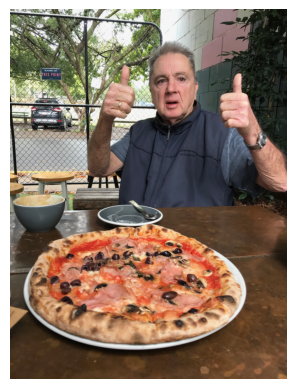

In [75]:
plt.imshow(custom_image_uint8.permute(1,2,0))
plt.axis(False)

### 11.2 Fazendo uma previsão em uma imagem personalizada com um modelo PyTorch treinado

In [76]:
# Carregando a imagem personalizada e convertendo-a em torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

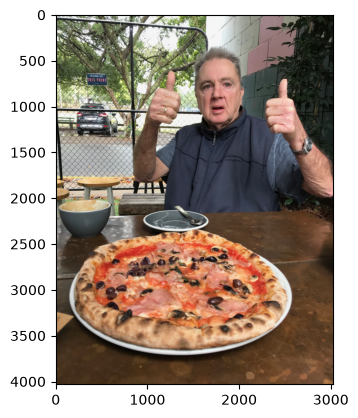

In [77]:
plt.imshow(custom_image.permute(1,2,0))

In [78]:
# Criar uma pipeline de transformação para redimensionar a imagem
from torchvision import transforms
custom_image_transform = transforms.Compose([
                                            transforms.Resize(size = (64,64))
])

# Transfomrar a imagem de destino
custom_image_transformed = custom_image_transform(custom_image)

# Imprimir as formas
print(f" Formato da imagem transformada: {custom_image_transformed.shape}\n Formato da imagem original: {custom_image.shape}")

 Formato da imagem transformada: torch.Size([3, 64, 64])
 Formato da imagem original: torch.Size([3, 4032, 3024])


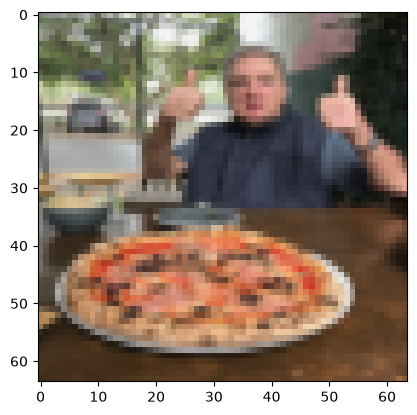

In [79]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [80]:
# Isso causara um erro: Sem batch size
model_1.eval()
with torch.inference_mode():
   custom_image_pred = model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x3)

In [81]:
custom_image_transformed.shape, custom_image_transformed.unsqueeze(0).shape

(torch.Size([3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [82]:
# Isso deve funcionar adicionando o batch_size
model_1.eval()
with torch.inference_mode():
   custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0903, -0.0057, -0.2338]])

Nota: Para fazer uma previsão em uma imagem personalizada nós tivemos que:
* Carregar uma imagem e transformá-la em um tensor
* Nos certificar de que a imagem era do mesmo tipo de dados que as imagens em que o modelo foi treinado (torch.float32)
* Garantir que a imagem tivesse o mesmo formato dos dados em que o modelo foi treinado (3x64x64) com batch_size... (1x3x64x64)
* Ter certeza que a imagem esta no mesmo dispositivo que o nosso modelo

In [89]:
# Converter logits -> probabilidades de previsao 
custom_image_pred_probs = torch.softmax(custom_image_pred, dim = 1)
custom_image_pred_probs

tensor([[0.3800, 0.3452, 0.2748]])

In [95]:
# Converter as probabilidades de previsao -> rotulos de previsao
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim = 1).cpu()
custom_image_pred_label


tensor([0])

In [94]:
class_names[custom_image_pred_label]

'pizza'

### 11.3 JUntando a previsao de imagens personalizadas: construindo uma funçao

Resultado ideal:

Uma funçao onde passamos um caminho de uma imagem para fazer que nosso modelo preveja a classe dessa imagem e plote a imagem + previsao.

In [97]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = device):
    '''Faz uma previsao em uma imagem-alvo com um modelo treinado e plota a imagem e a previsao'''
    # Carregar uma imagem
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # Dividir os pixeis da iamgem por 255 para obte-los entre zero e um
    target_image /= 255

    # Transformar nosso dado se necessario
    if transform:
        target_image = transform(target_image)

    # Ter certeza que o modelo esta no dispositivo de destino
    model.to(device)

    # Ativar o modo de inferencia para fazer uma previsao com nosso modelo
    model.eval()
    with torch.inference_mode():
        # Adicionar uma camada extra a imagem (dimensao do batch_size, nosso modelo vai prever em batches de 1 imagem)
        target_image = target_image.unsqueeze(dim = 0) 

        # Fazer a previsao na imagem com uma dimensao extra
        target_image_pred = model(target_image.to(device)) # Se certificar que a imagem de destino esta no dispositivo certo

        # Converter logit -> probabilidades de previsao
        target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)

        # Converter probabilidades de previsao -> rotulos de previsao
        target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)


        # Plotar a imagem junto com a previsao e a probabilidade de previsao
        plt.imshow(target_image.squeeze().permute(1,2,0)) # remover a dimensao de lote e reorganizar o formato para (h,w,c)
        if class_names:
            title = f'Previsao: {class_names[target_image_pred_label.cpu()]}  Probabilidade de previsao: {target_image_pred_probs.max().cpu():.3f}'
        else:
            title = f'Previsao: {target_image_pred_label} | Probabilidade de previsao: {target_image_pred_probs.max().cpu():.3f}'
        plt.title(title)
        plt.axis(False)



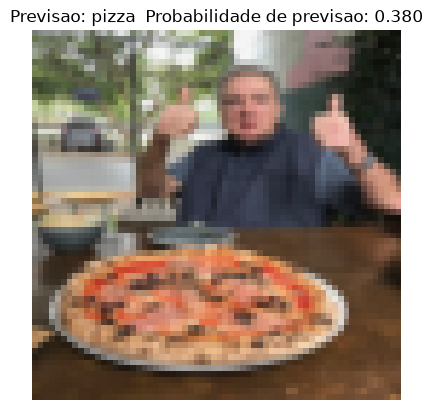

In [100]:
pred_and_plot_image(model = model_1,
                    image_path = custom_image_path,
                    class_names = class_names,
                    transform = custom_image_transform,
                    device = device)